In [1]:
import asyncio
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Optional
import os
from dotenv import load_dotenv
from collections import Counter
import pickle

# Hide the httpx warnings
import logging
logging.getLogger("httpx").setLevel(logging.WARNING)

# Import the recommender classes
from orderRecommender import AsyncOpenAIClient, CosineSimilarityCalculator, EmbeddingRecommender

# Import analysis
from orderAnalysis import run_analysis, plot_rank

# Load environment variables
load_dotenv()

# Configuration setup
config = {
    "OPENAI_API_KEY": os.getenv("OPENAI_API_KEY"),
    "OPENAI_API_VERSION": os.getenv("OPENAI_API_VERSION"),
    "OPENAI_API_BASE": os.getenv("OPENAI_API_BASE"),
    "OPENAI_ORGANIZATION_ID": os.getenv("OPENAI_ORGANIZATION_ID"),
    "GENERATOR_MODEL": os.getenv("GENERATOR_MODEL", "gpt-4"),  # Set default if not in env
    "RECOMMENDER_MODEL": os.getenv("RECOMMENDER_MODEL", "gpt-4"),
    "OPENAI_EMBEDDING_MODEL": os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-ada-002")
}

# Initialize components
openai_client = AsyncOpenAIClient(config)
similarity_calculator = CosineSimilarityCalculator()
recModel = EmbeddingRecommender(openai_client, similarity_calculator)

emb_df = pd.read_pickle('embeddings.pkl')
# Remove parentheses and their contents from the 'course' column values
emb_df['course'] = emb_df['course'].str.replace(r'\s*\(.*?\)', '', regex=True)
undergrad = [100, 200, 300, 400, 500]

recModel.load_courses(emb_df)

# ChatGPT generated queries

In [2]:
queries = [
    "What are some applied math courses that go beyond theory? I'm looking to connect math with real-world problems.",
    "As an English major obsessed with poetry, I'd love to explore classes focused on resistance and social change through verse.",
    "Courses that explore moral reasoning and how our ideas of ethics evolve over time — anything like that?",
    "I want to work in AI. What classes should I take if I'm aiming to become a machine learning engineer?",
    "I'm an art student curious about how technology can enhance or challenge artistic expression. Suggestions?",
    "I care a lot about climate change. Are there any classes that explore environmental issues and public policy?",
    "Are there any good interdisciplinary courses that explore different global cultures and ways of thinking?",
    "Looking to get better with data - stuff like Python, statistics, and maybe some data visualization. What should I take?",
    "I'm an English major and really into Dostoevsky and Tolstoy. Any courses on 19th century Russian literature?",
    "Curious about what neuroscience can teach us about human behavior and how we make decisions.",
    "I'm a fiction writer at heart. Looking for classes that will help me develop my voice and narrative skills.",
    "Hoping to start my own business one day — any classes focused on entrepreneurship or startups?",
    "Are there humanities courses for pre-meds that focus on ethics, empathy, or human experience?",
    "I want to dive deep into political theory — especially the big thinkers who've shaped modern ideologies.",
    "I'm a biology major but want to take something that connects biology with innovation or technology.",
    "Any courses that look at inequality, justice, and the roots of systemic oppression?",
    "Super interested in urban futures — especially smart cities and sustainable infrastructure.",
    "I make music in my free time. Would love to take a class on sound design or music production.",
    "What classes talk about how people and technology shape each other?",
    "I want to better understand war, diplomacy, and international relations. Recommendations?",
    "Looking for something that connects language and thought — maybe psycholinguistics?",
    "I'm into robotics. Which courses can help me work with hardware and embedded systems?",
    "What's a good class for exploring the philosophy behind science and how we justify knowledge?",
    "I love movies and want to study how they influence the way we see the world. Film recs?",
    "Interested in how gender and sexuality are expressed and challenged through history and culture.",
    "As a student-athlete, I'd like to find electives that explore leadership, sports psychology, or performance.",
    "I read a lot of comics and graphic novels. Are there academic classes that look at visual storytelling?",
    "What are some classes that examine the ethical dilemmas of artificial intelligence?",
    "I'm majoring in cognitive science and interested in computational models of the mind.",
    "Anything that traces the development of scientific ideas from a humanistic point of view?",
    "Looking for a class that explores myths and their relevance in today's literature and culture.",
    "Interested in global health challenges — particularly public health in underserved communities.",
    "I want to learn more about indigenous ways of knowing and how they contrast with Western worldviews.",
    "Are there any classes that focus on game design or the psychology behind interactive media?",
    "Curious about how religion intersects with modern society and politics.",
    "I'm a dancer looking for courses that tie in performance theory, body politics, or movement analysis.",
    "What classes study social behavior through the lens of data and computational modeling?",
    "I care about wildlife conservation. Any good options for studying biodiversity and ecological policy?",
    "Want to explore how different societies relate to nature and the environment.",
    "How do algorithms affect our daily lives and society at large? Any relevant courses?",
    "Any design-related courses that explore how systems shape human behavior?",
    "As an economics major, I want to explore the roots and solutions to inequality.",
    "Languages fascinate me, especially how they evolve. Any historical linguistics courses?",
    "Interested in how education is changing because of tech. What should I look into?",
    "Any courses that analyze the cultural or political power of fashion?",
    "Are there classes that look at trauma and memory in literature and art?",
    "What kind of classes cover artificial life or the bio-inspired side of computer science?",
    "I'm fascinated by space travel. Are there courses that study space through science and culture?",
    "I'm a sociology major and really curious about online subcultures and digital communities.",
    "Are there any quirky or experimental courses that challenge conventional ways of thinking?"
]

# Experiment

Running experiment for query 1/50: What are some applied math courses that go beyond theory? I'm looking to connect math with real-world problems.


100%|██████████| 10/10 [01:47<00:00, 10.77s/it]


Running experiment for query 2/50: As an English major obsessed with poetry, I'd love to explore classes focused on resistance and social change through verse.


100%|██████████| 10/10 [01:39<00:00,  9.93s/it]


Running experiment for query 3/50: Courses that explore moral reasoning and how our ideas of ethics evolve over time — anything like that?


...

100%|██████████| 10/10 [01:54<00:00, 11.49s/it]


Running experiment for query 49/50: I'm a sociology major and really curious about online subcultures and digital communities.


100%|██████████| 10/10 [01:47<00:00, 10.73s/it]


Running experiment for query 50/50: Are there any quirky or experimental courses that challenge conventional ways of thinking?


100%|██████████| 10/10 [01:44<00:00, 10.46s/it]


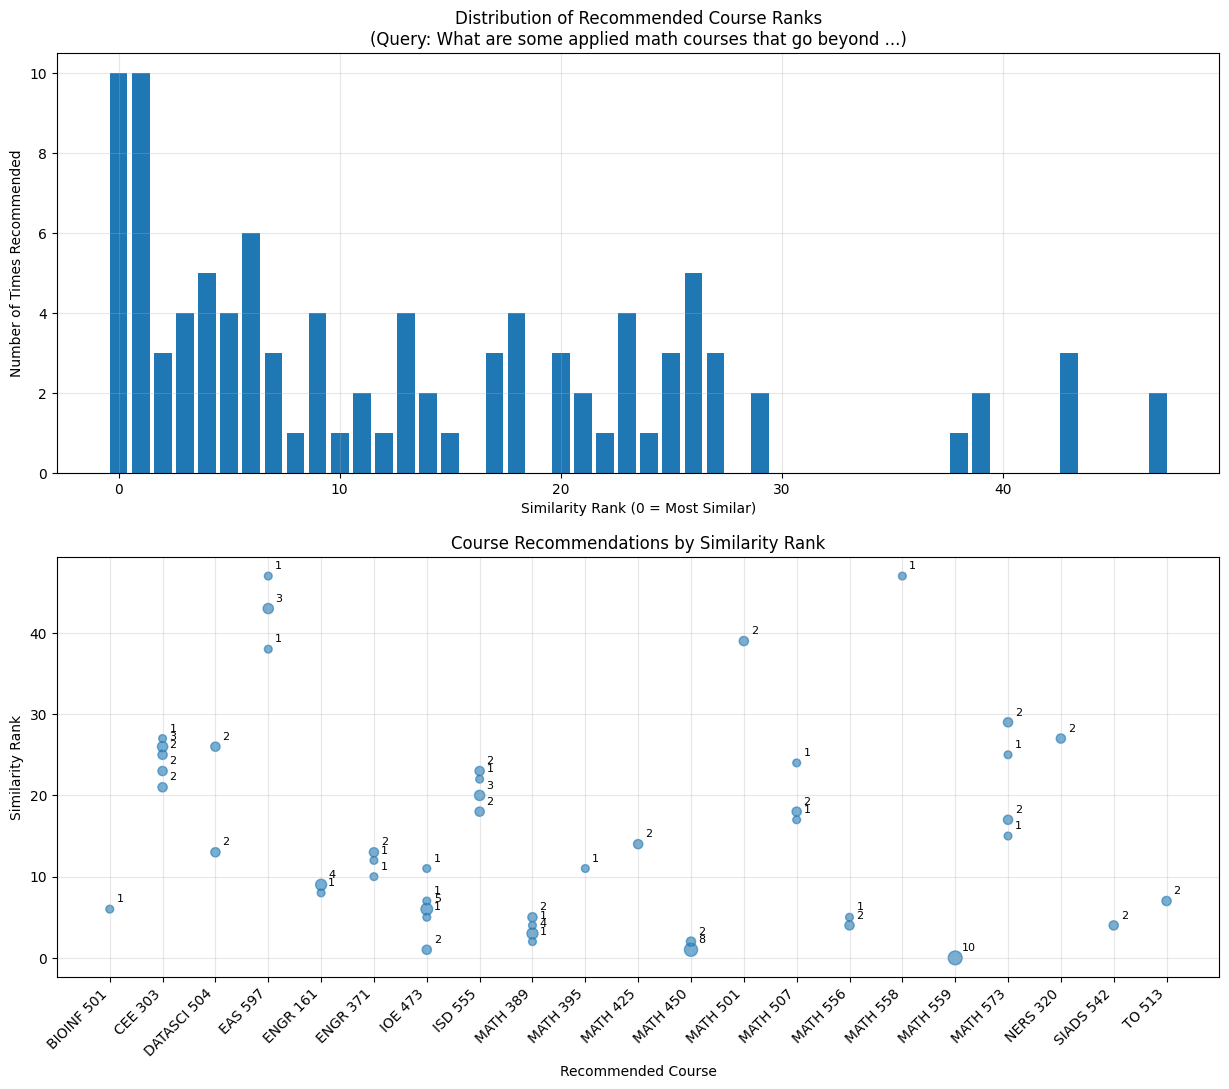

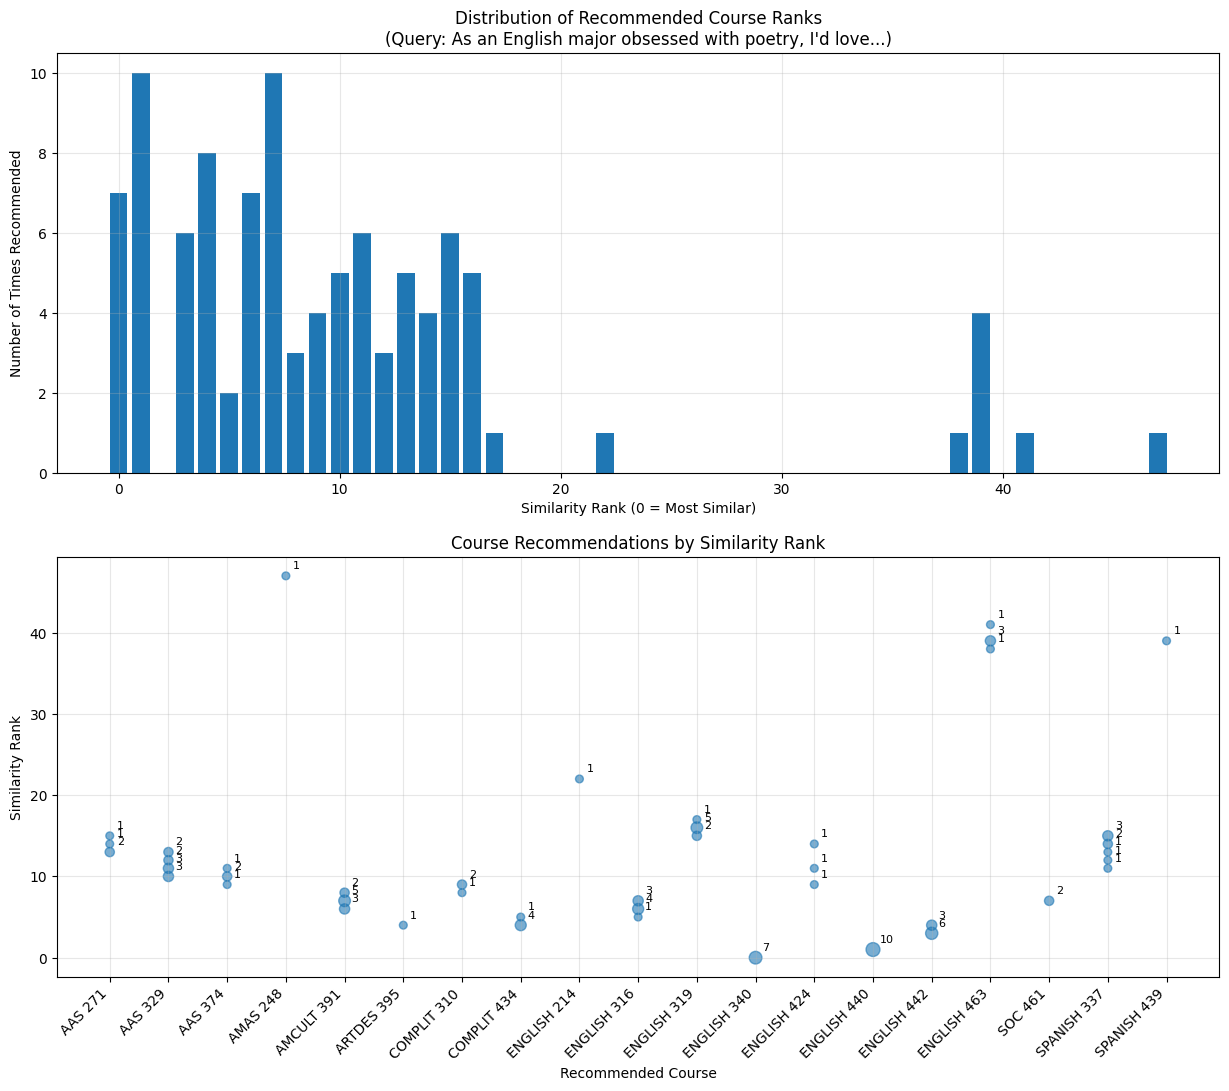

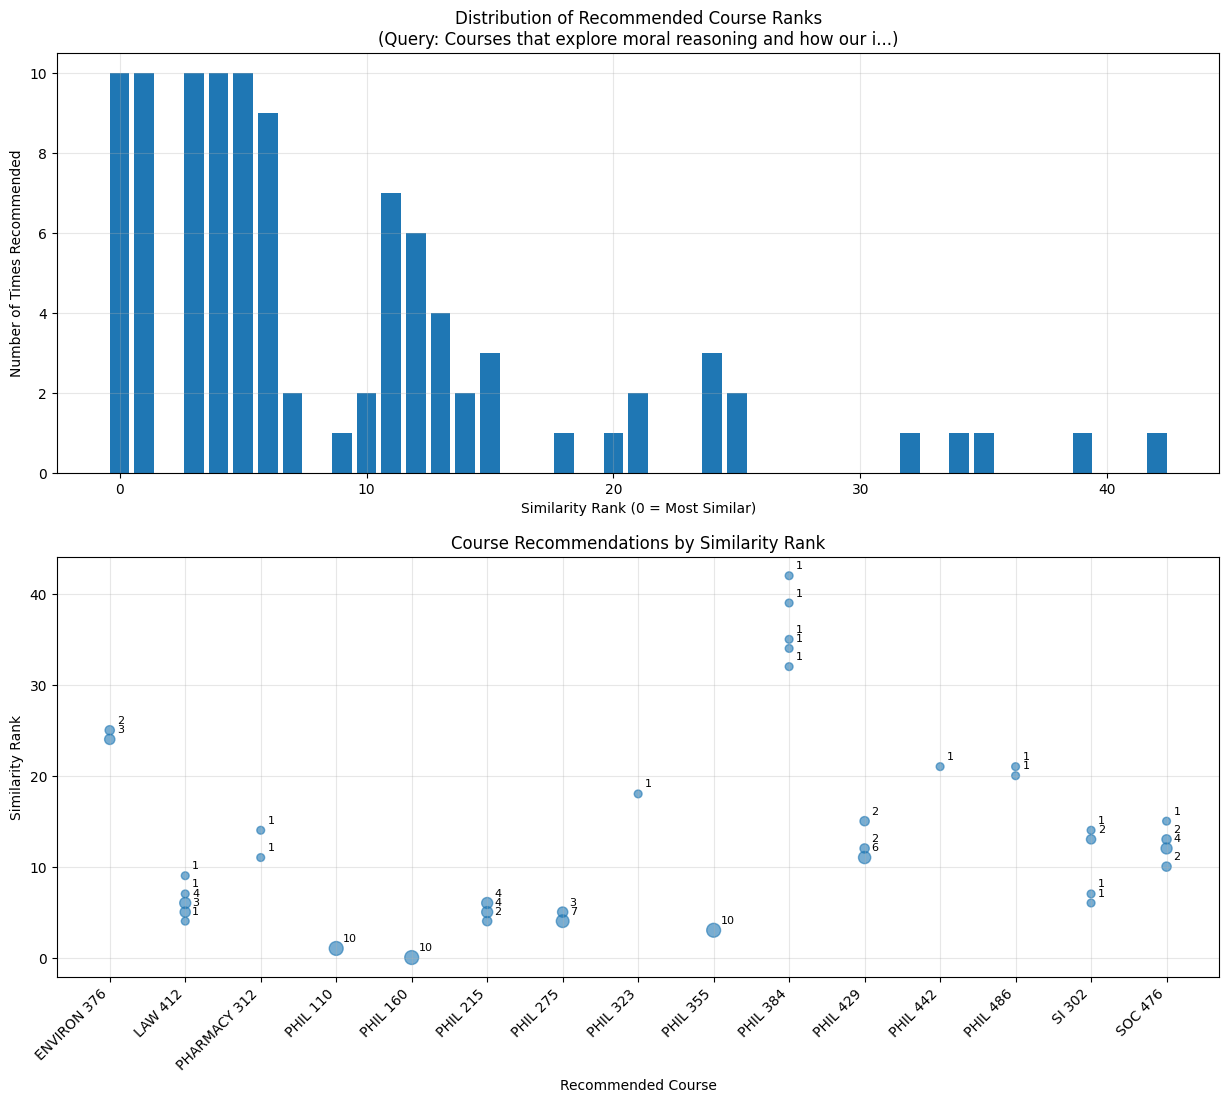

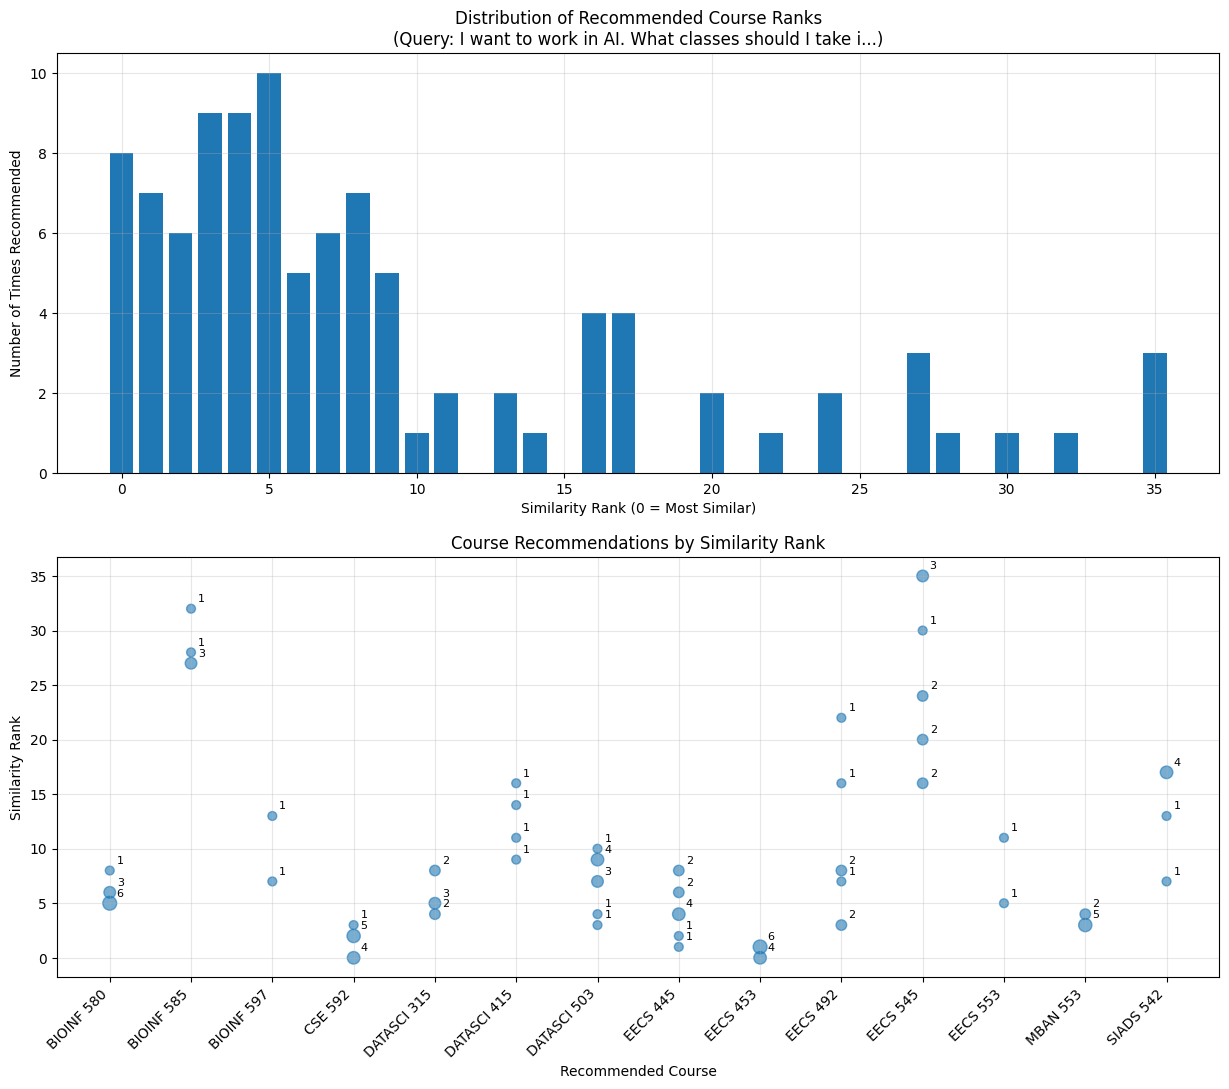

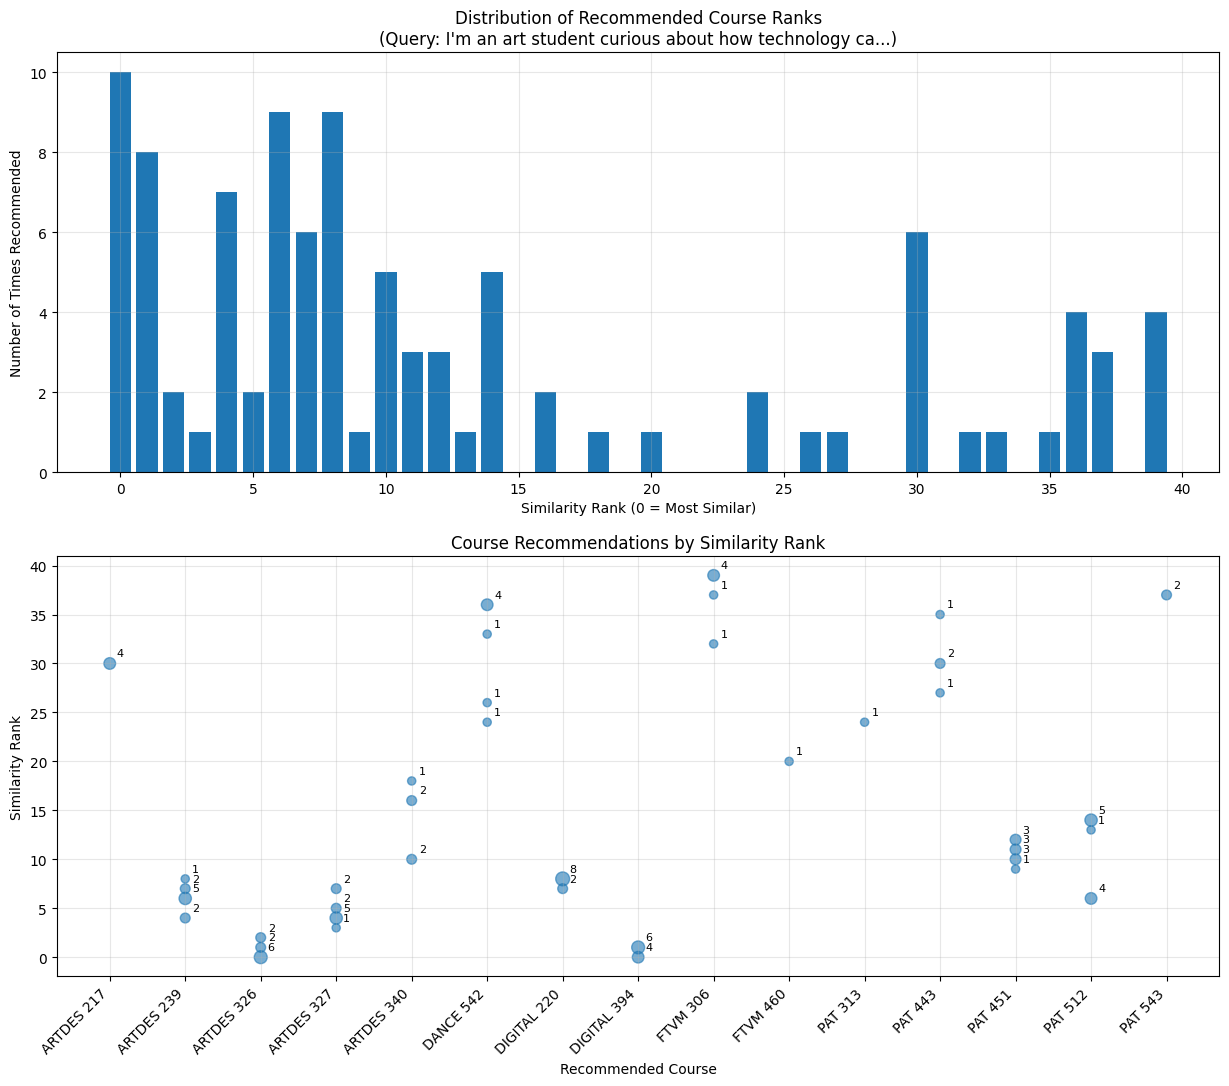

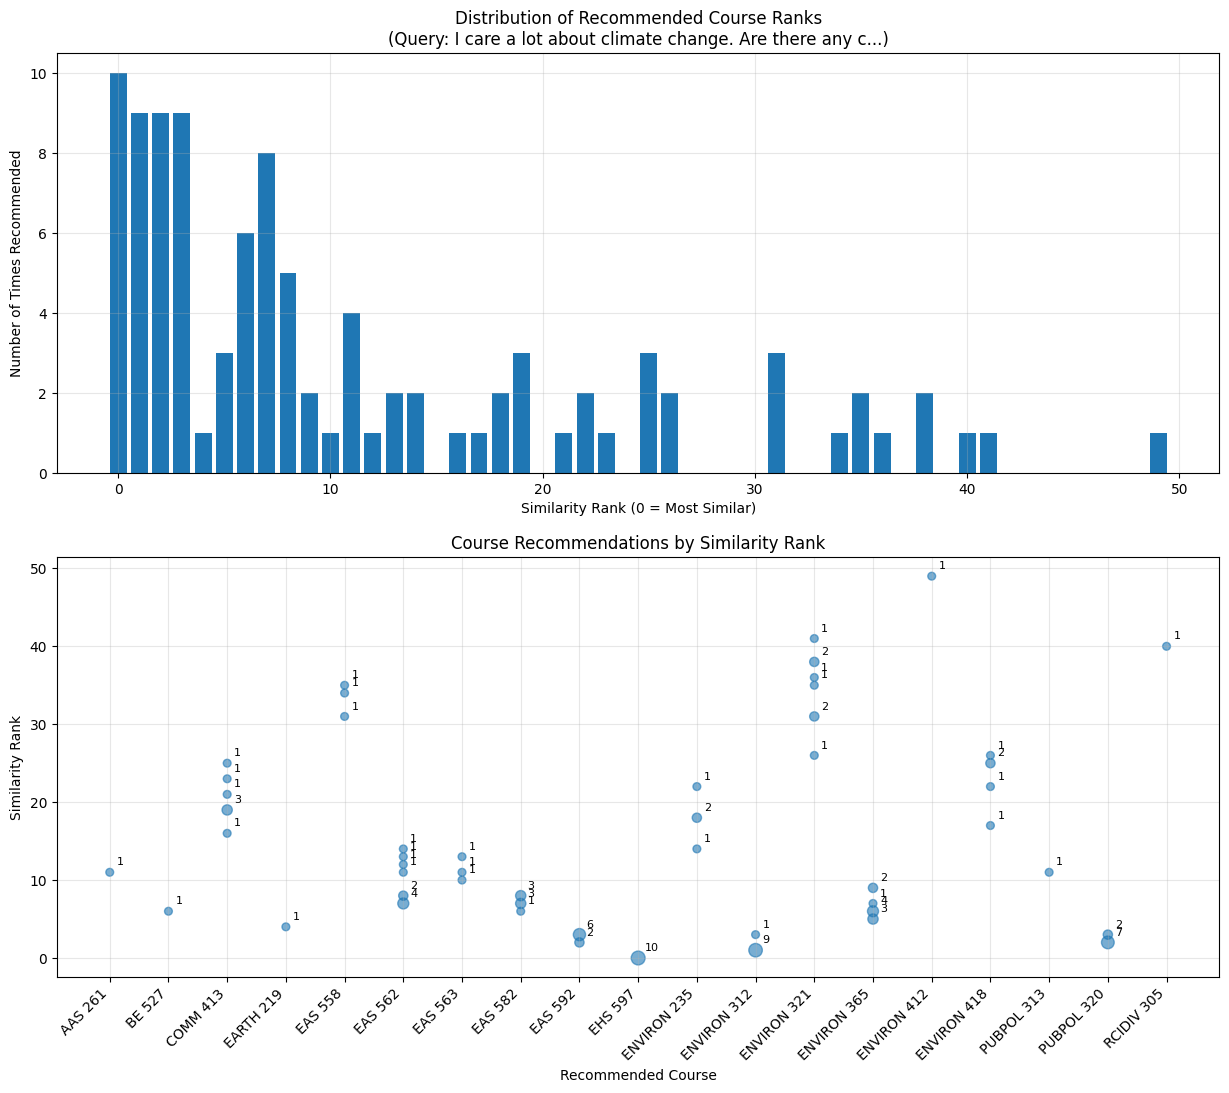

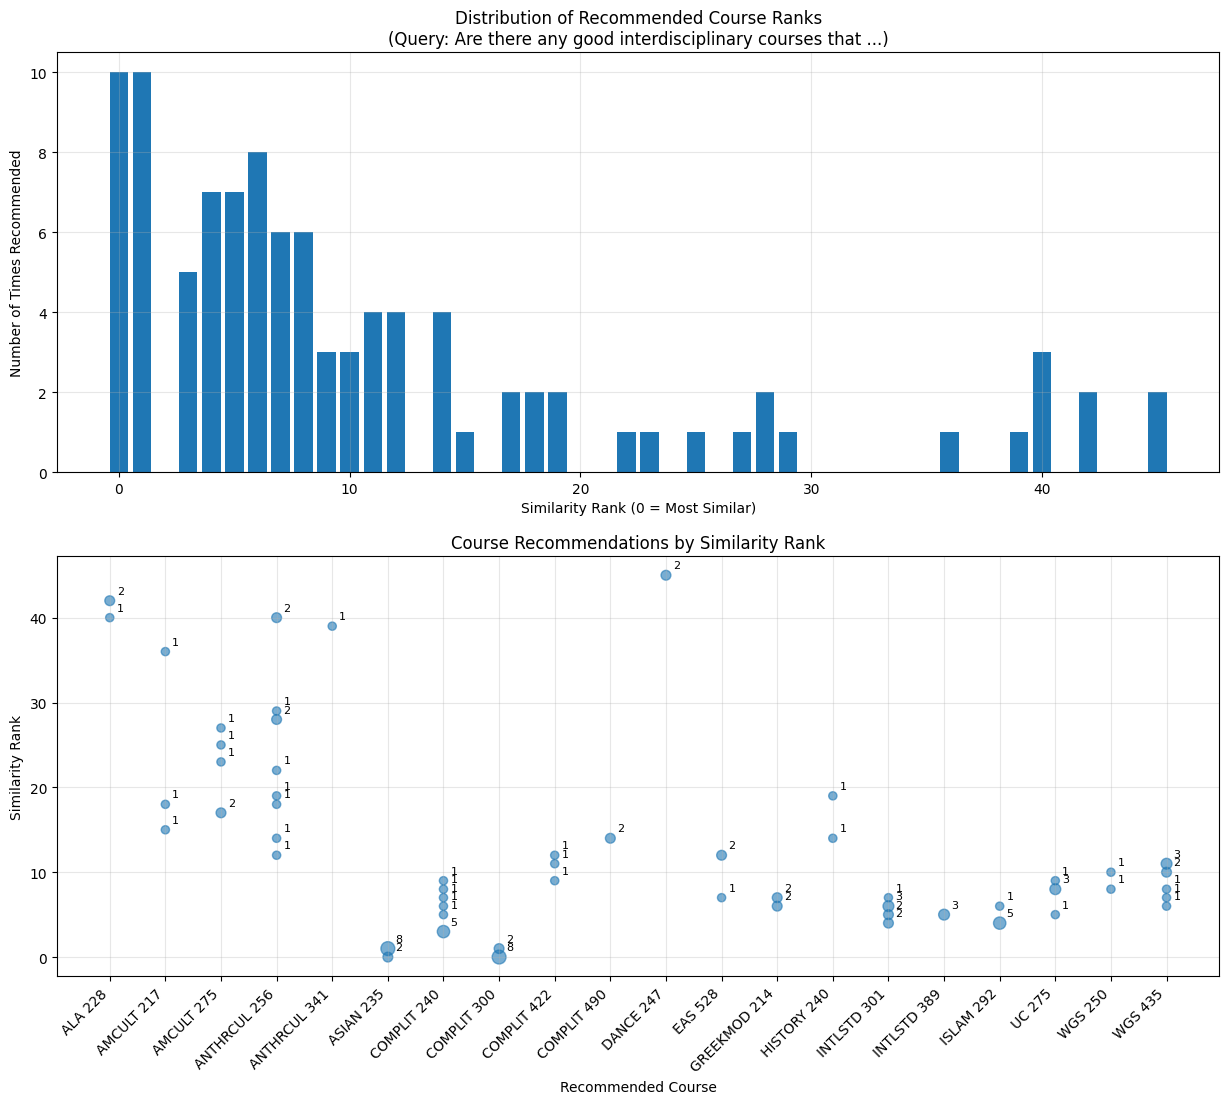

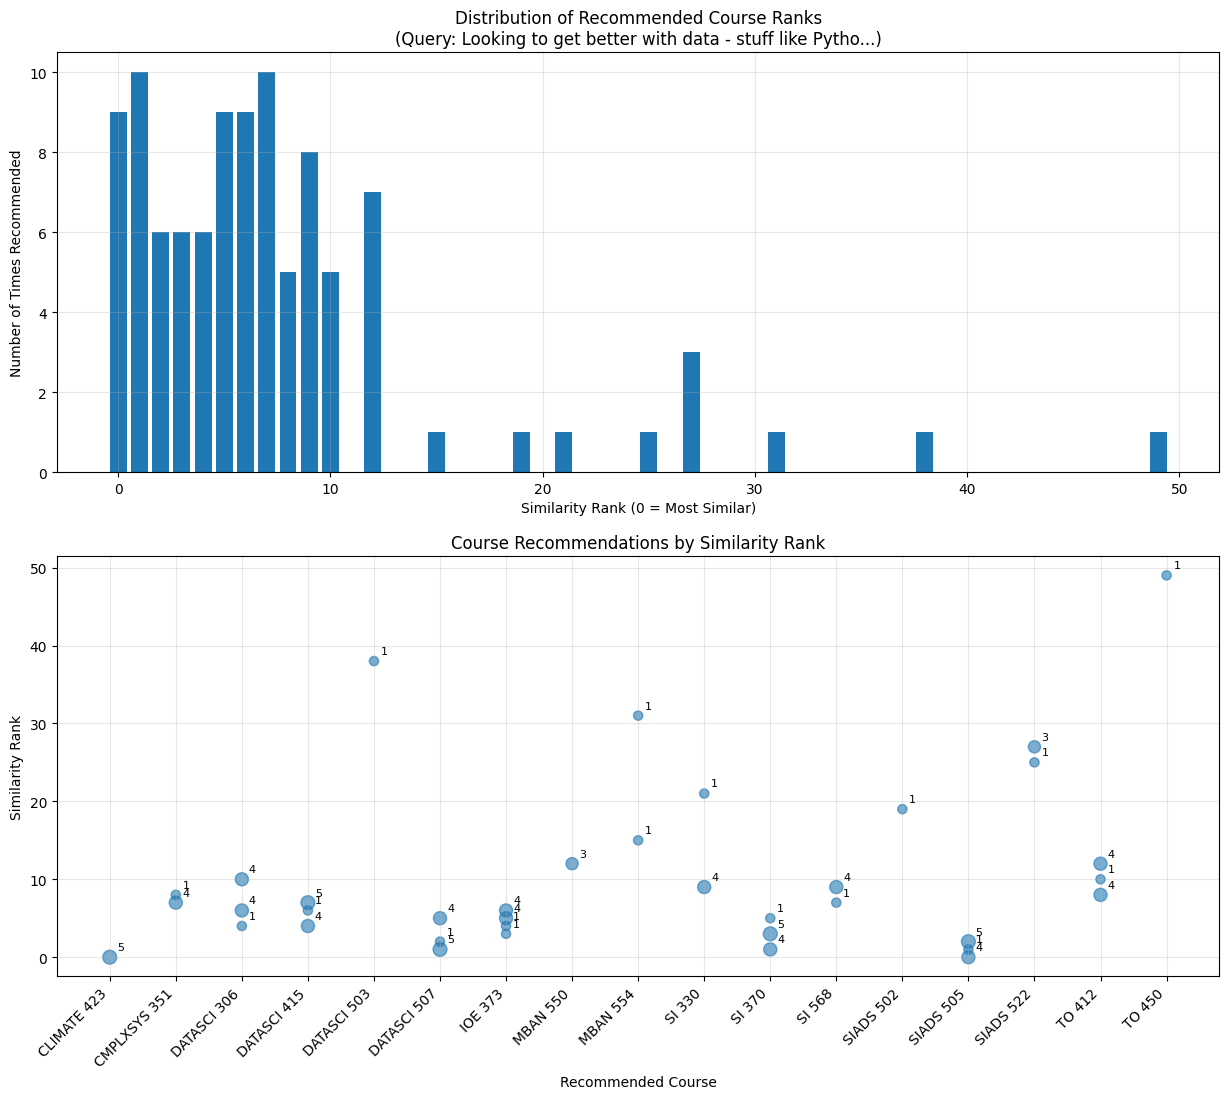

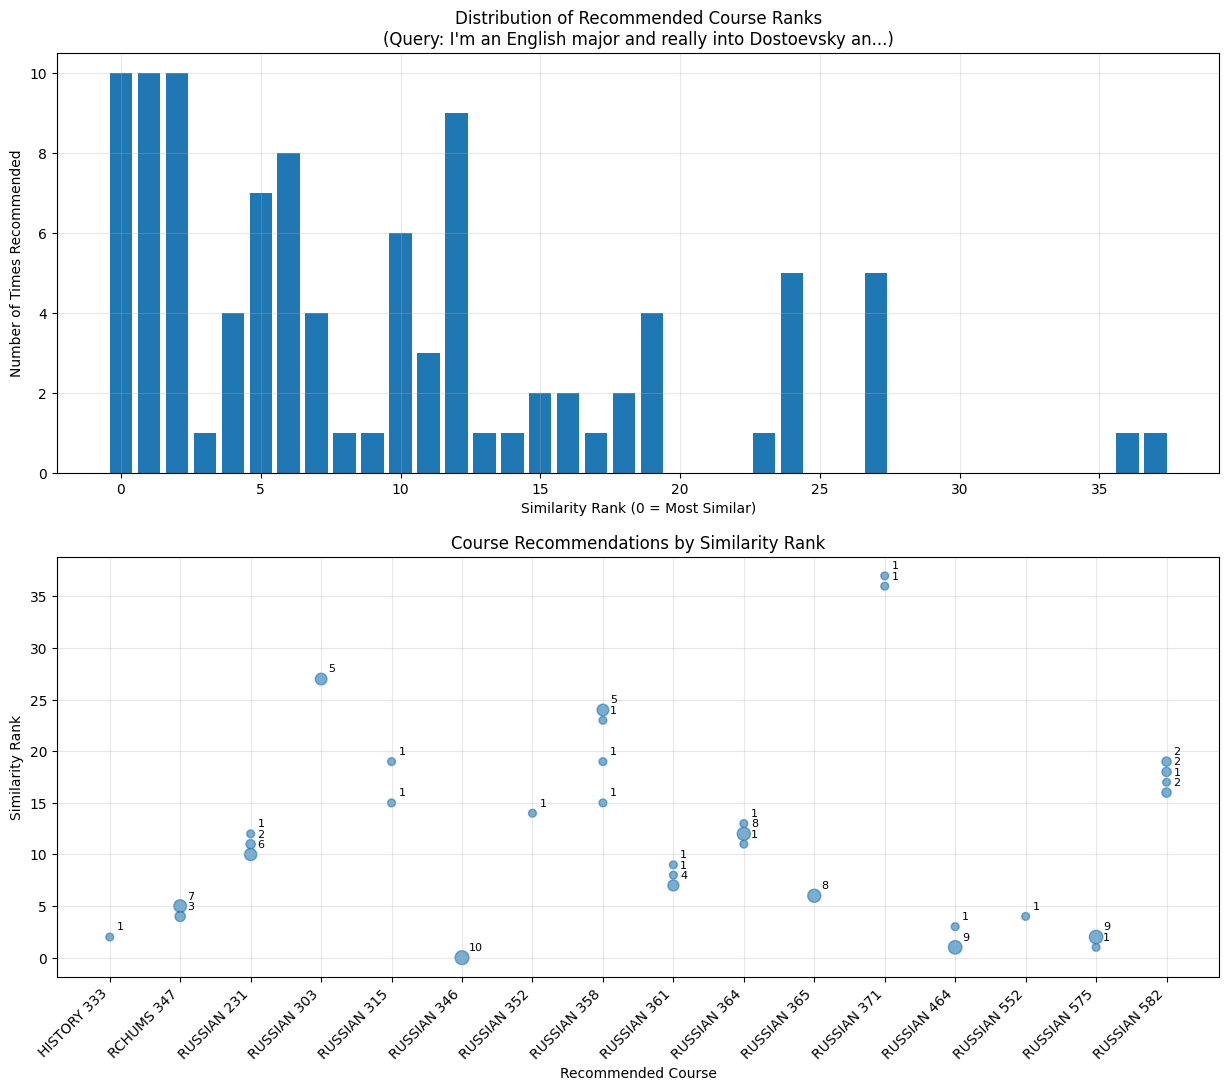

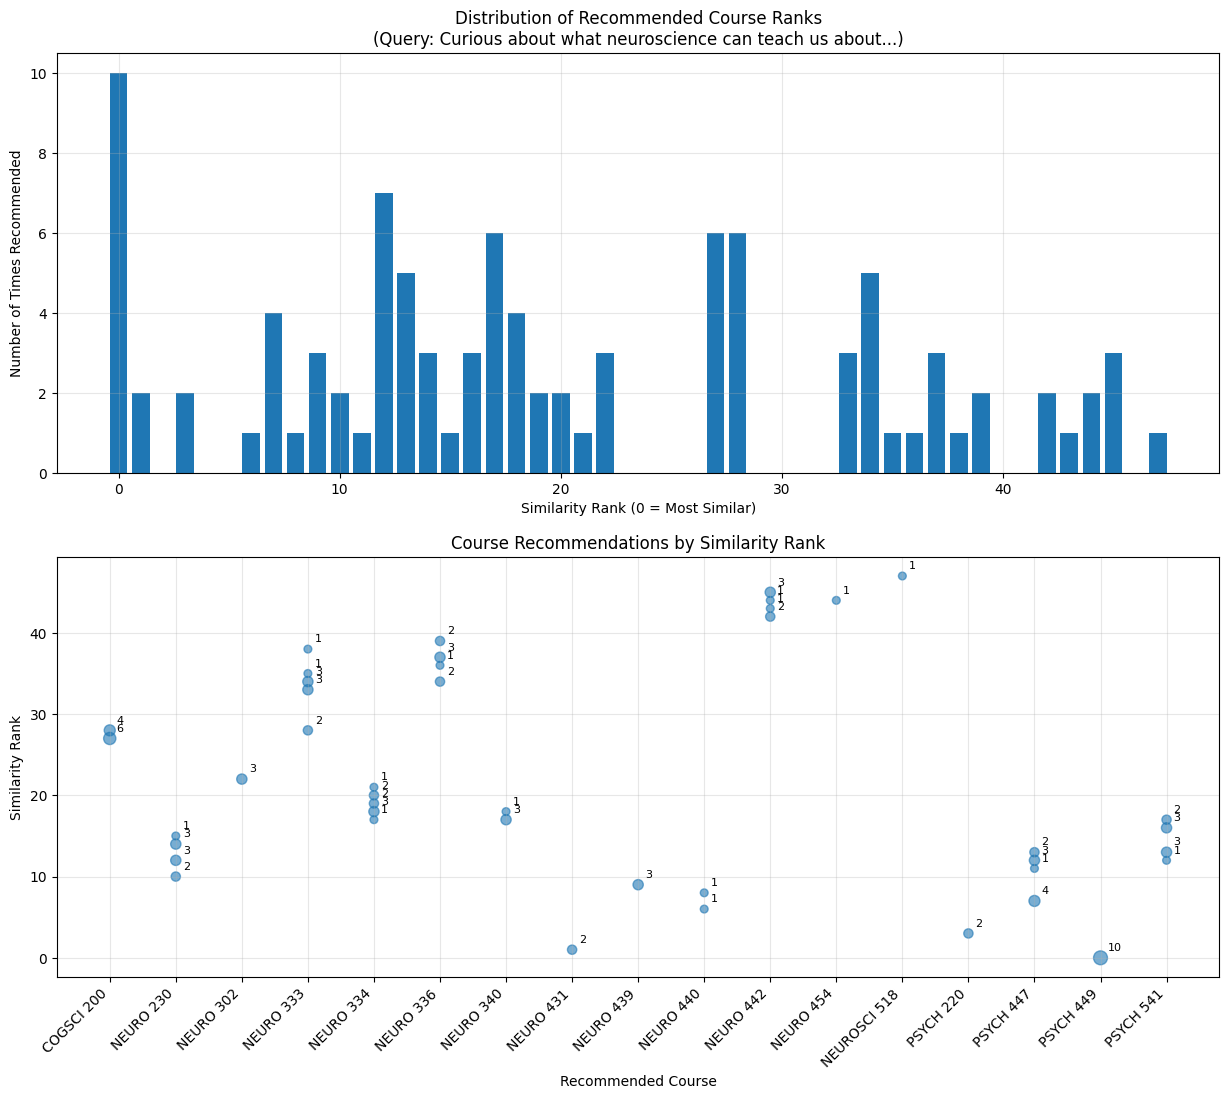

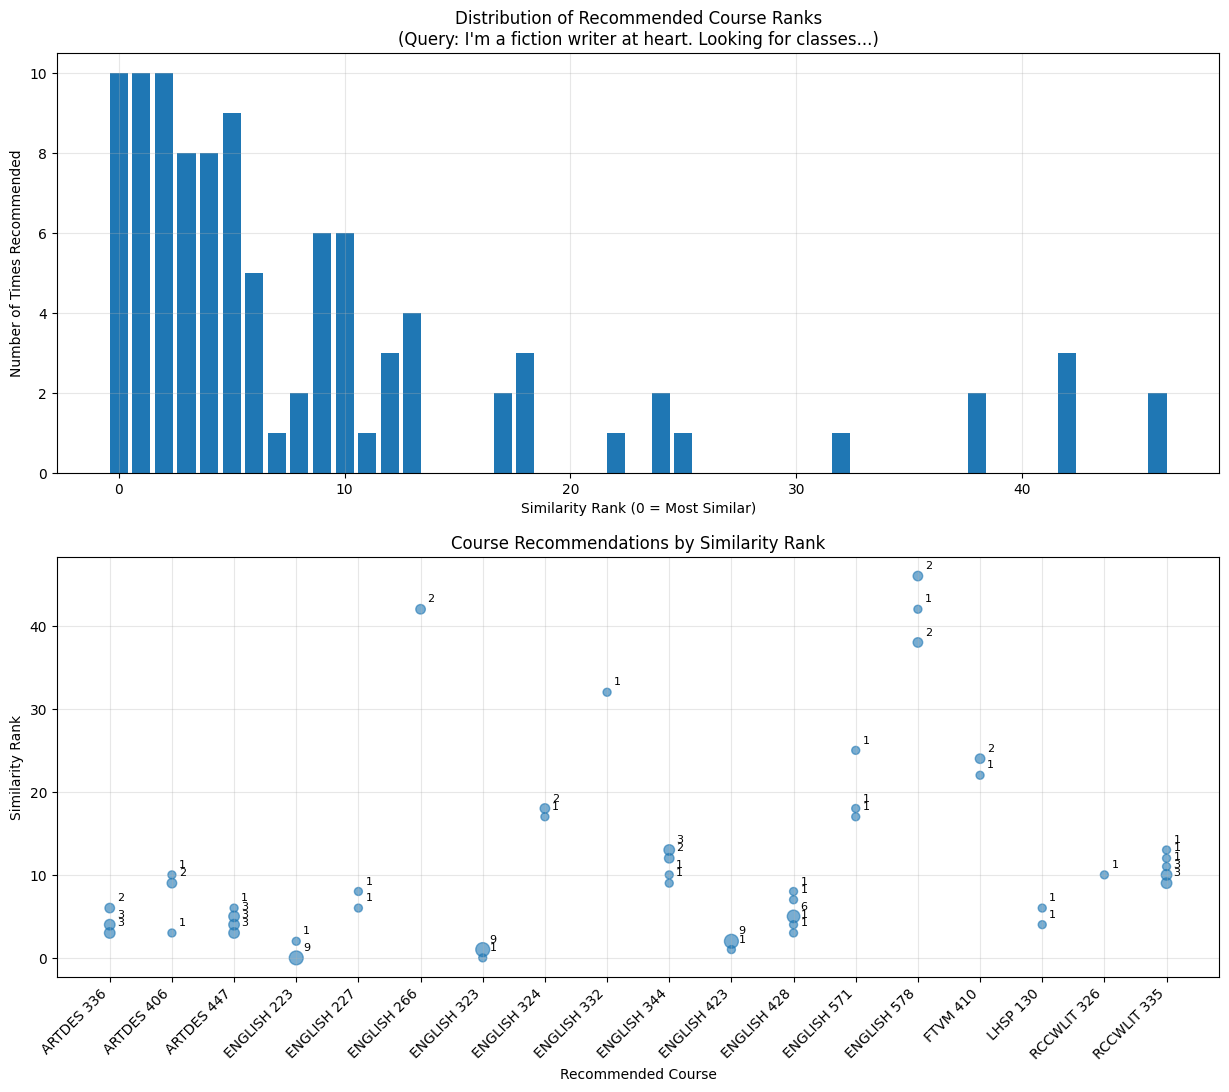

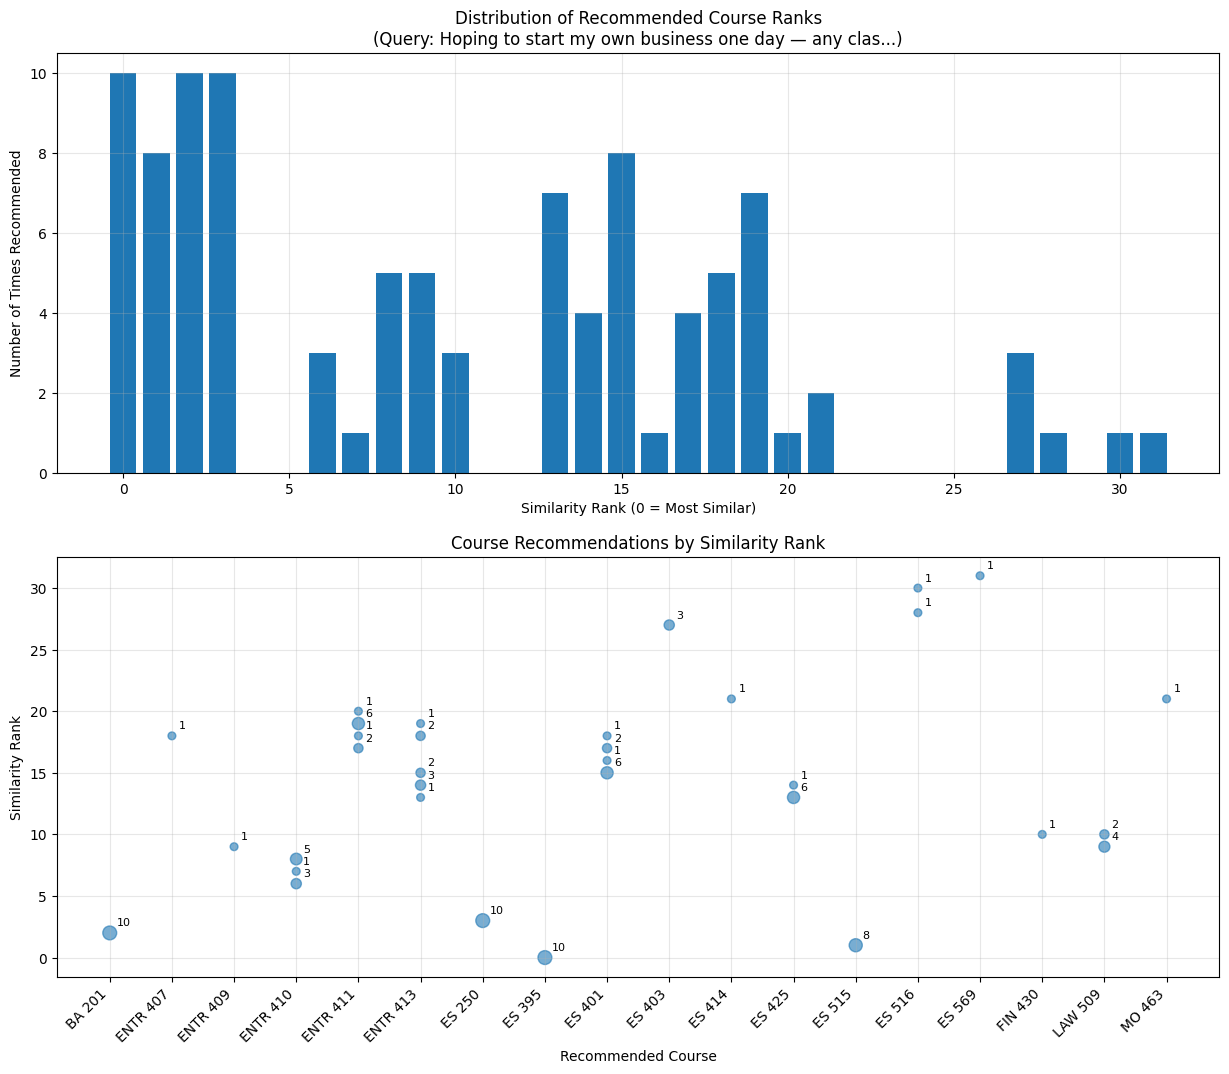

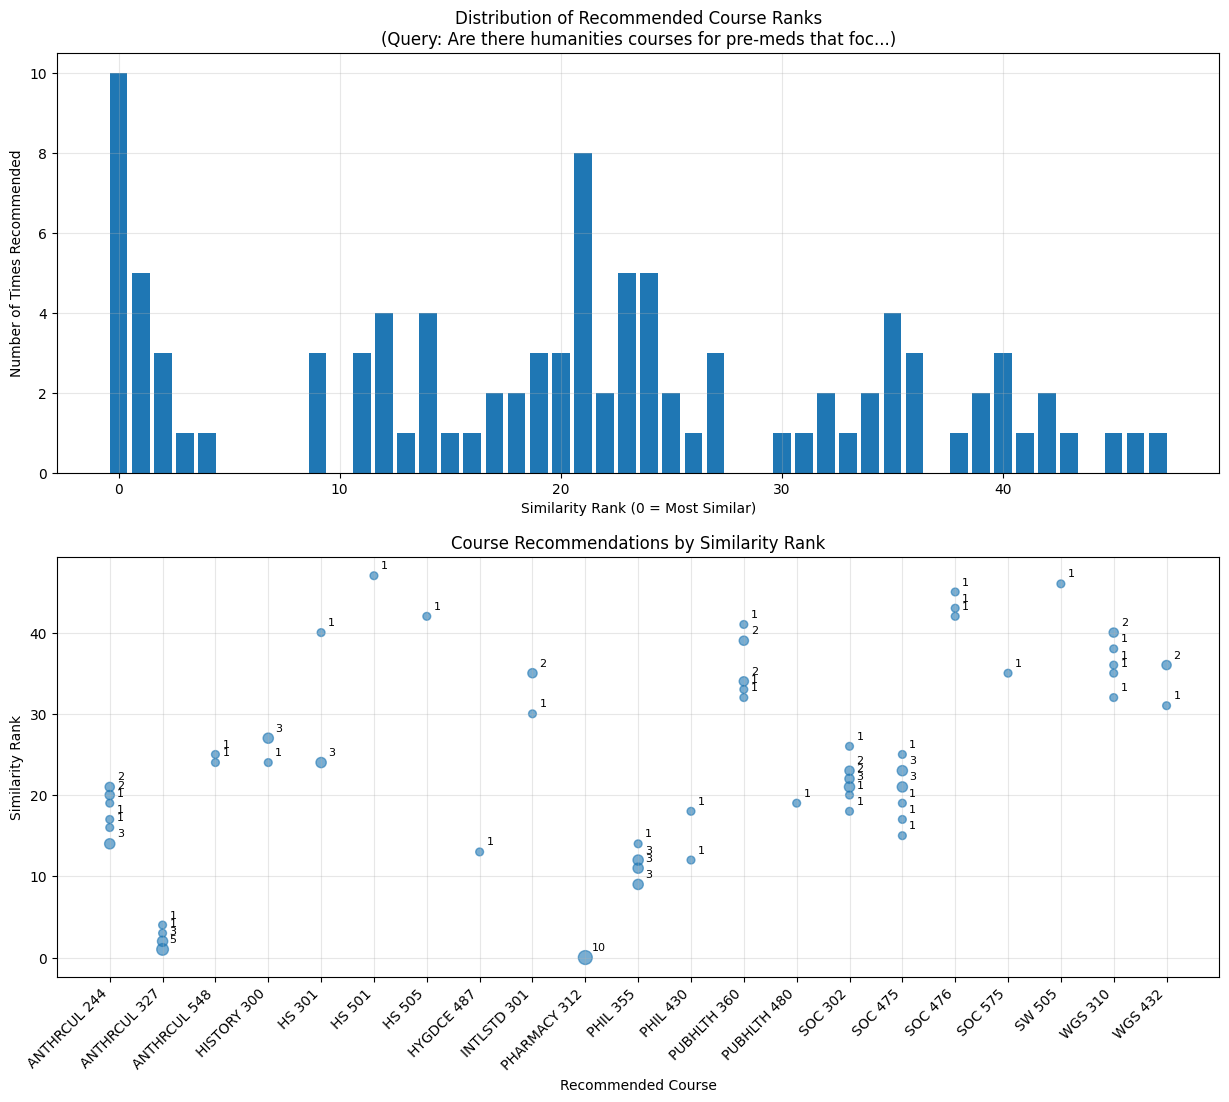

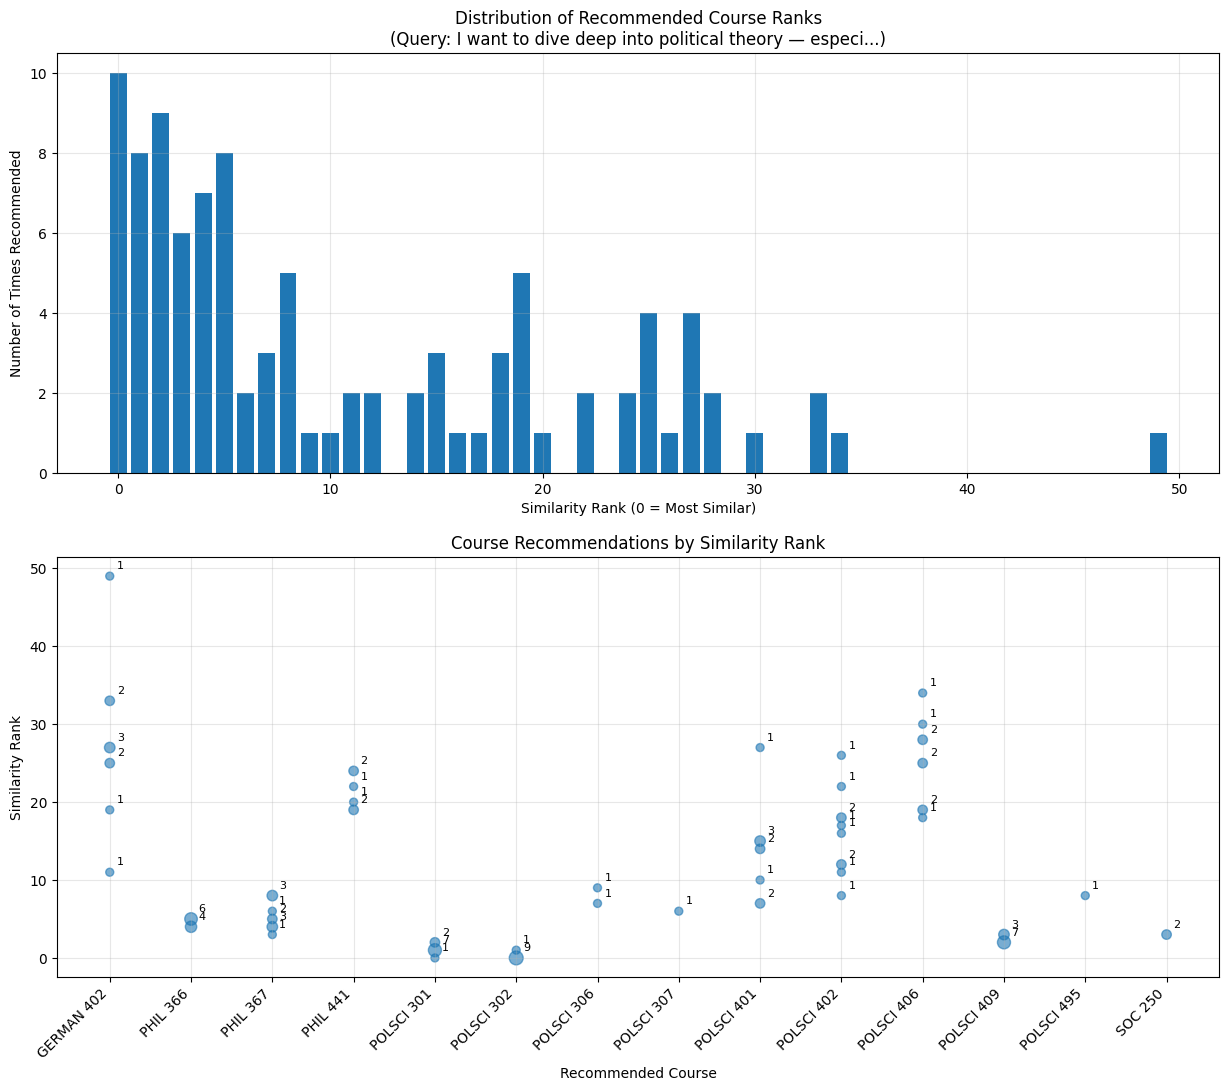

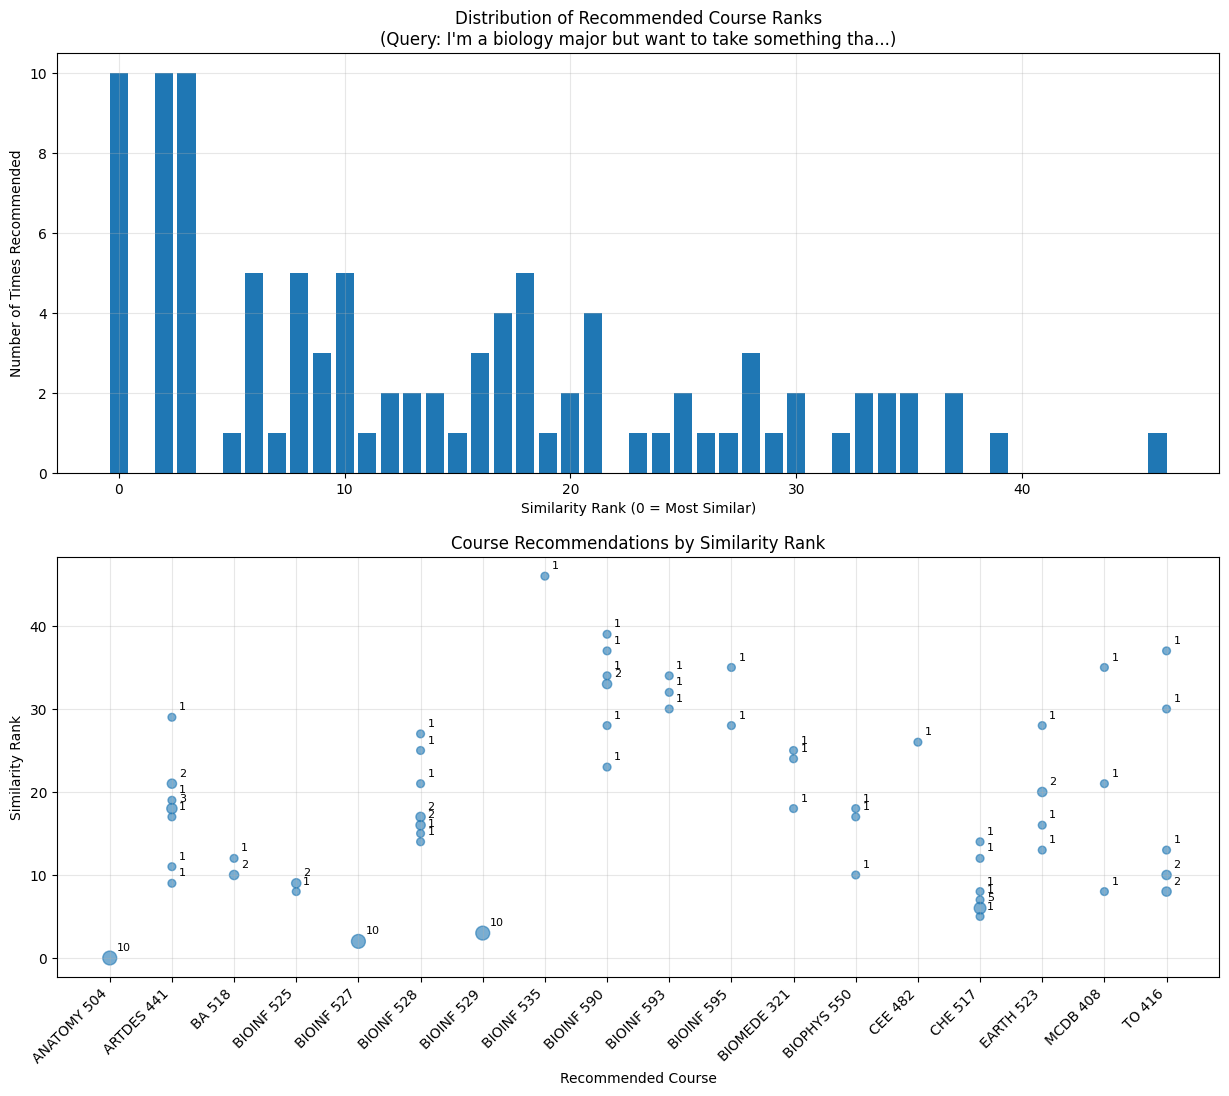

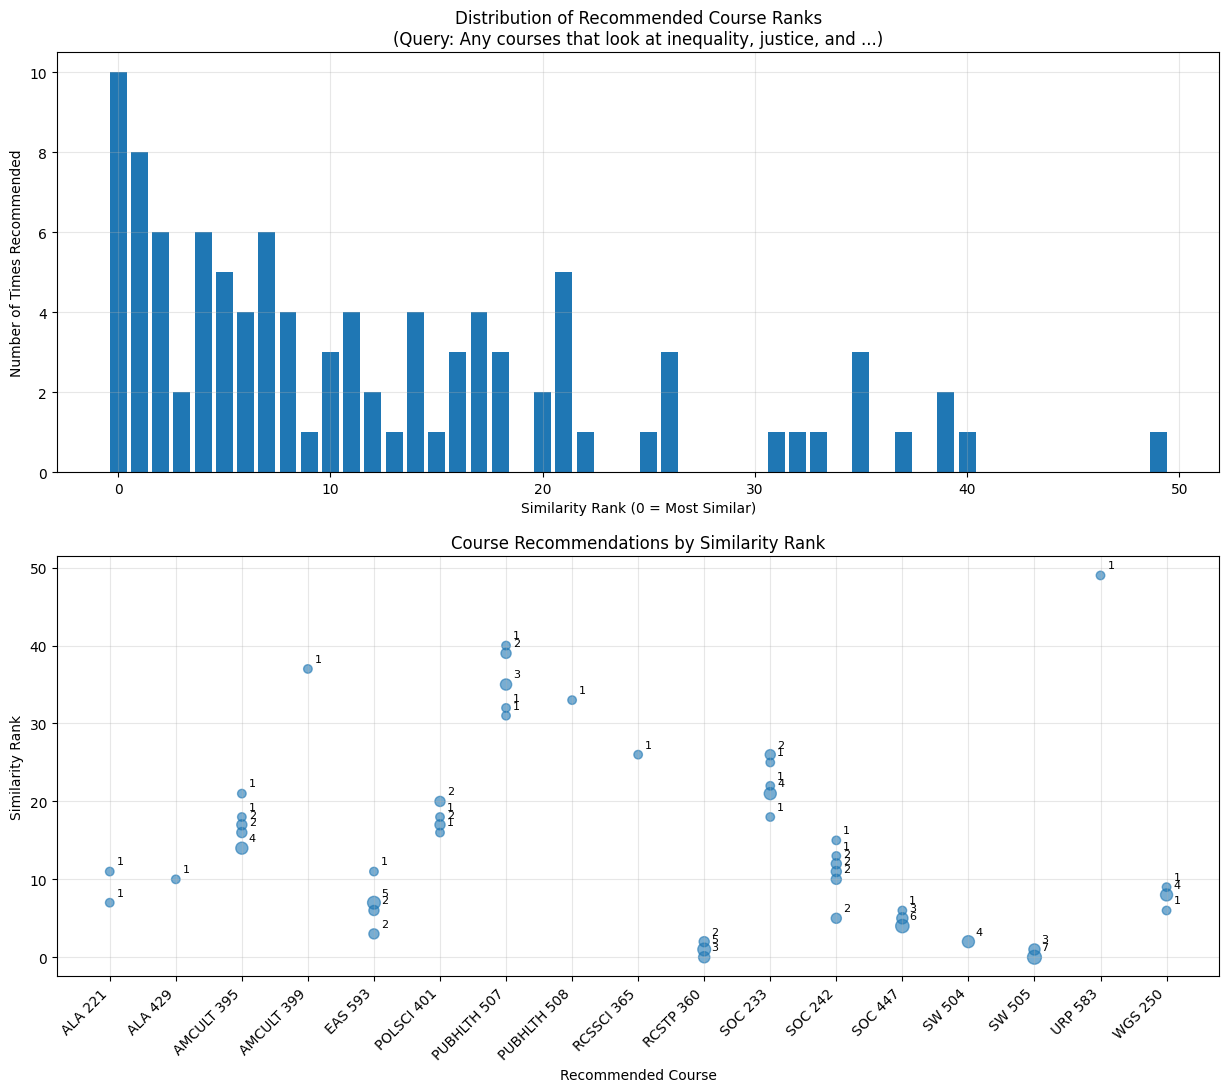

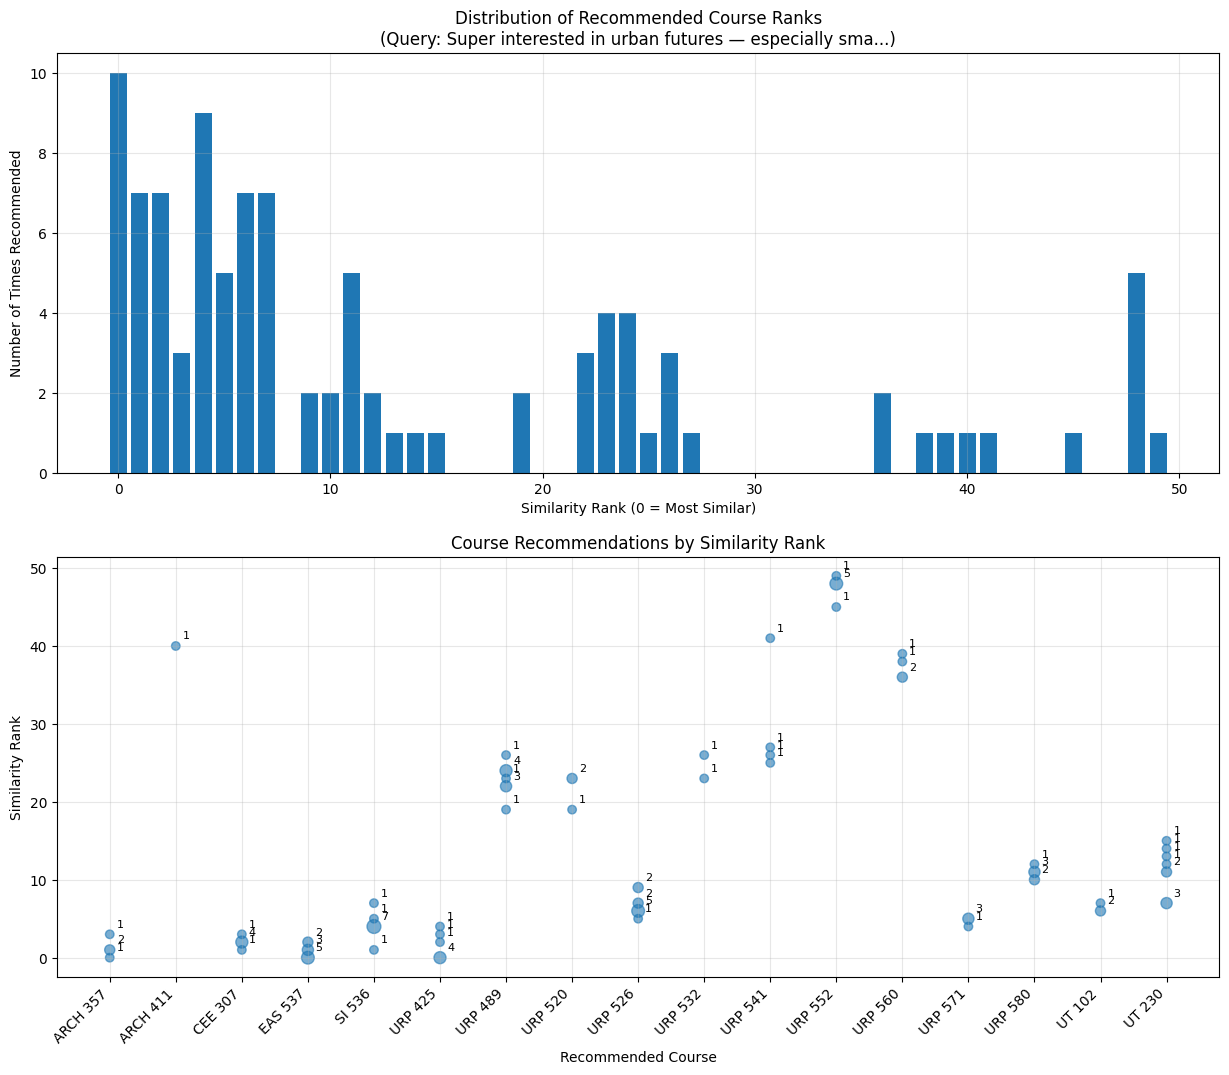

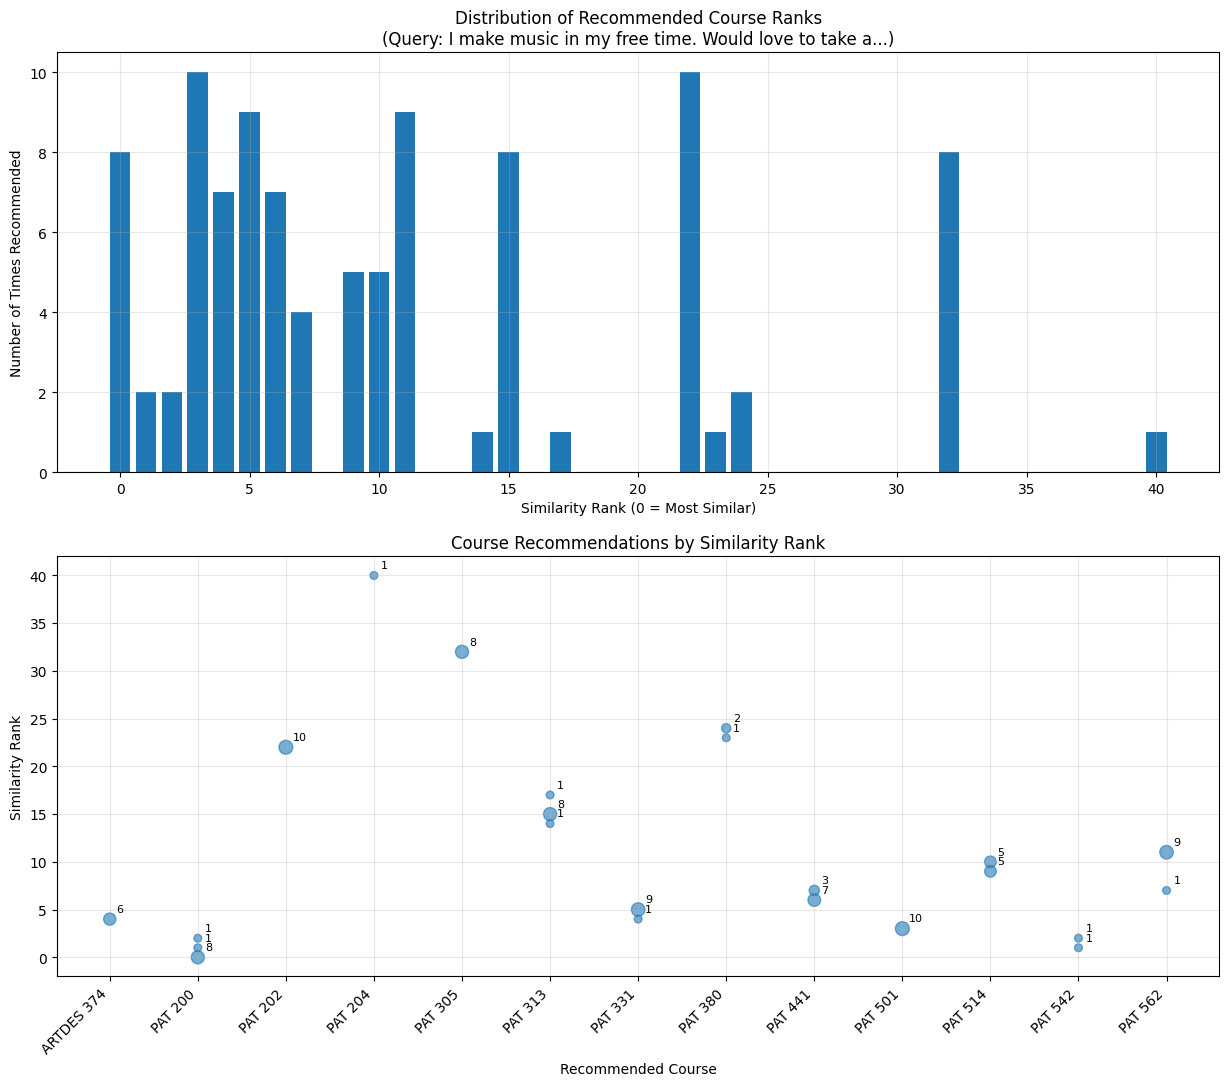

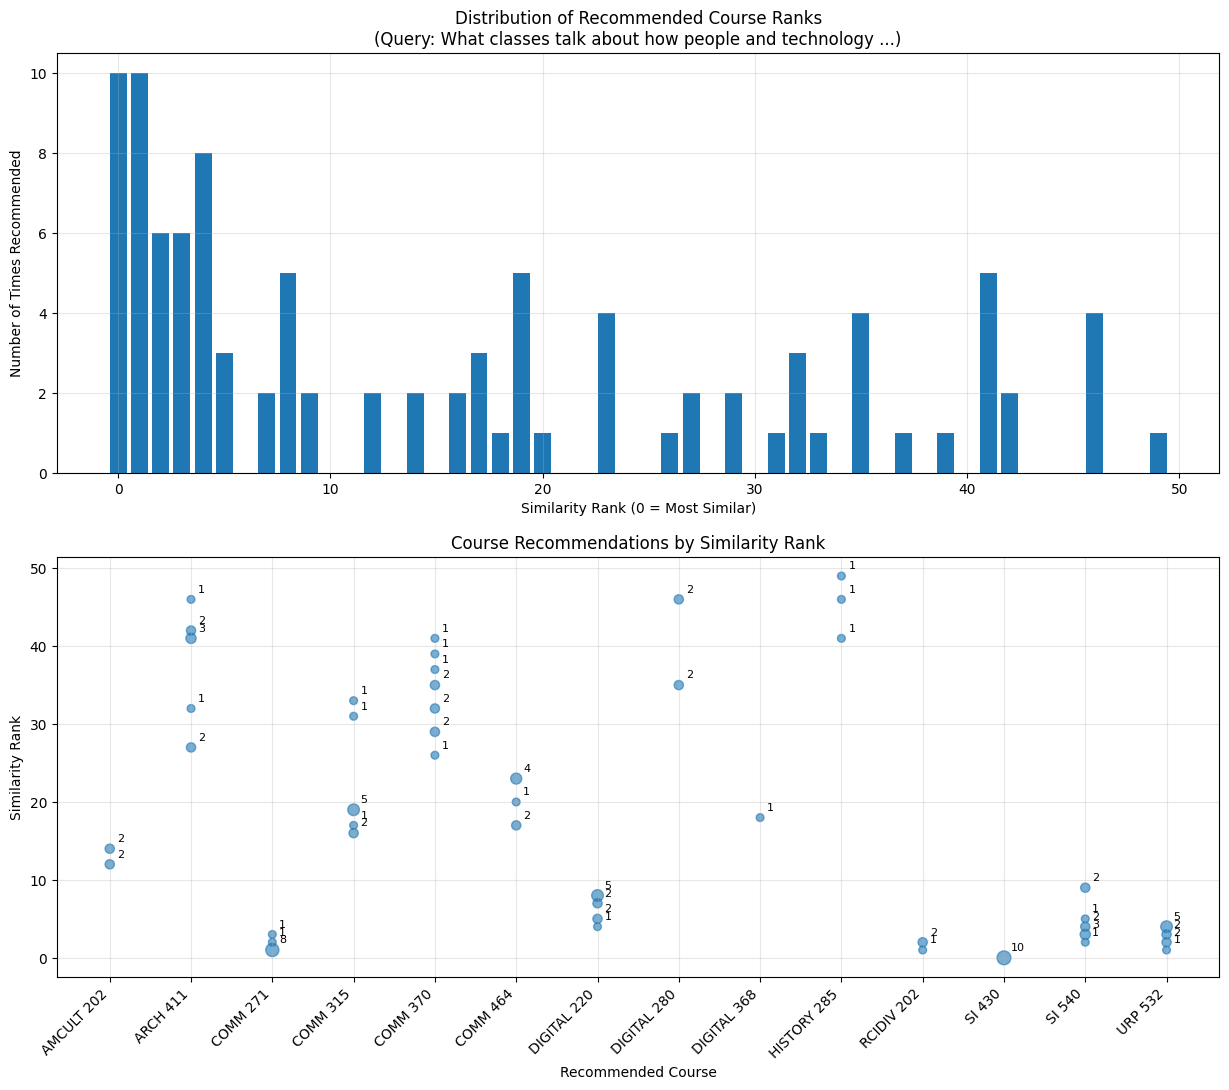

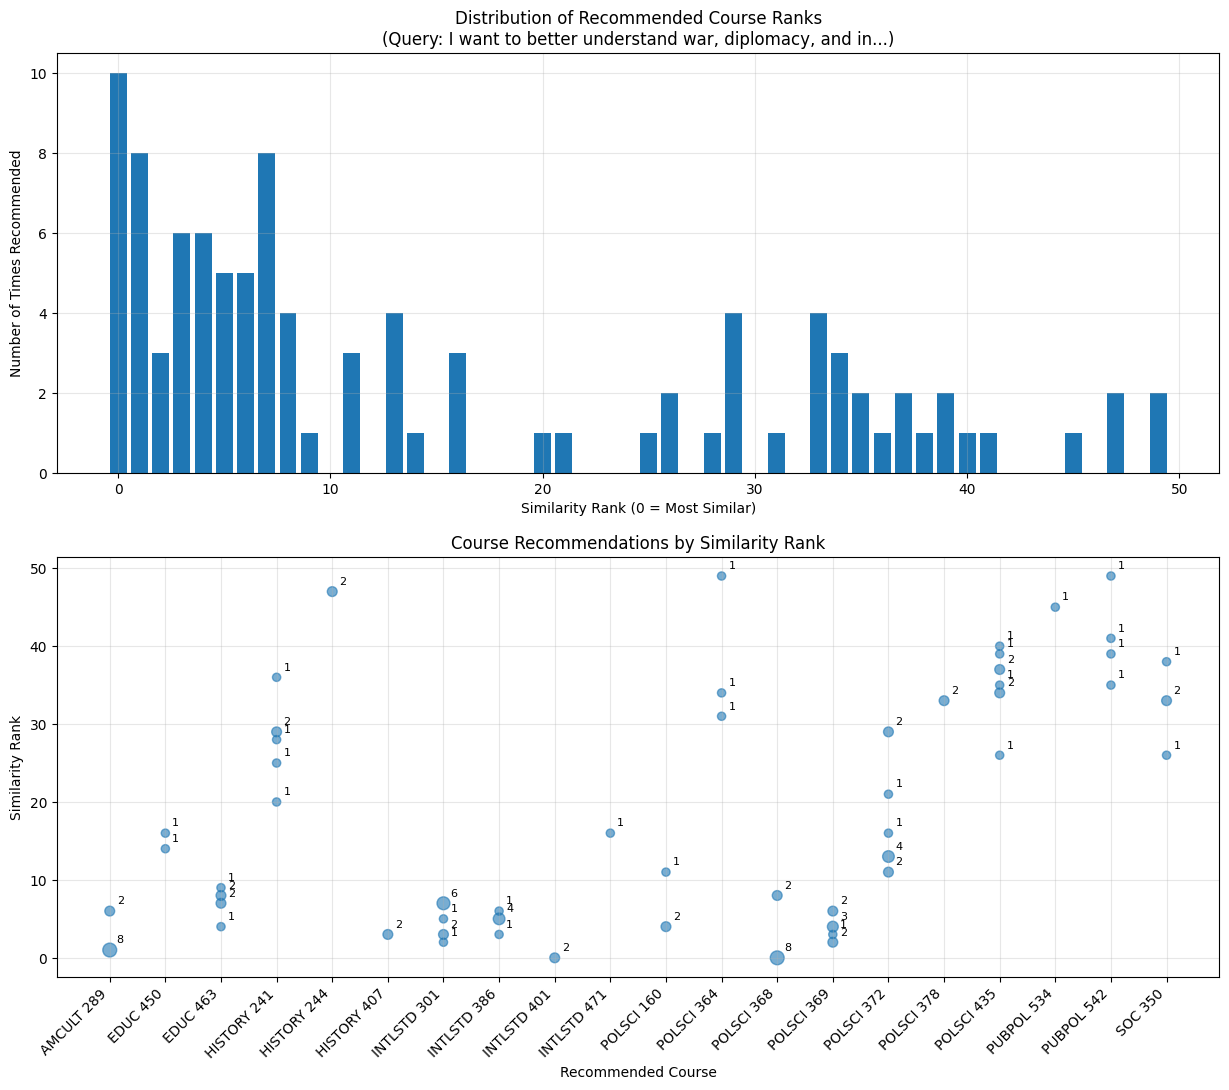

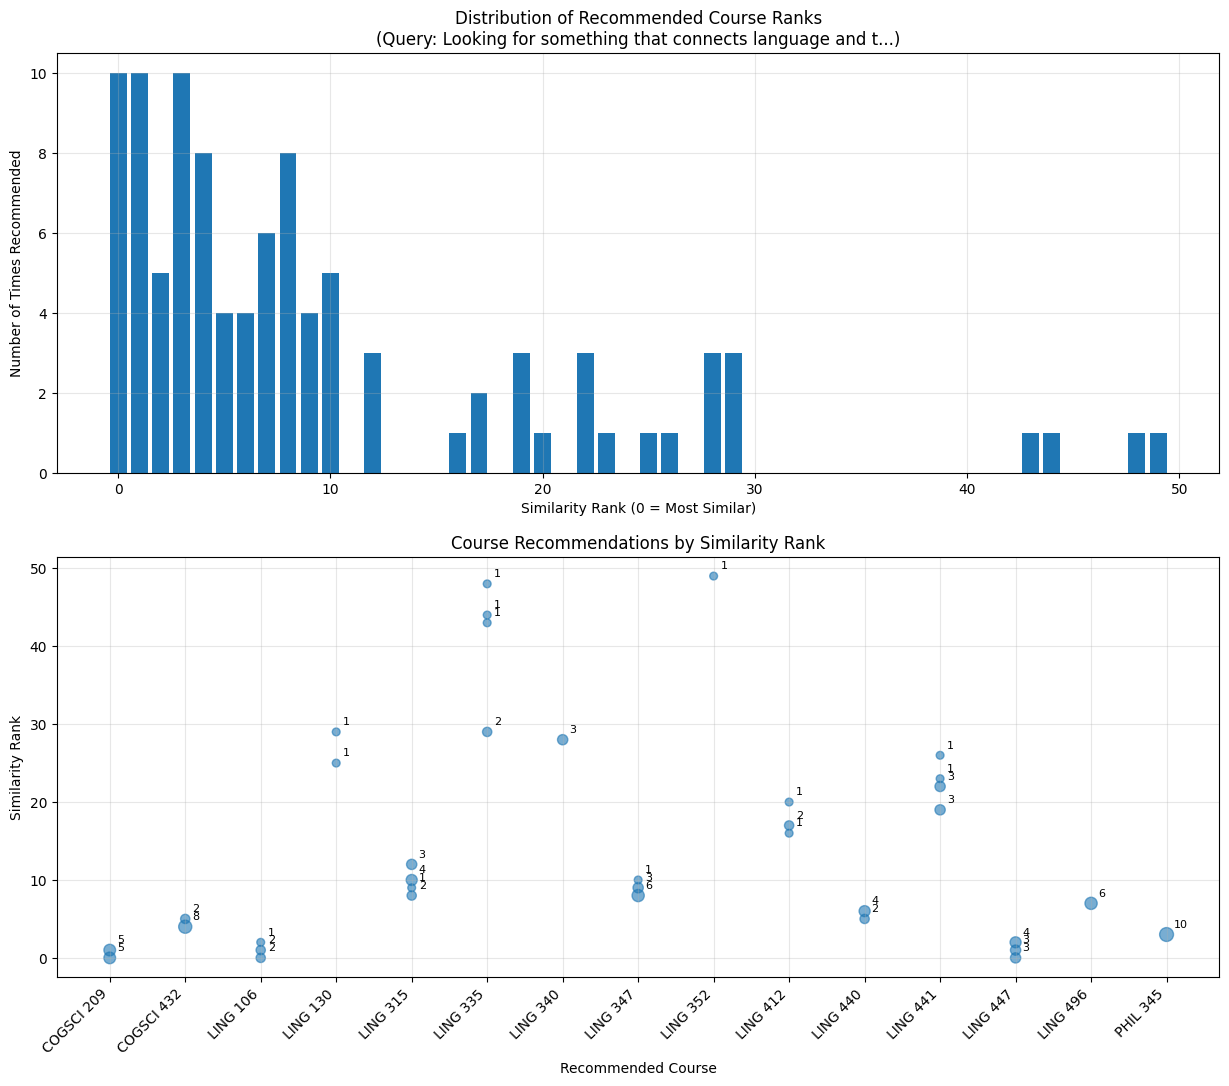

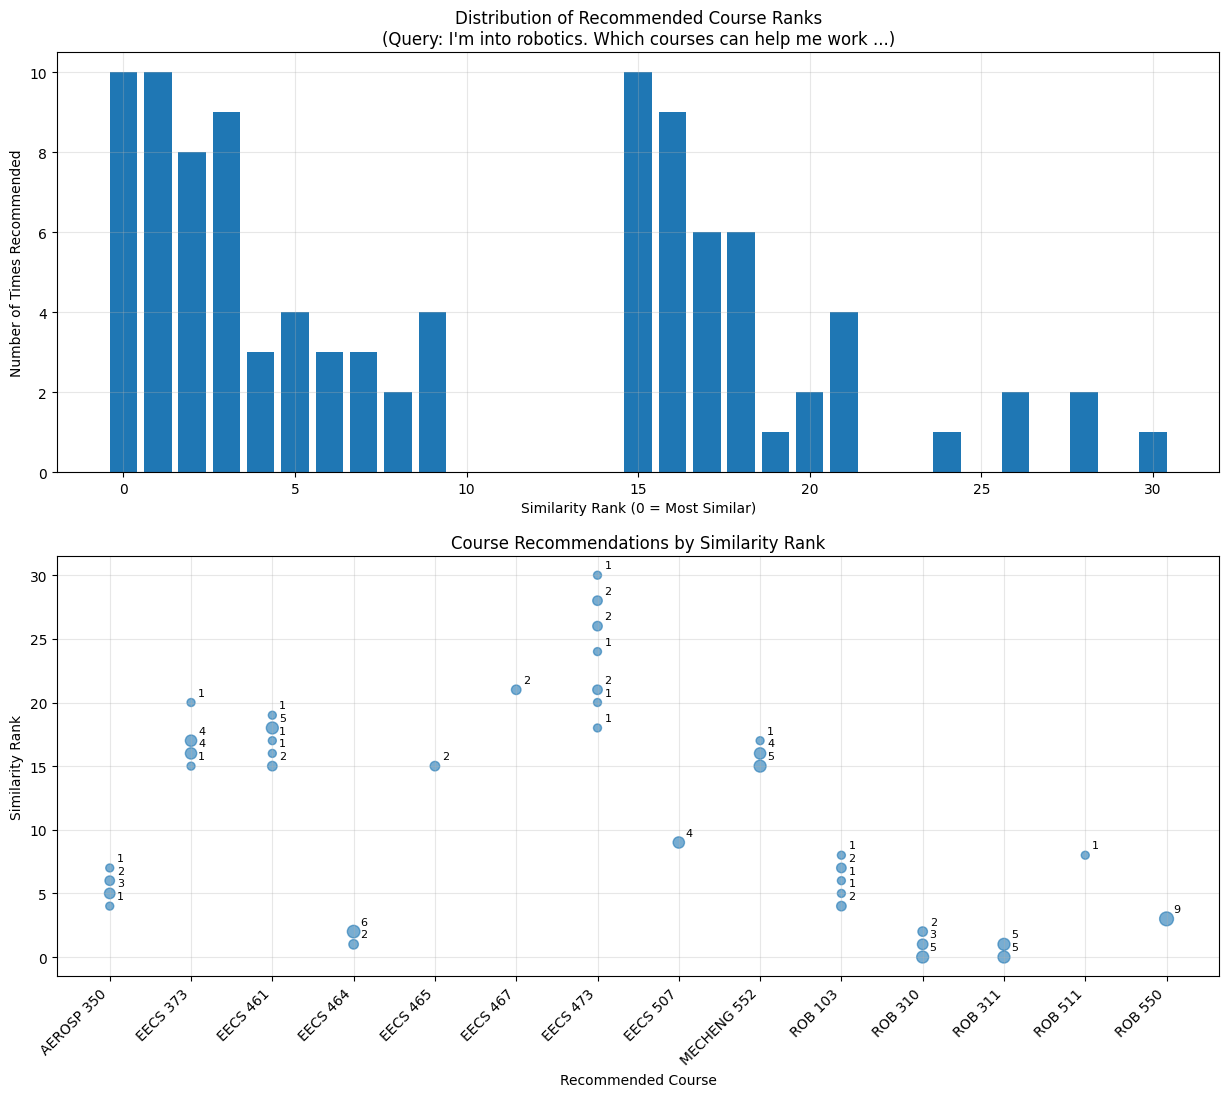

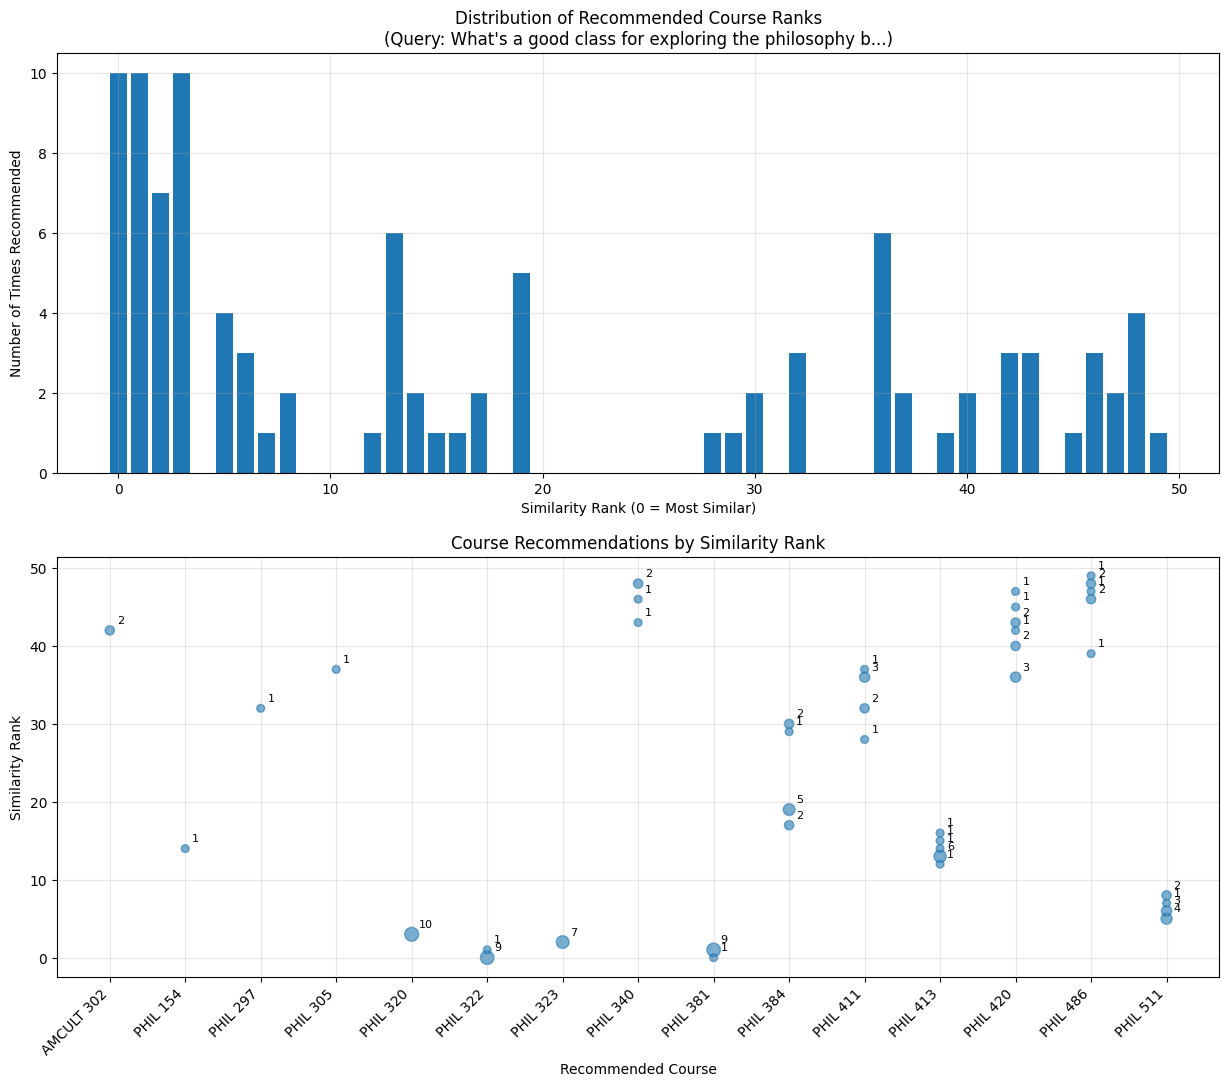

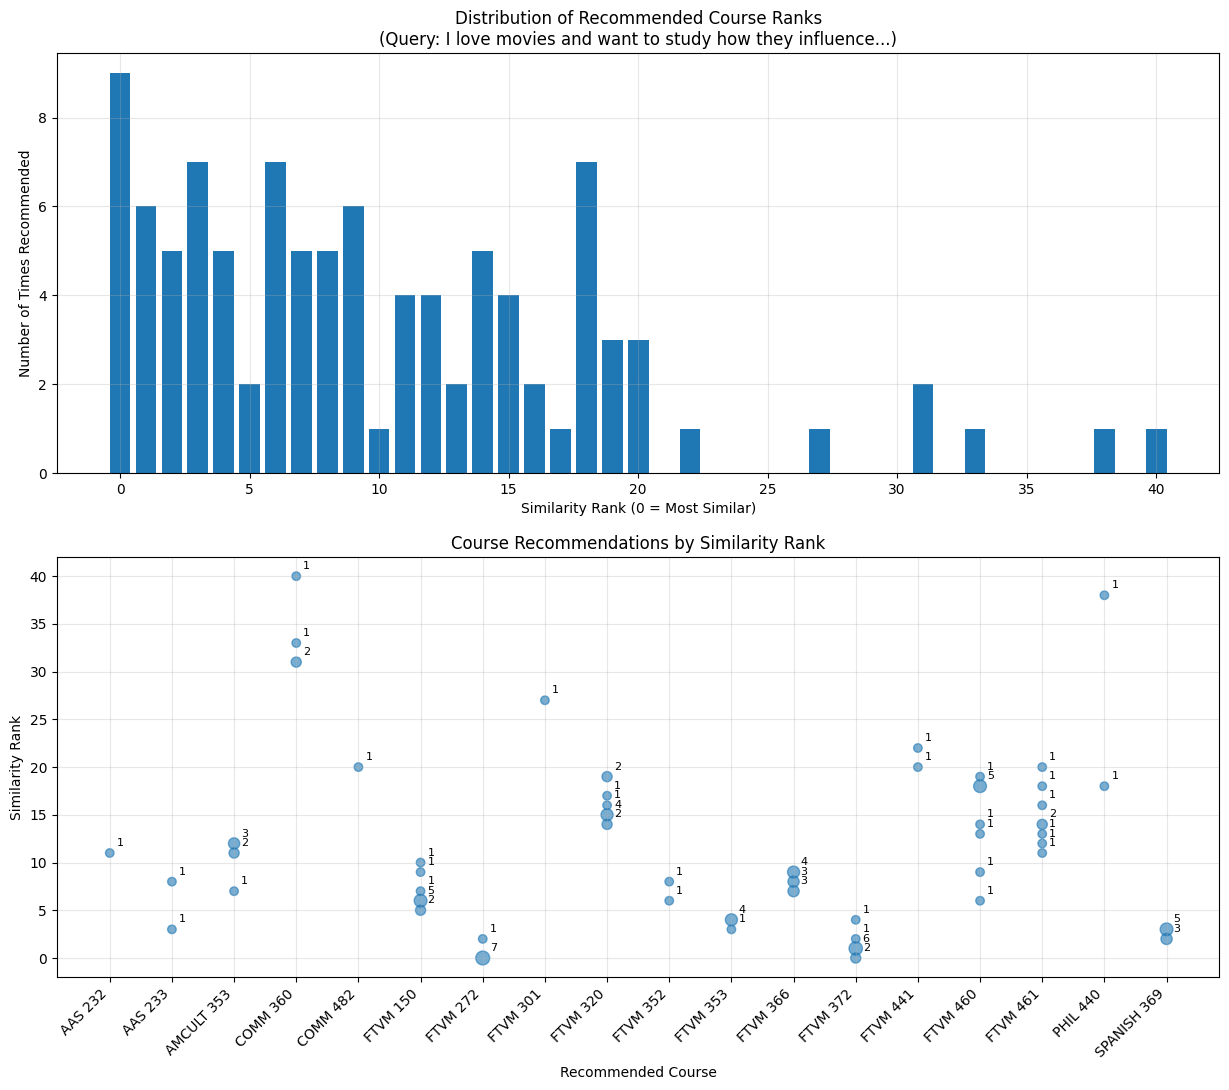

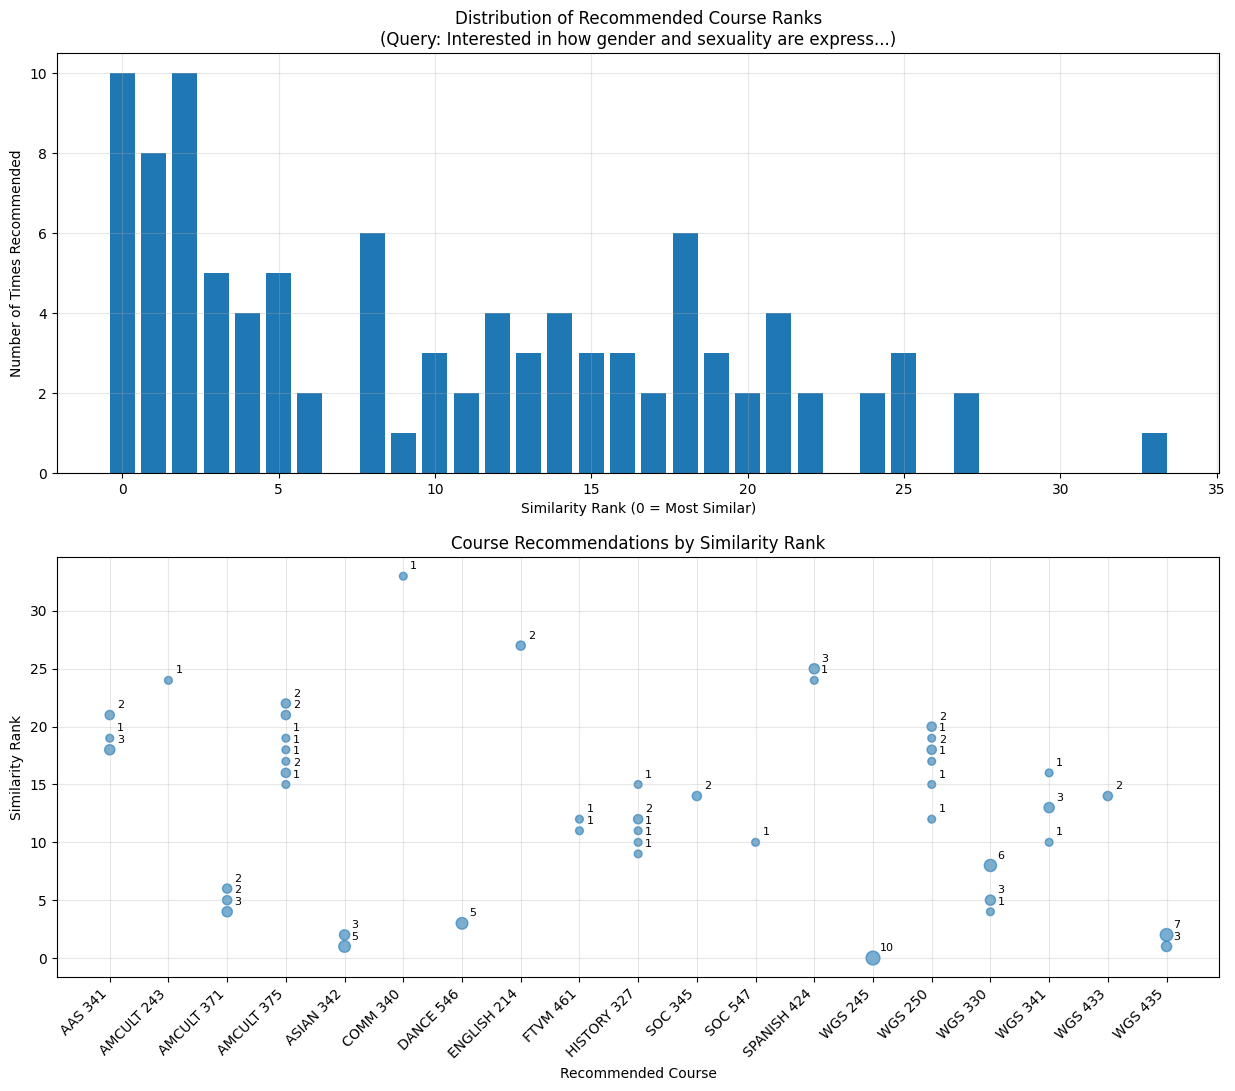

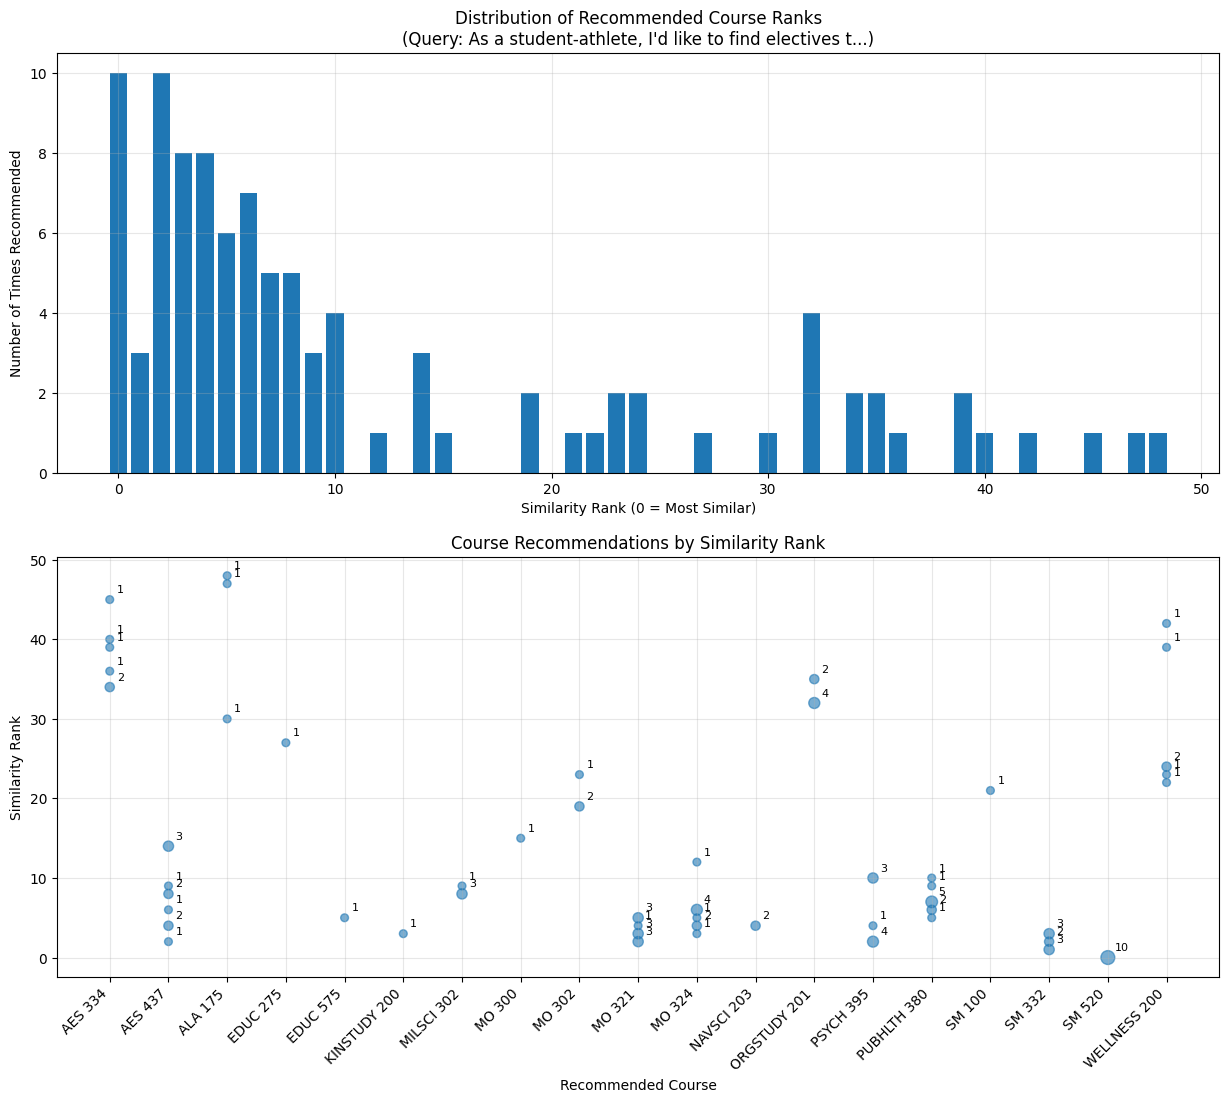

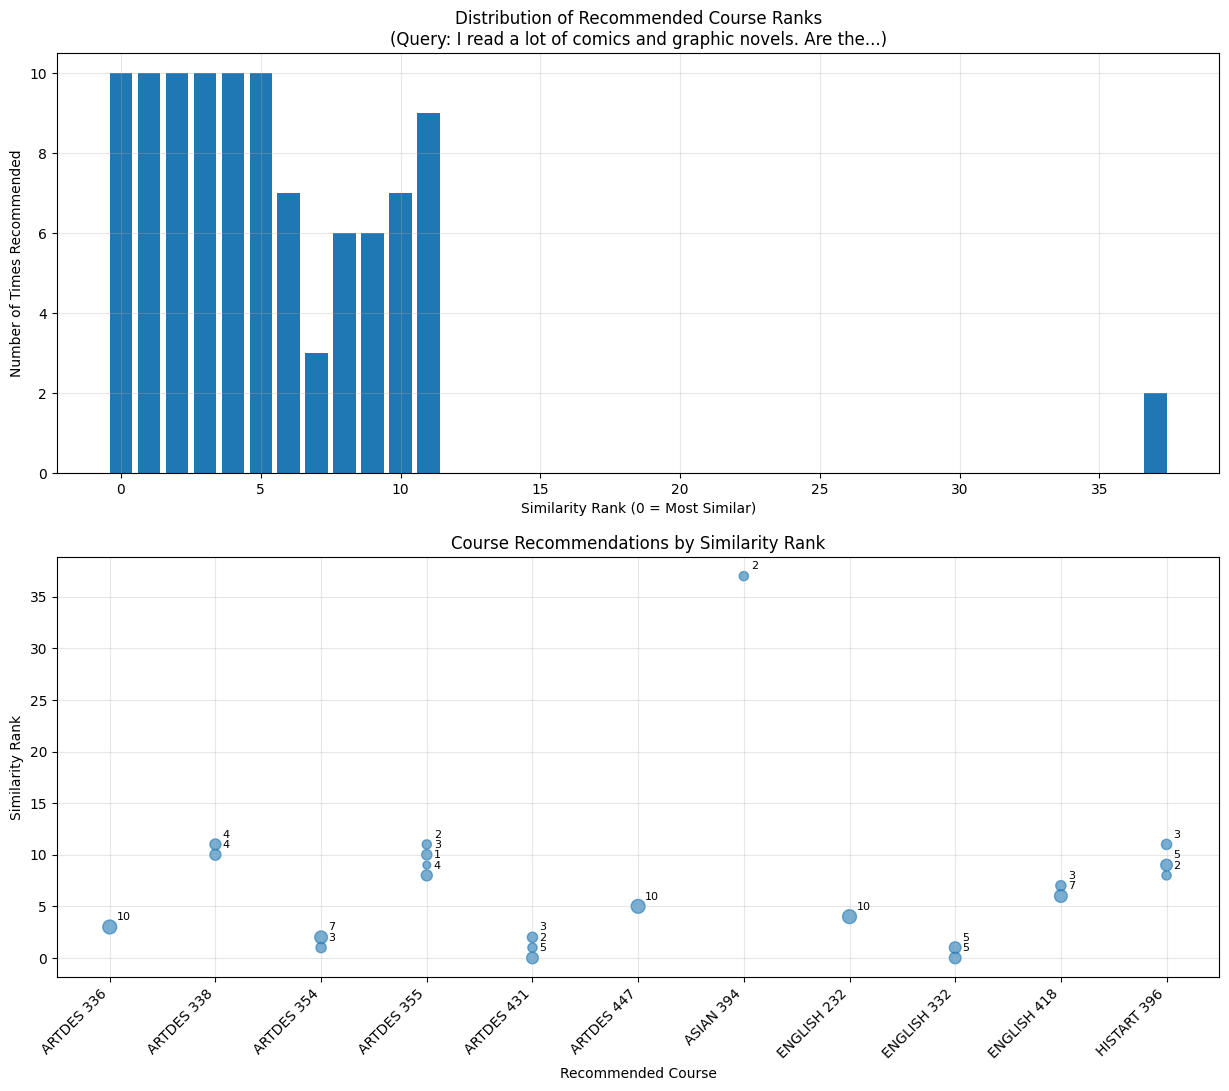

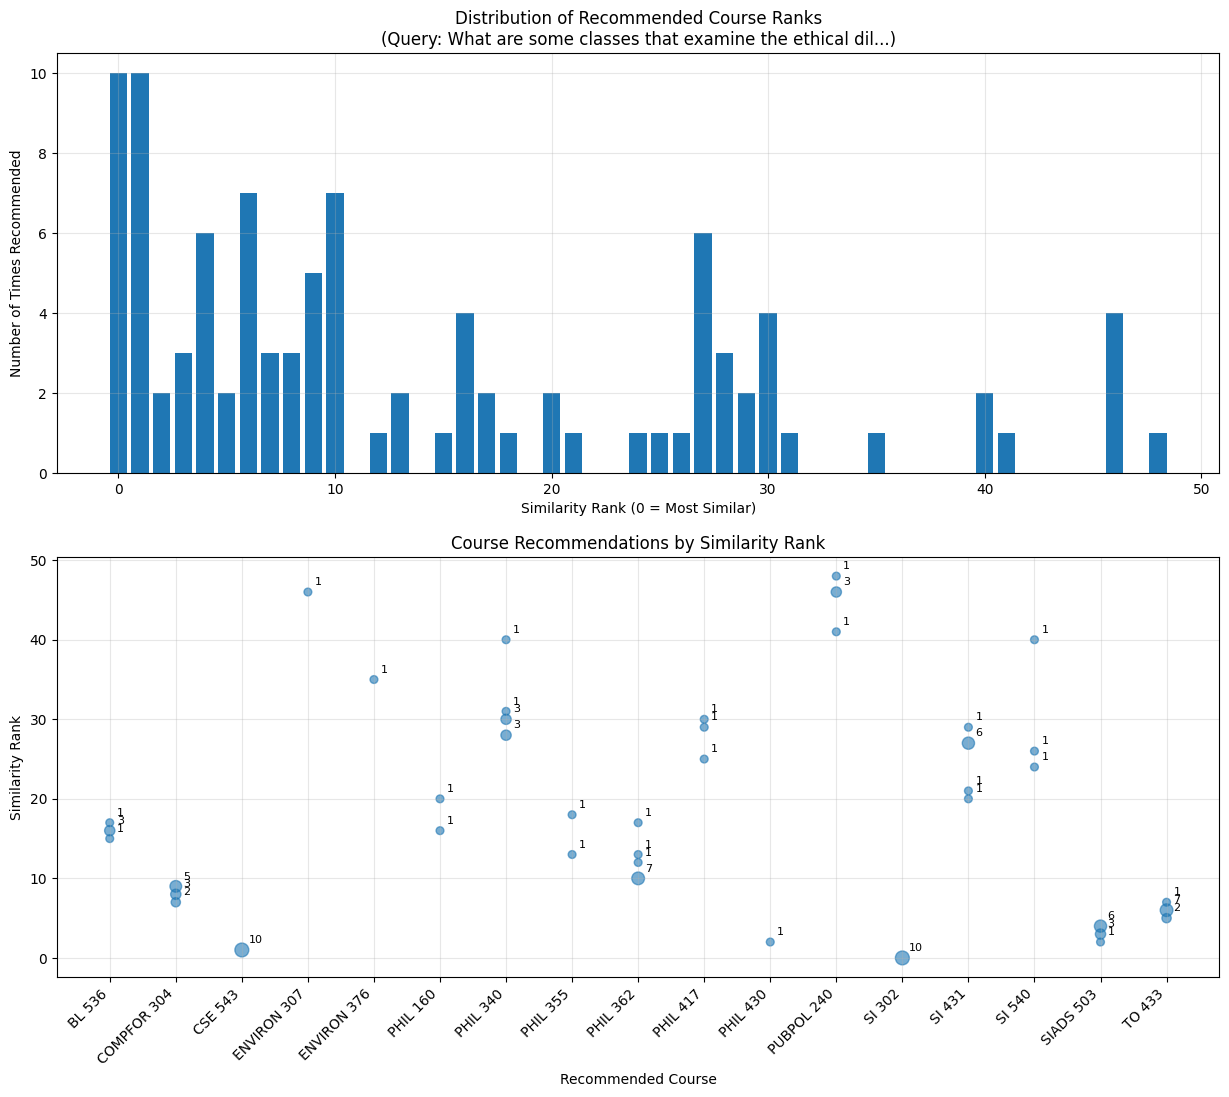

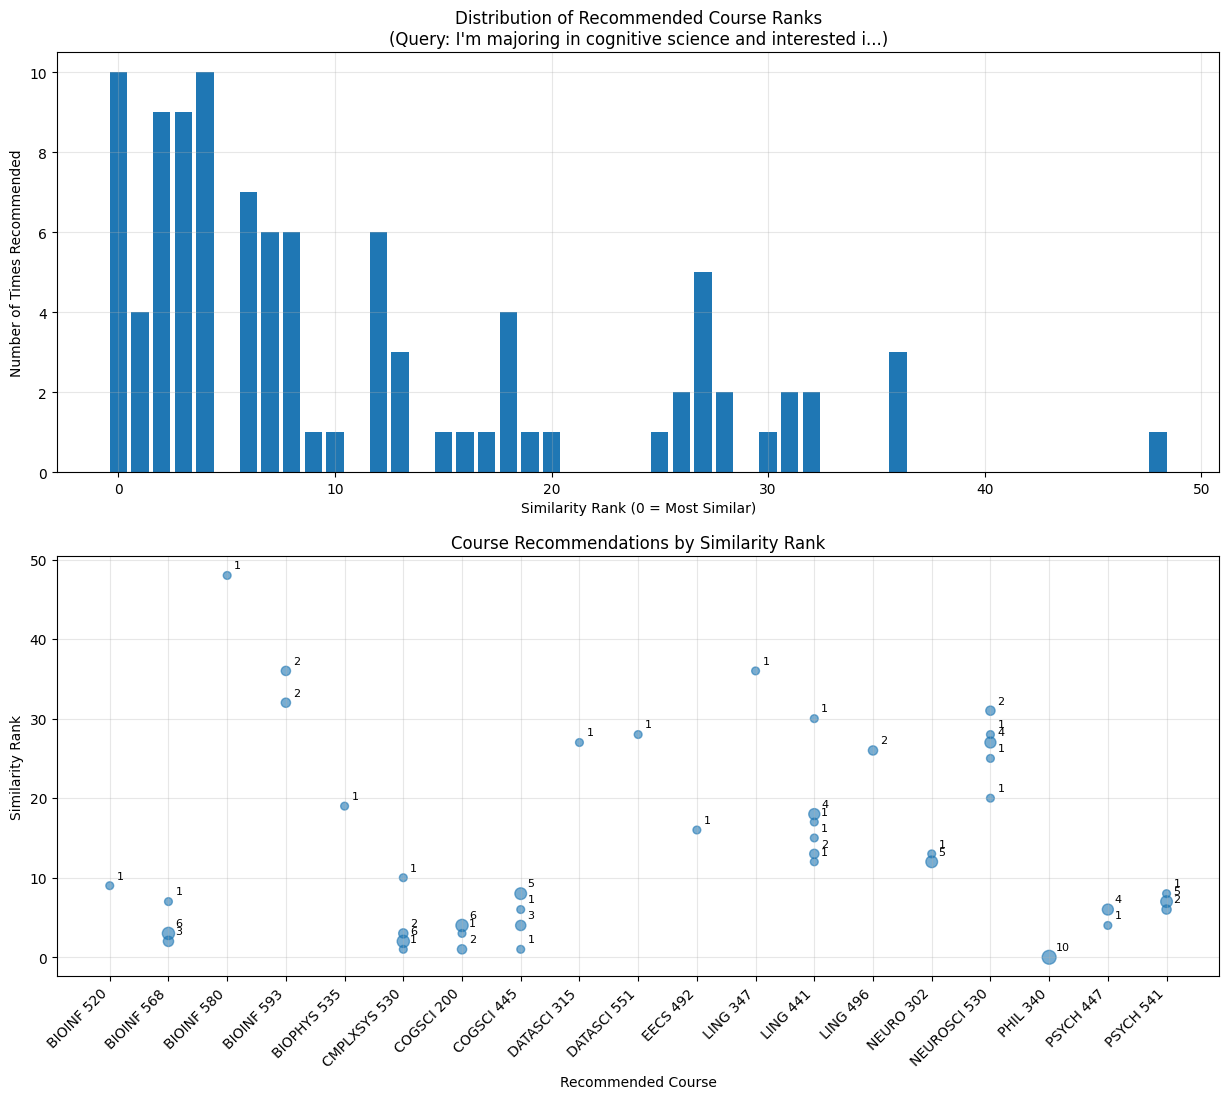

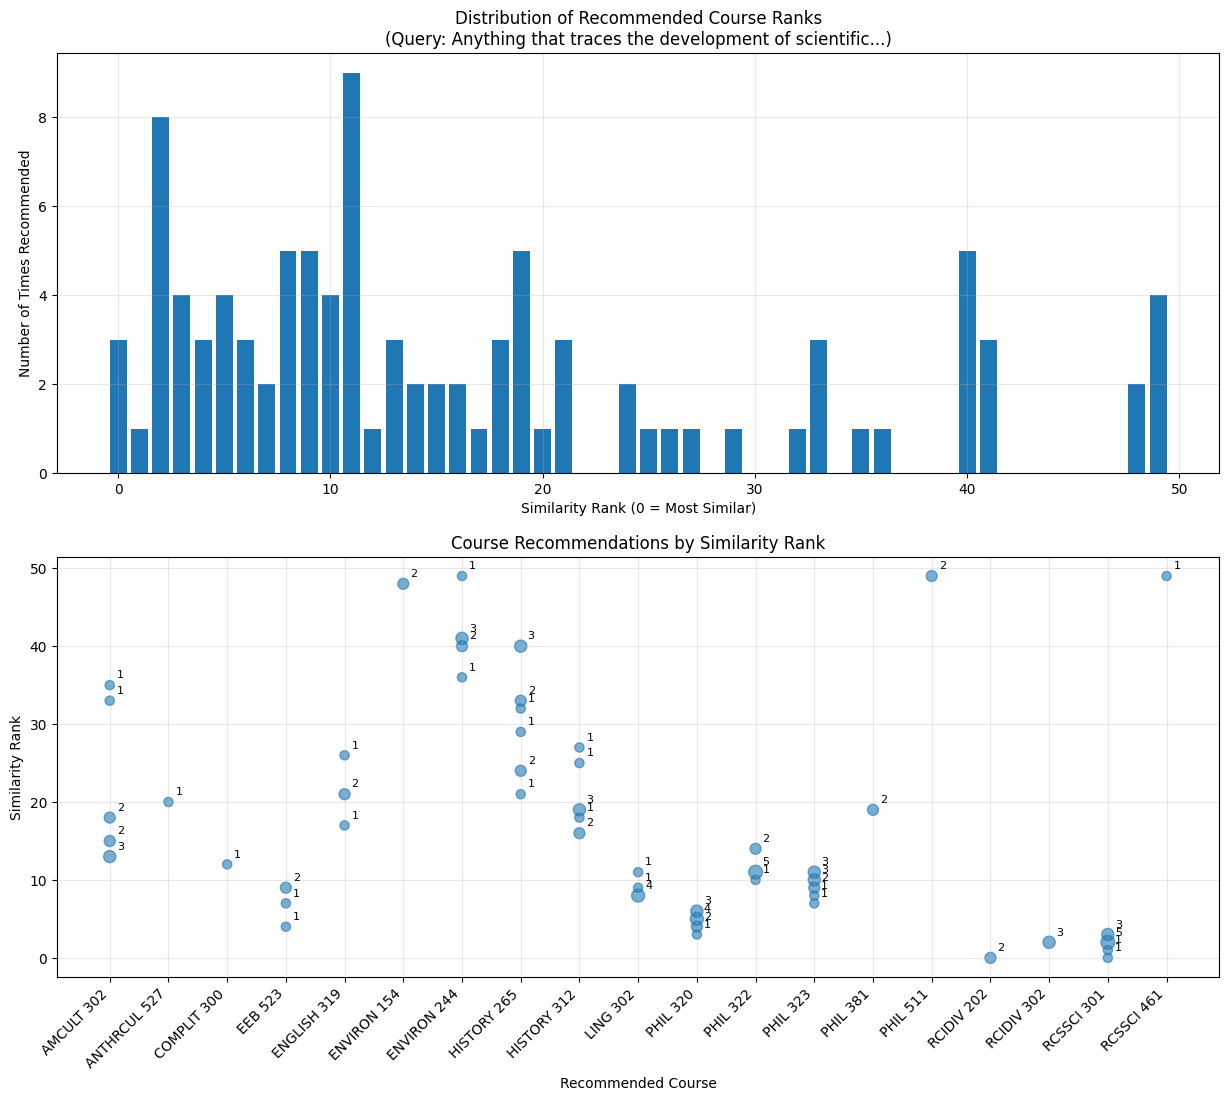

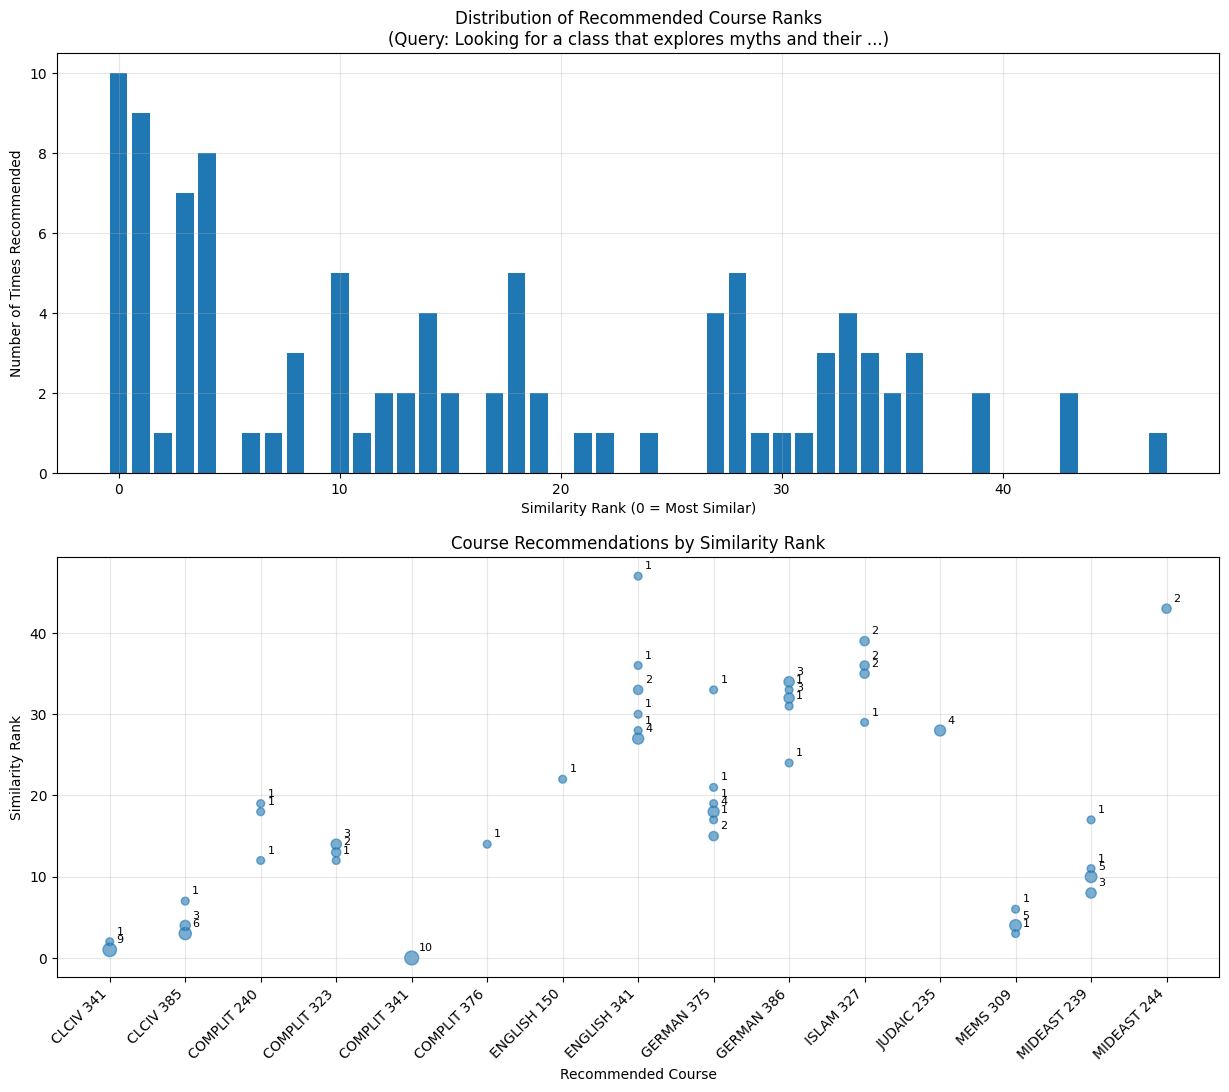

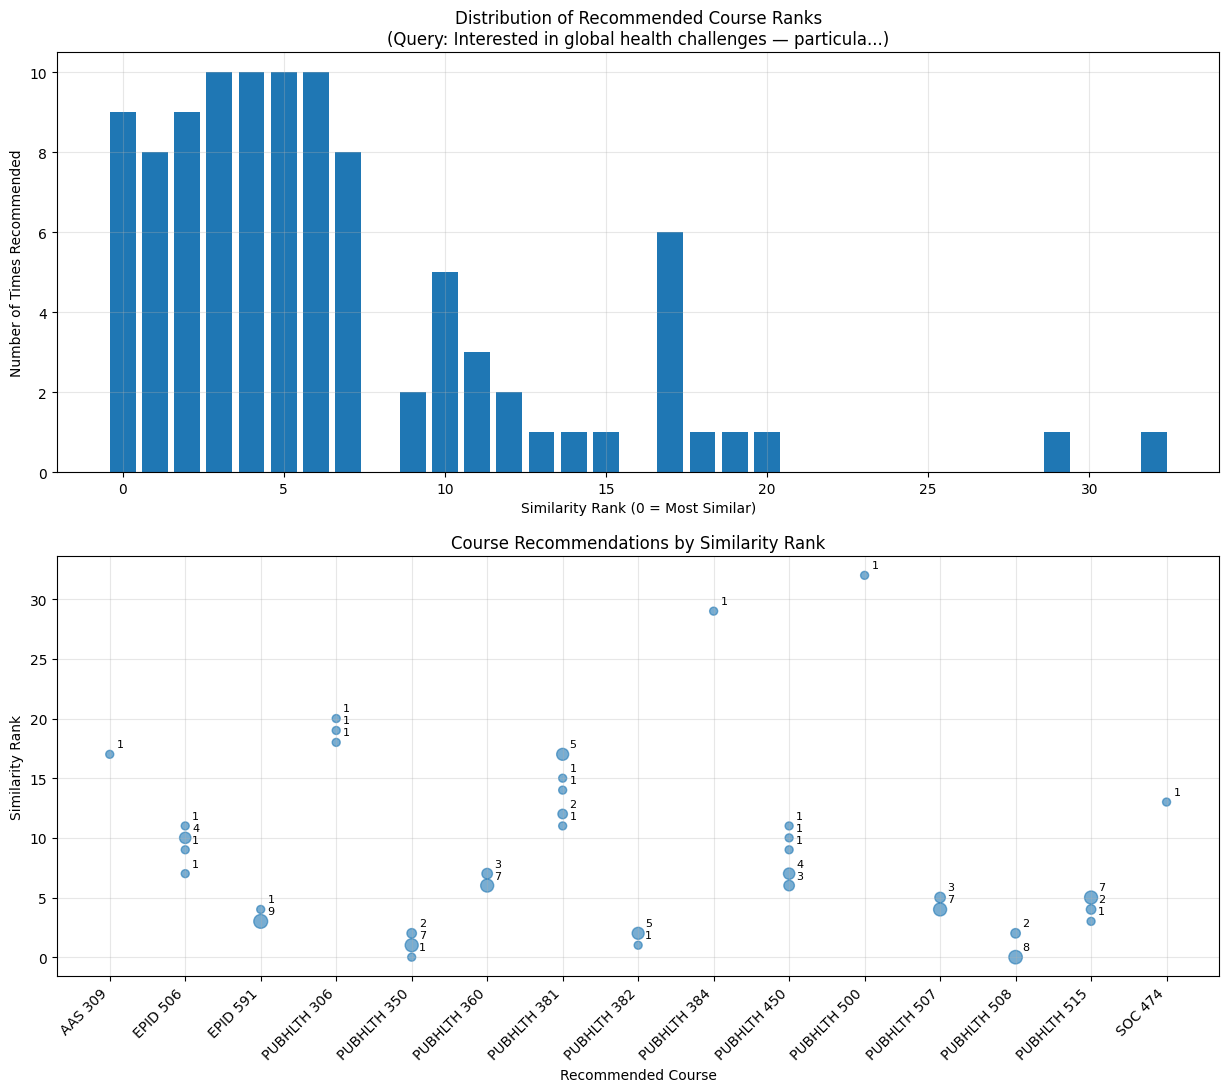

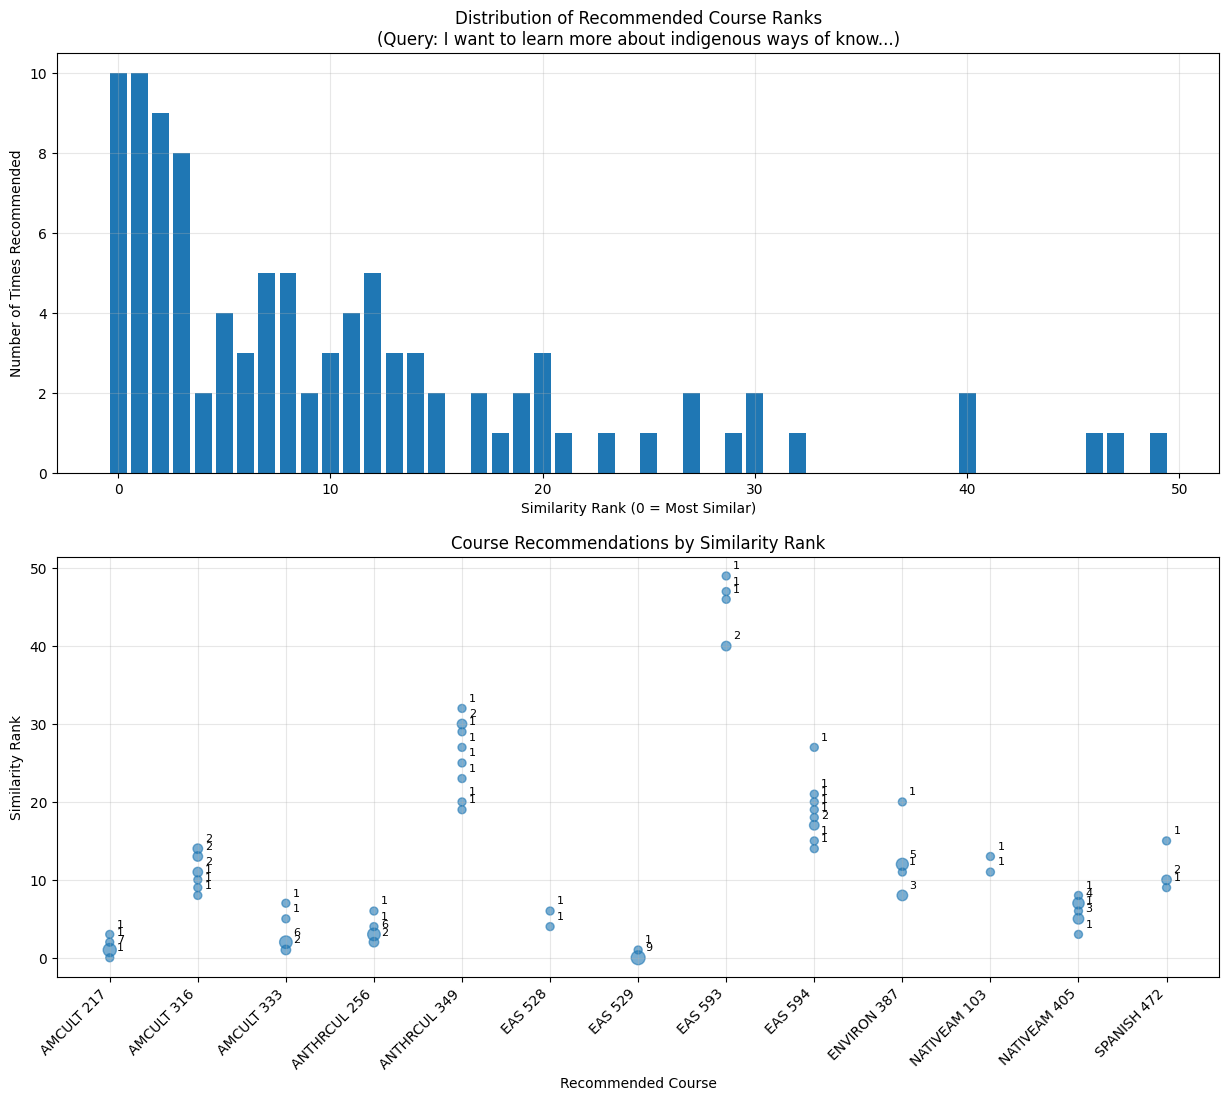

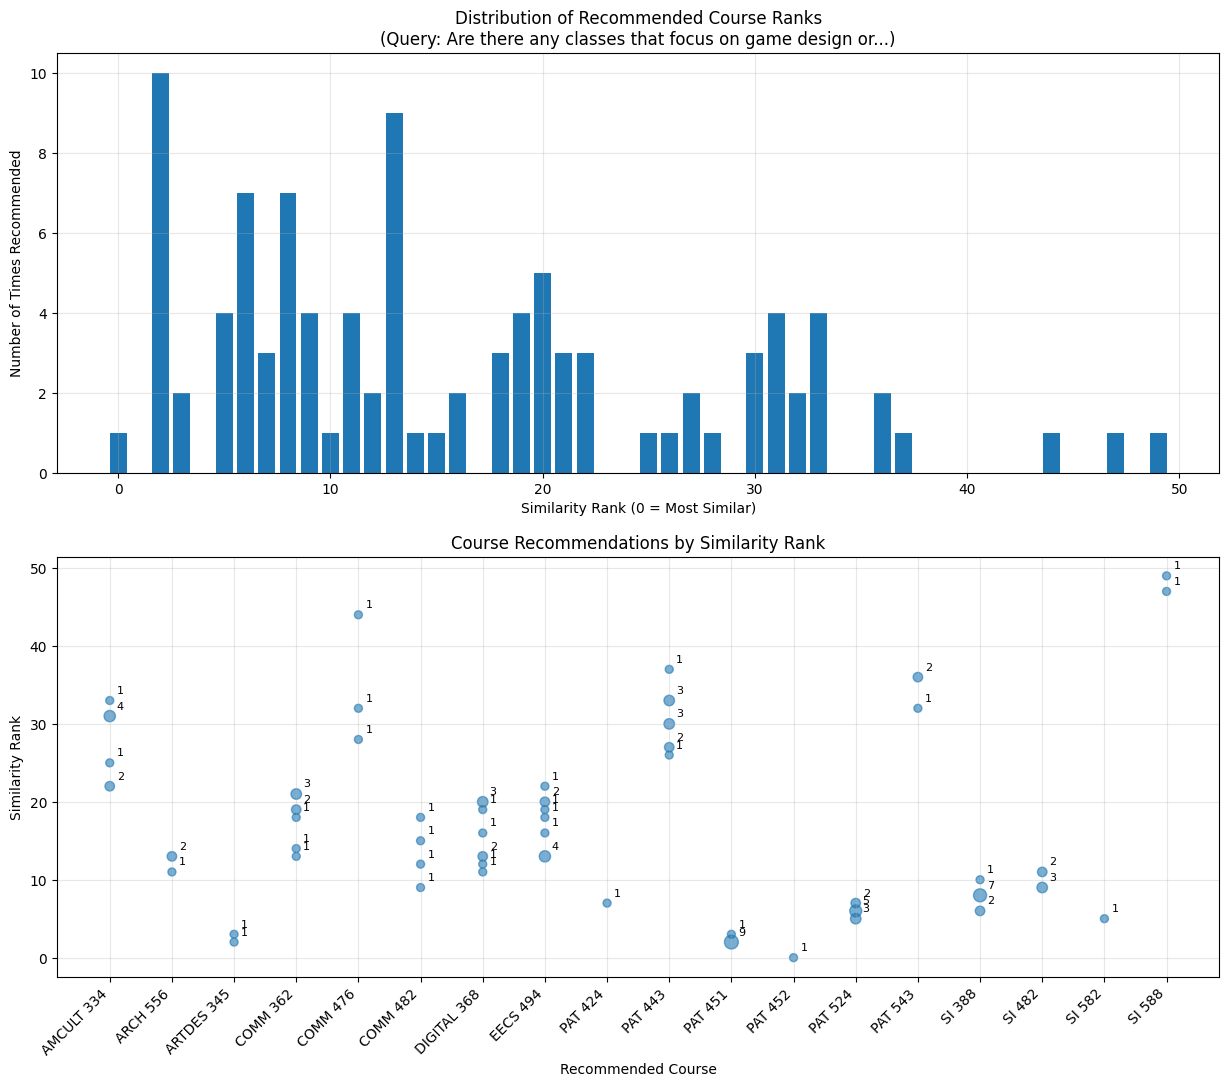

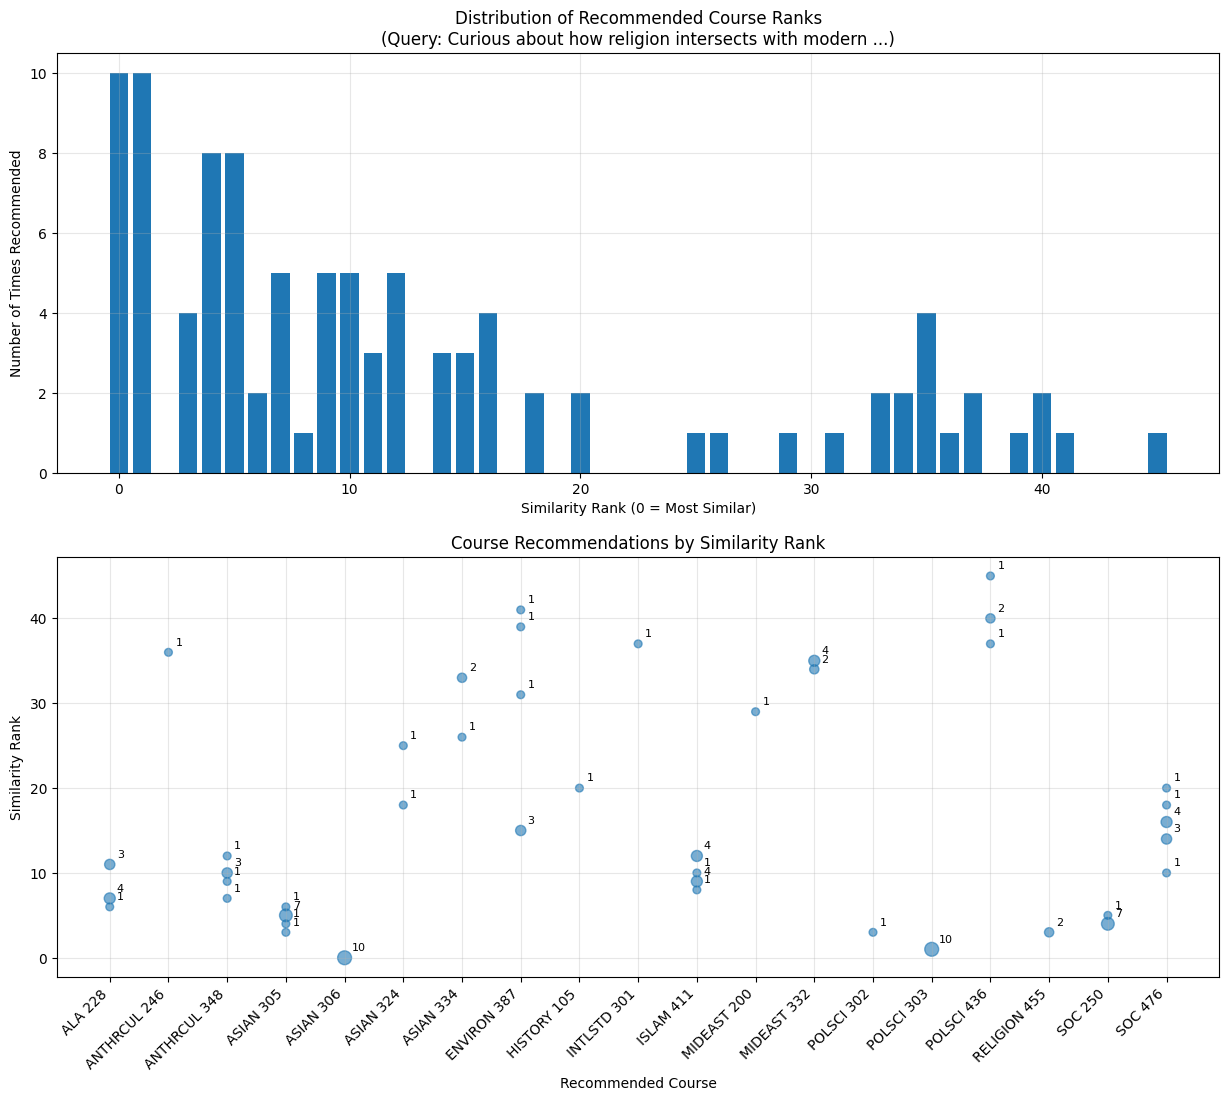

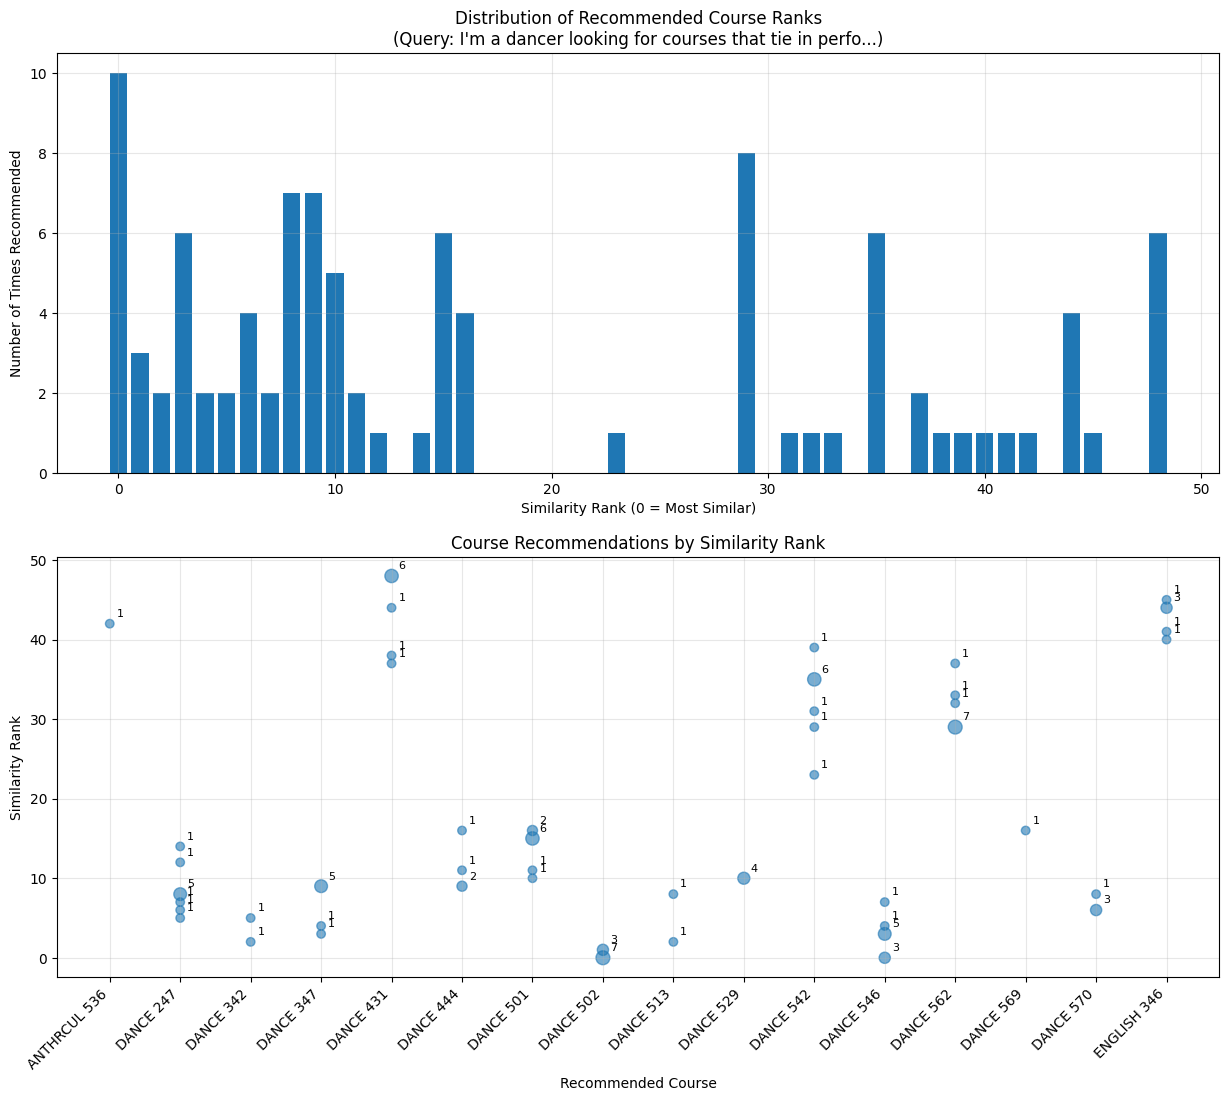

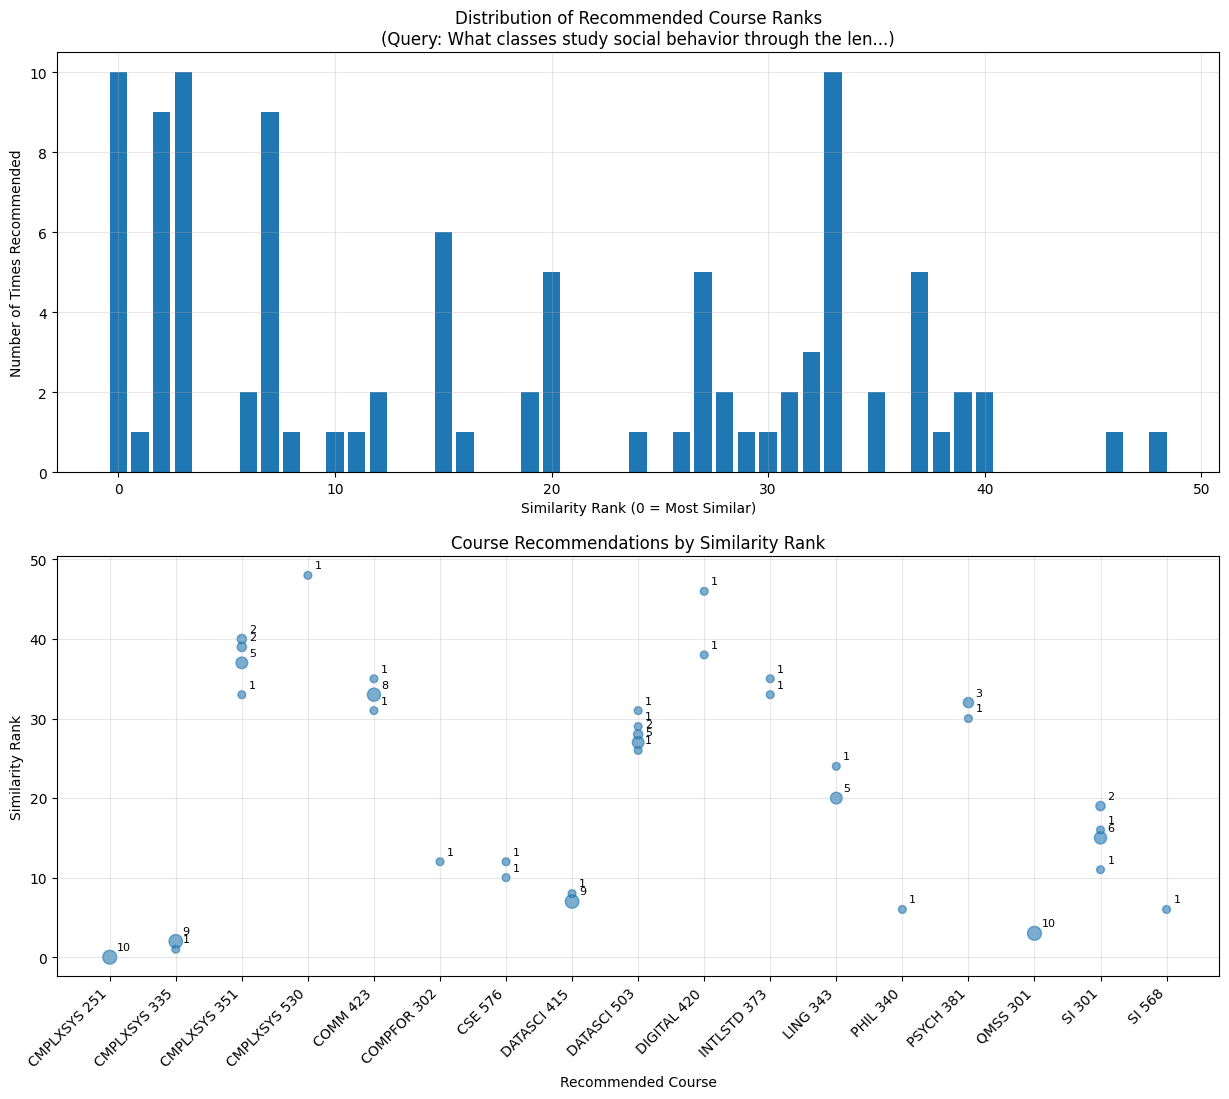

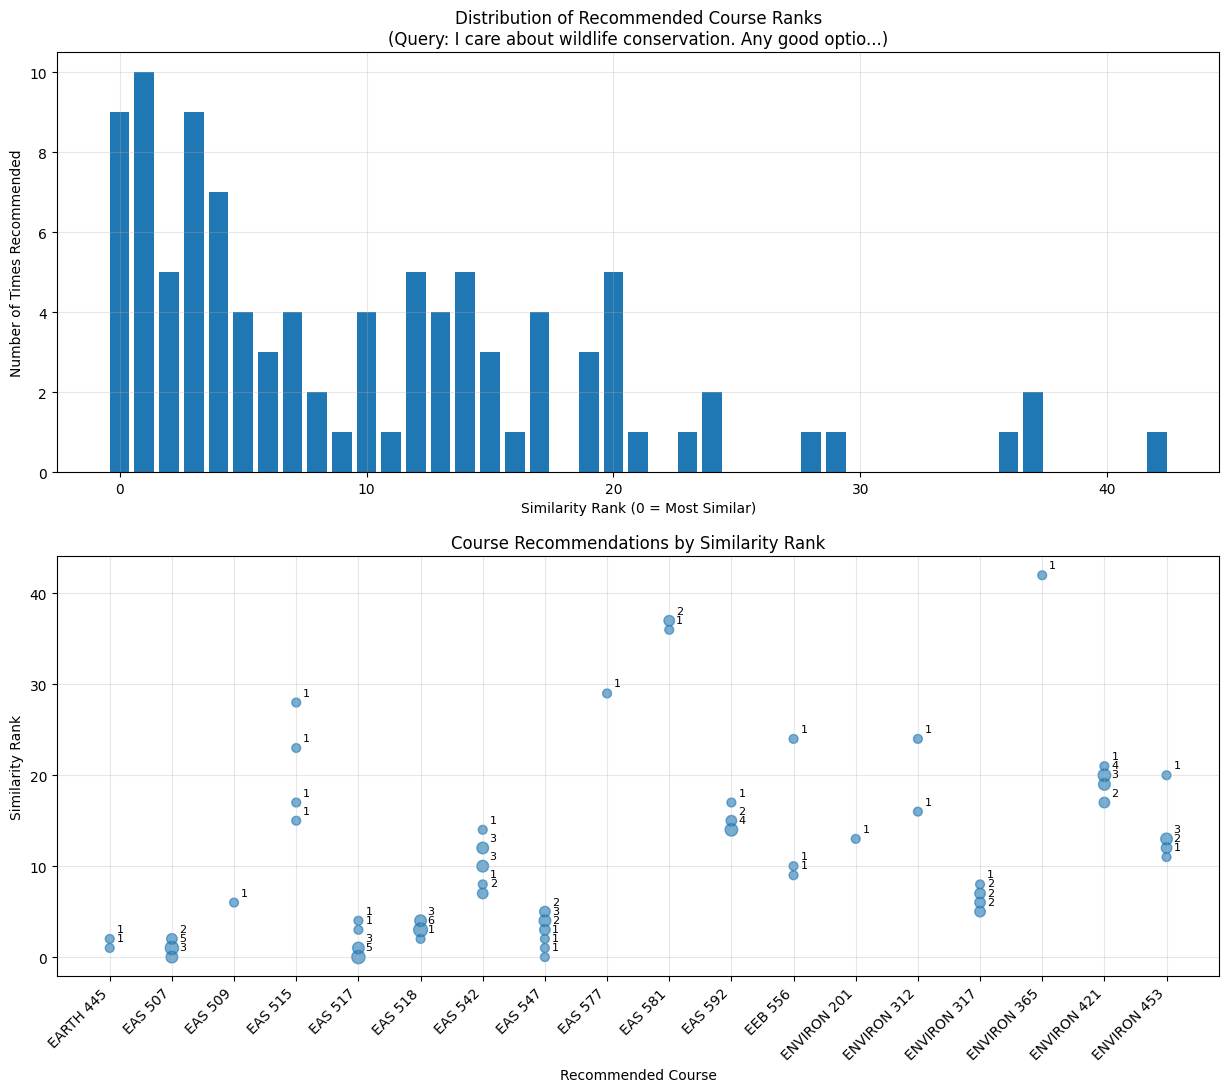

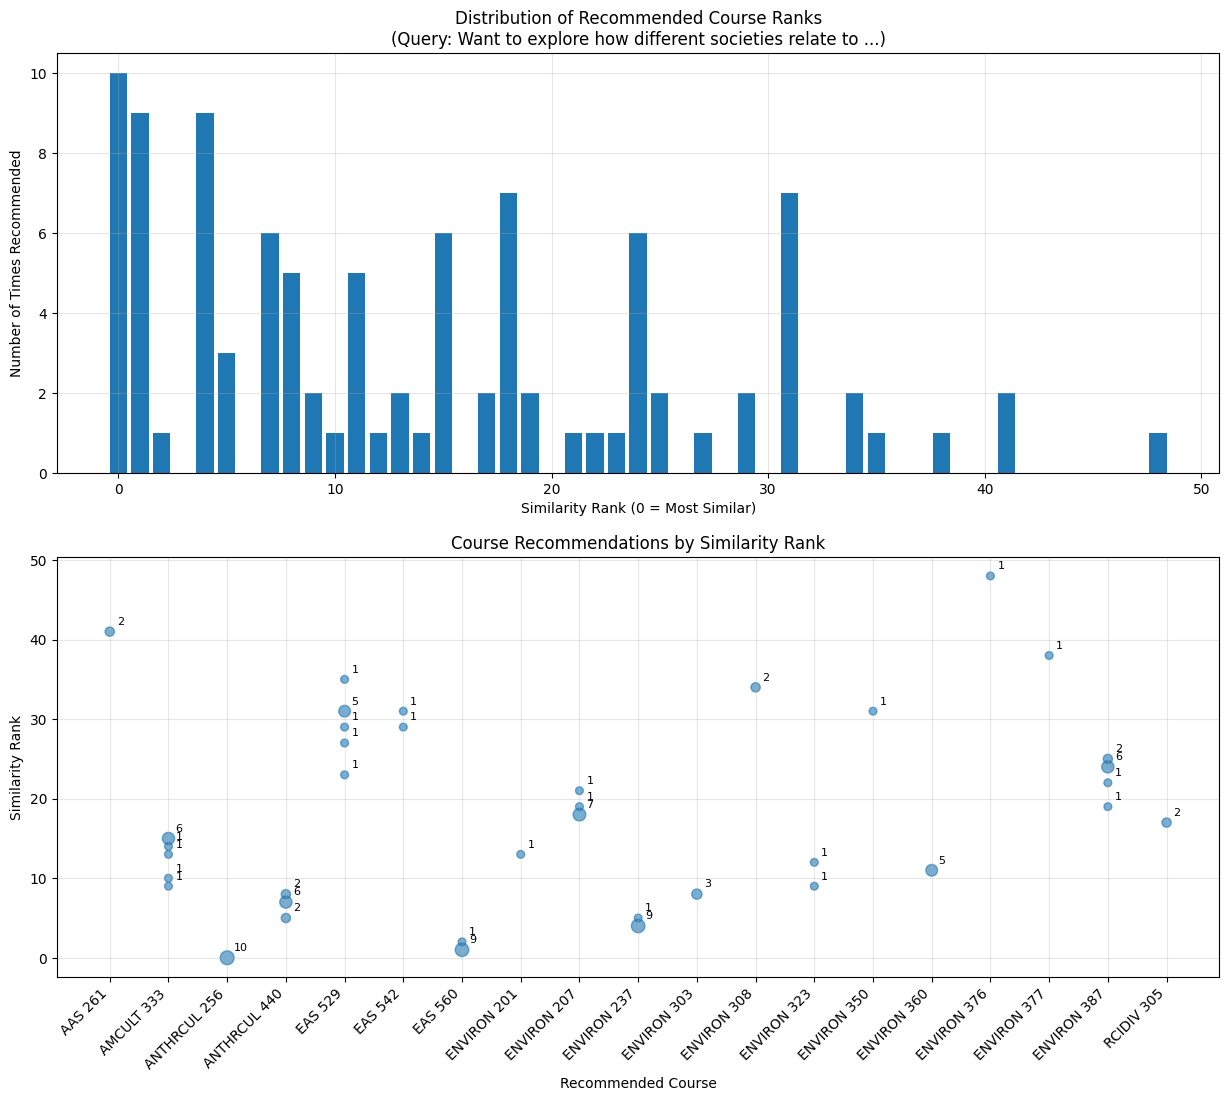

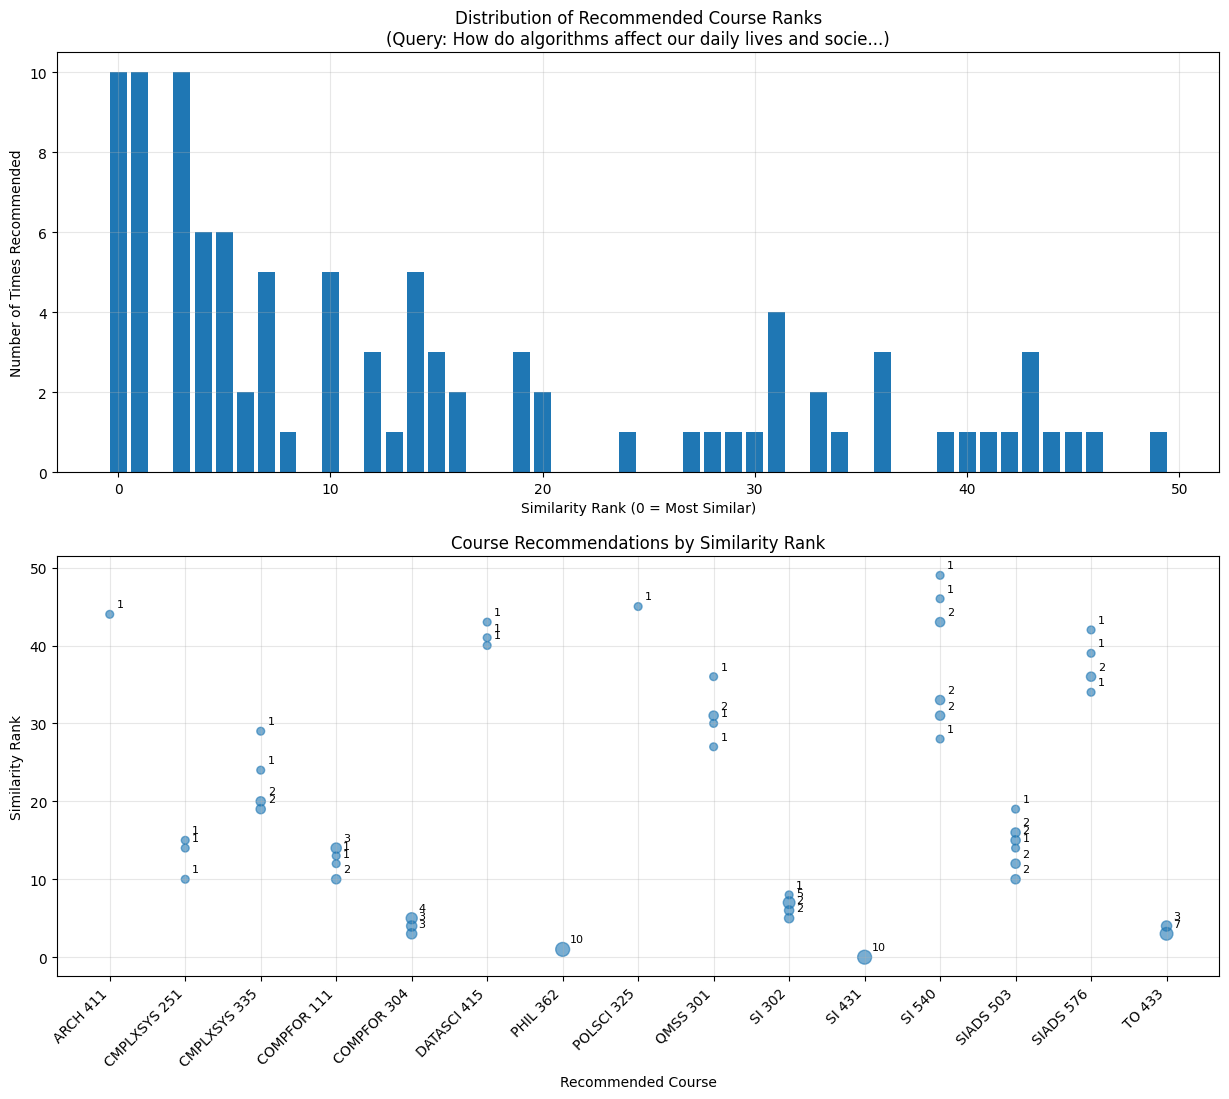

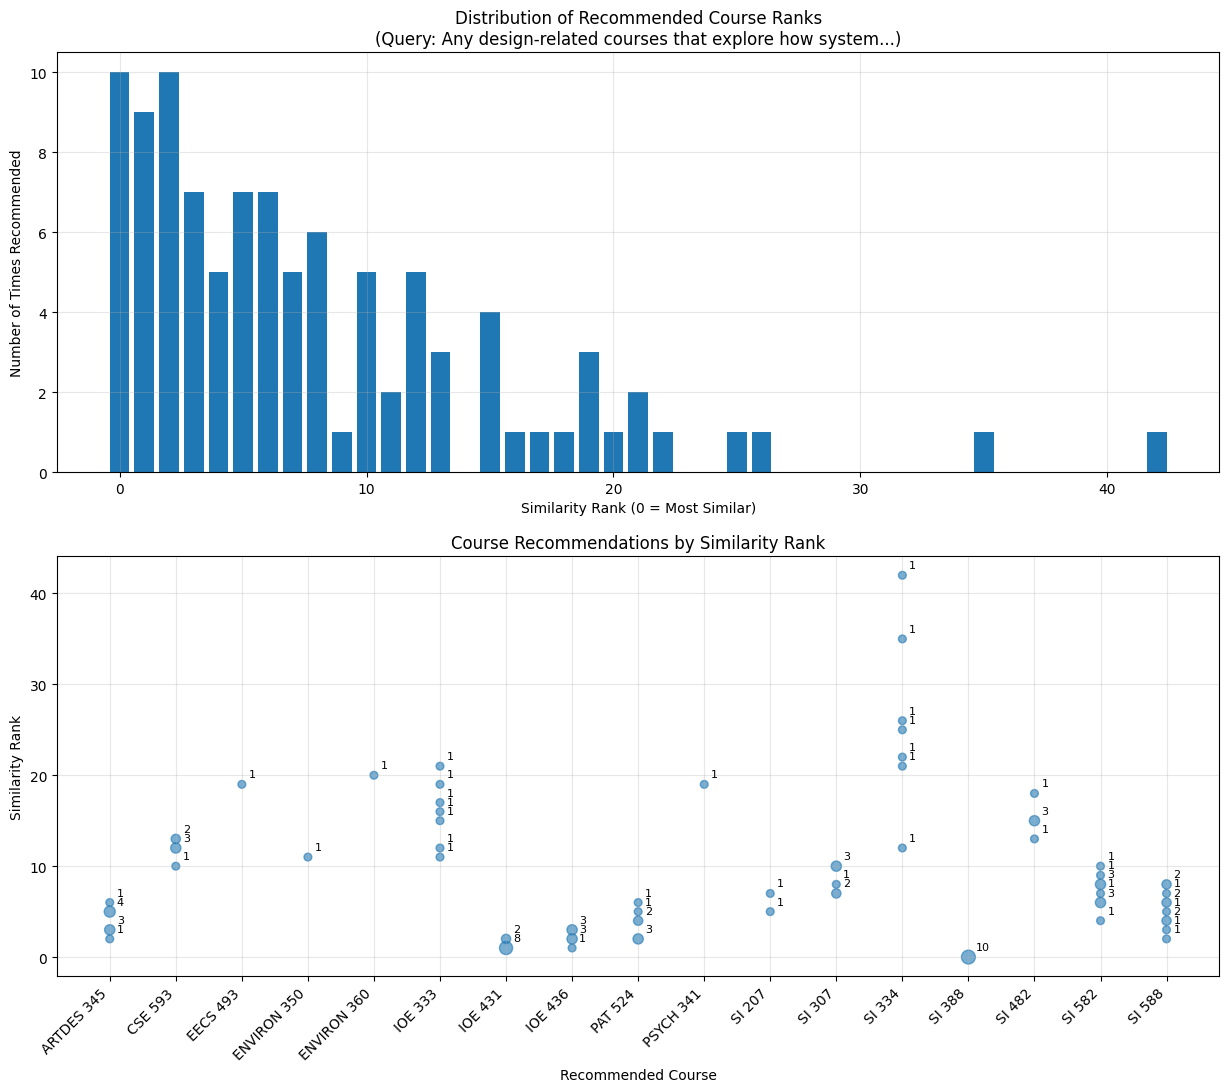

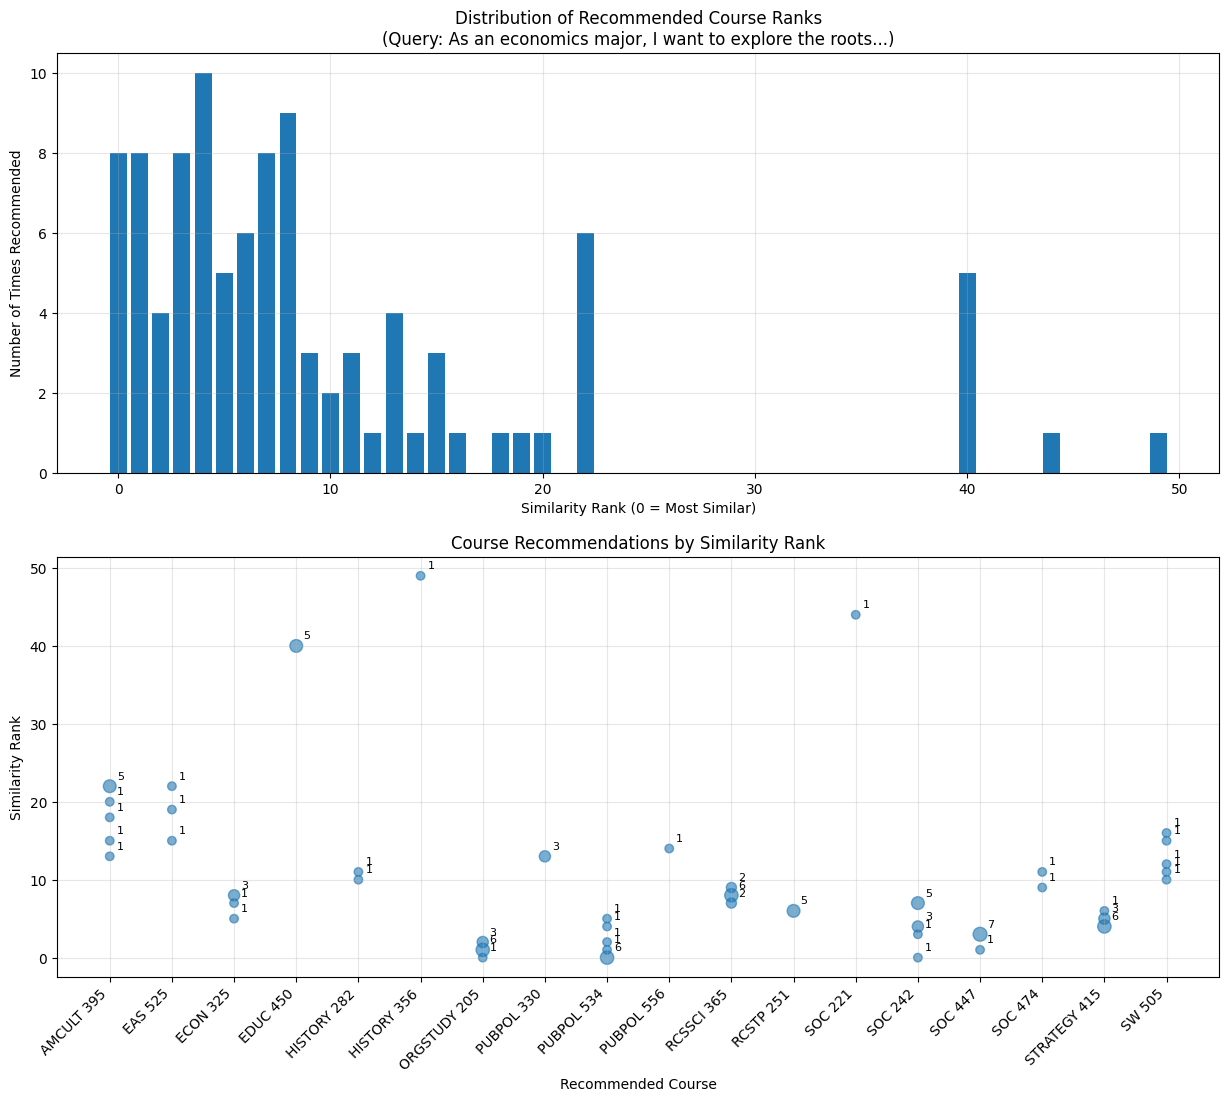

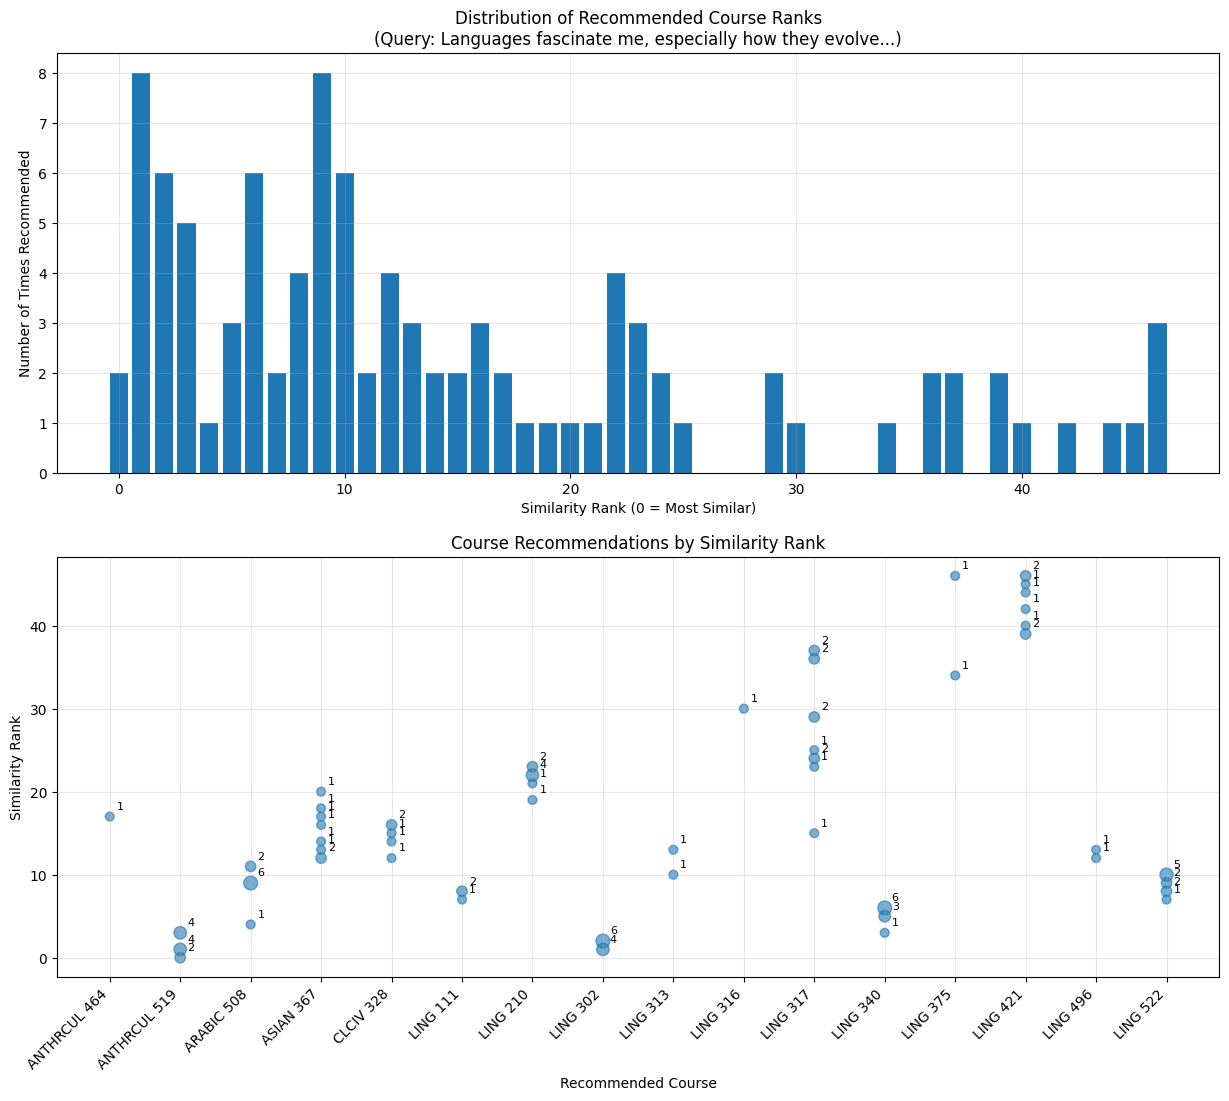

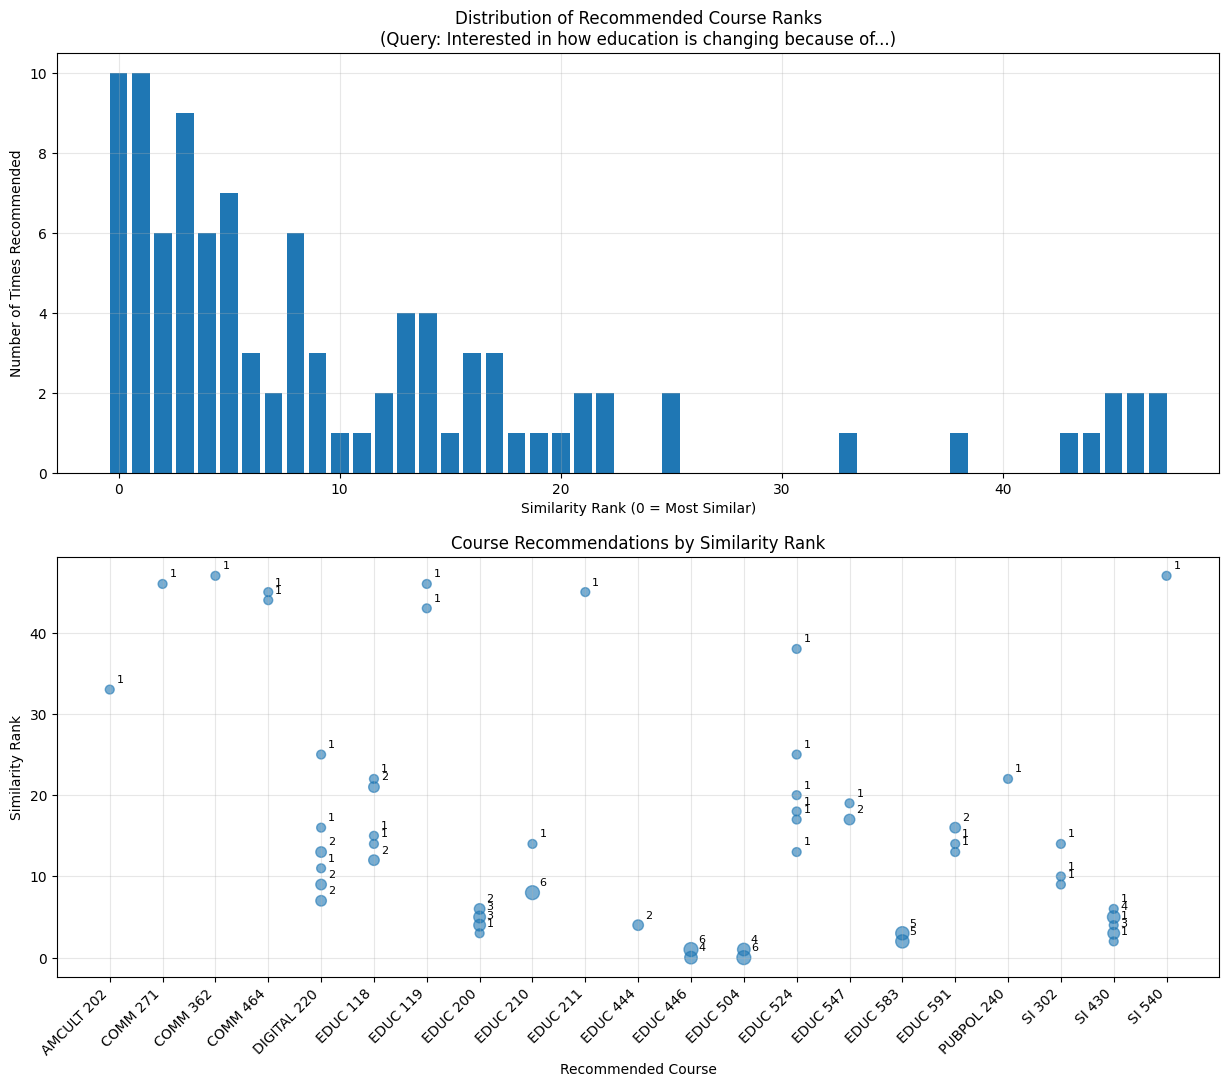

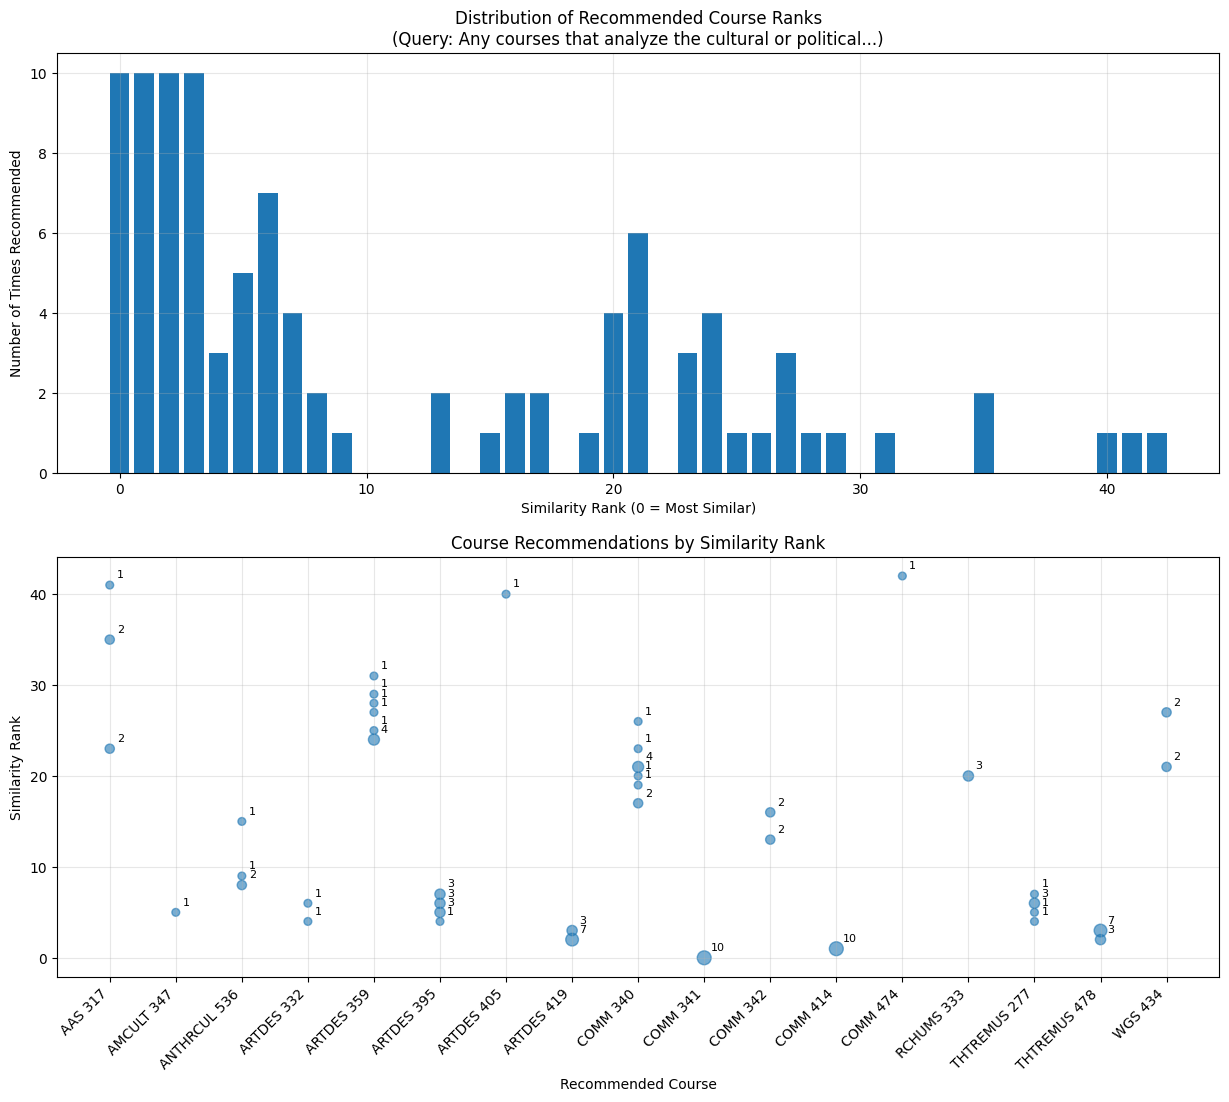

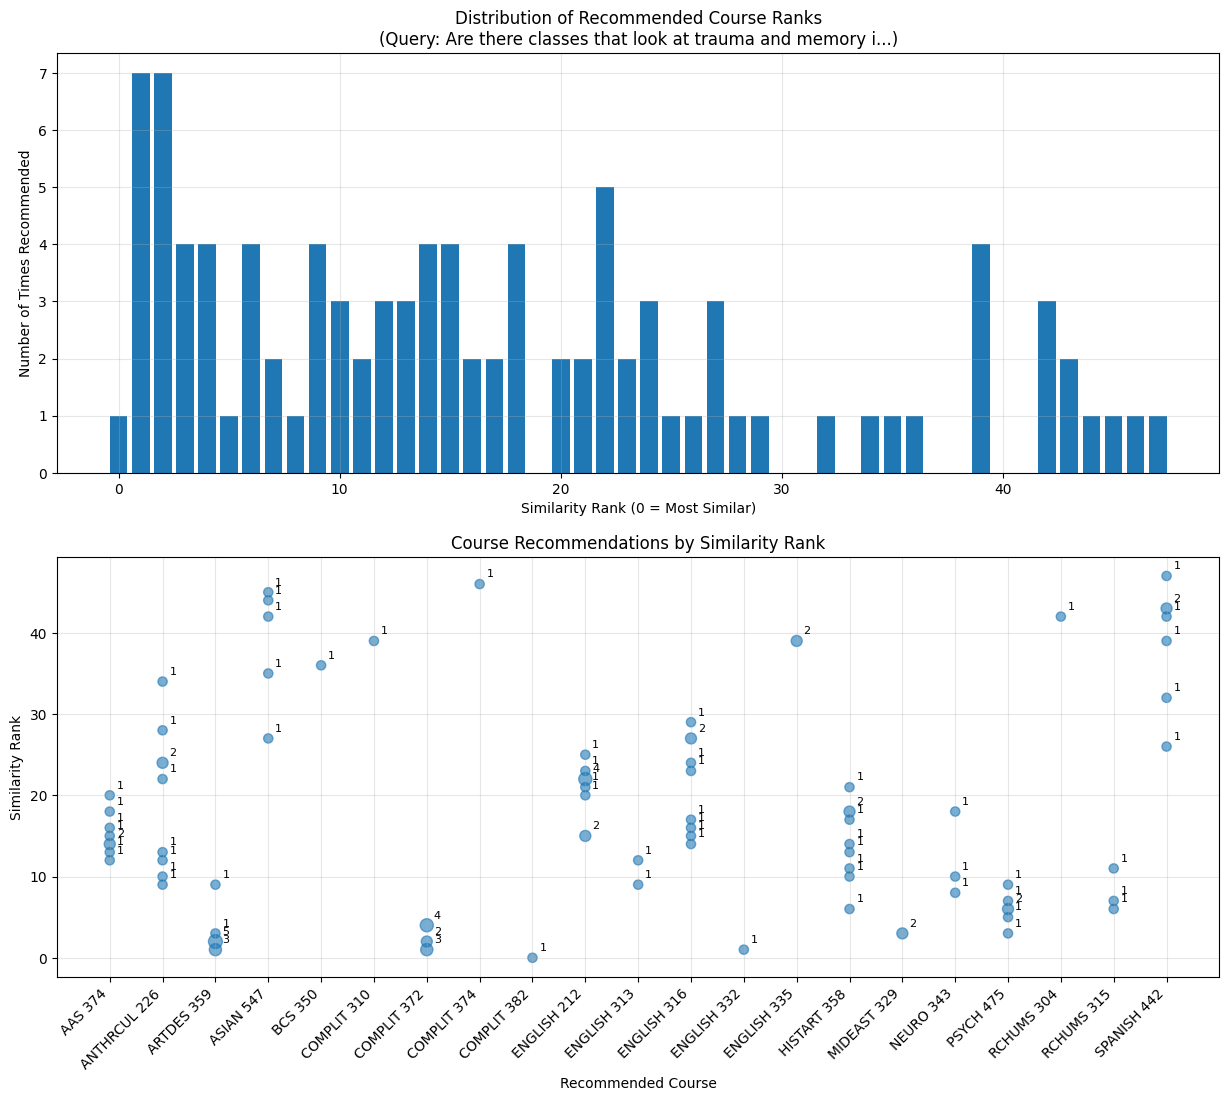

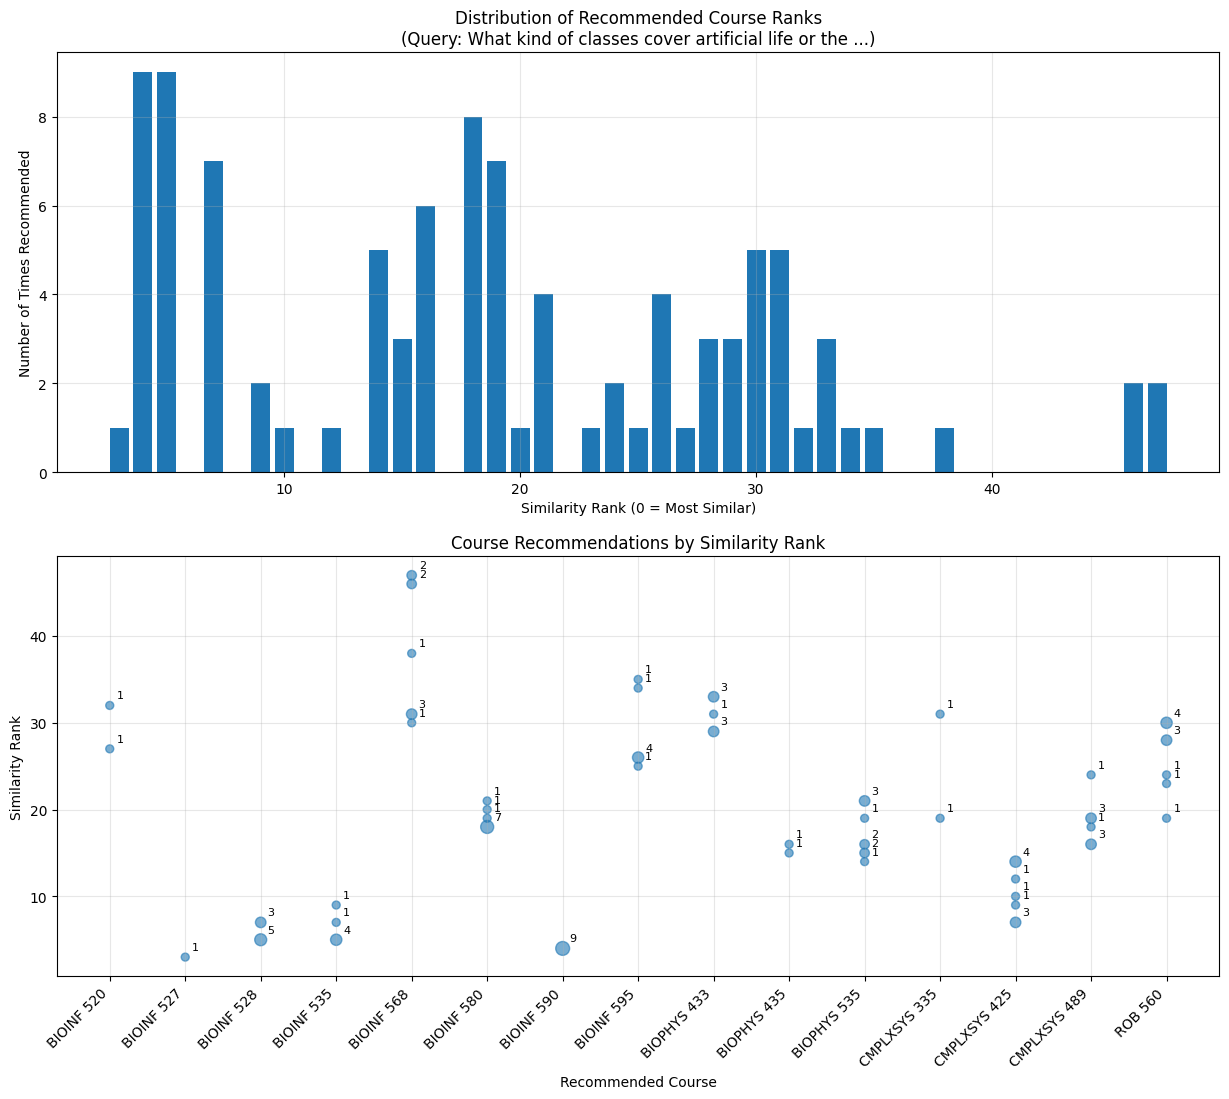

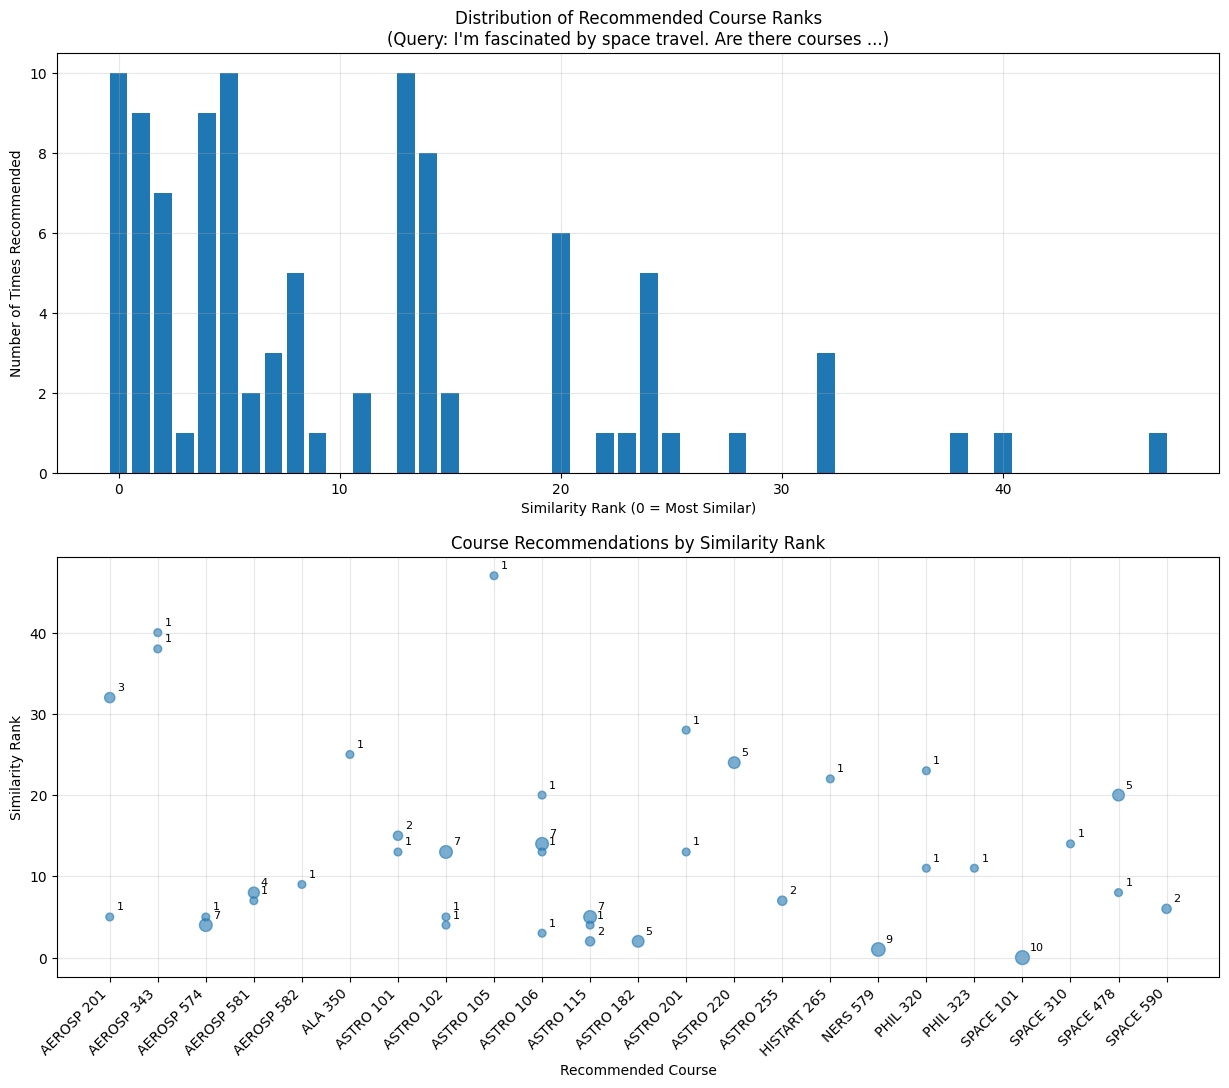

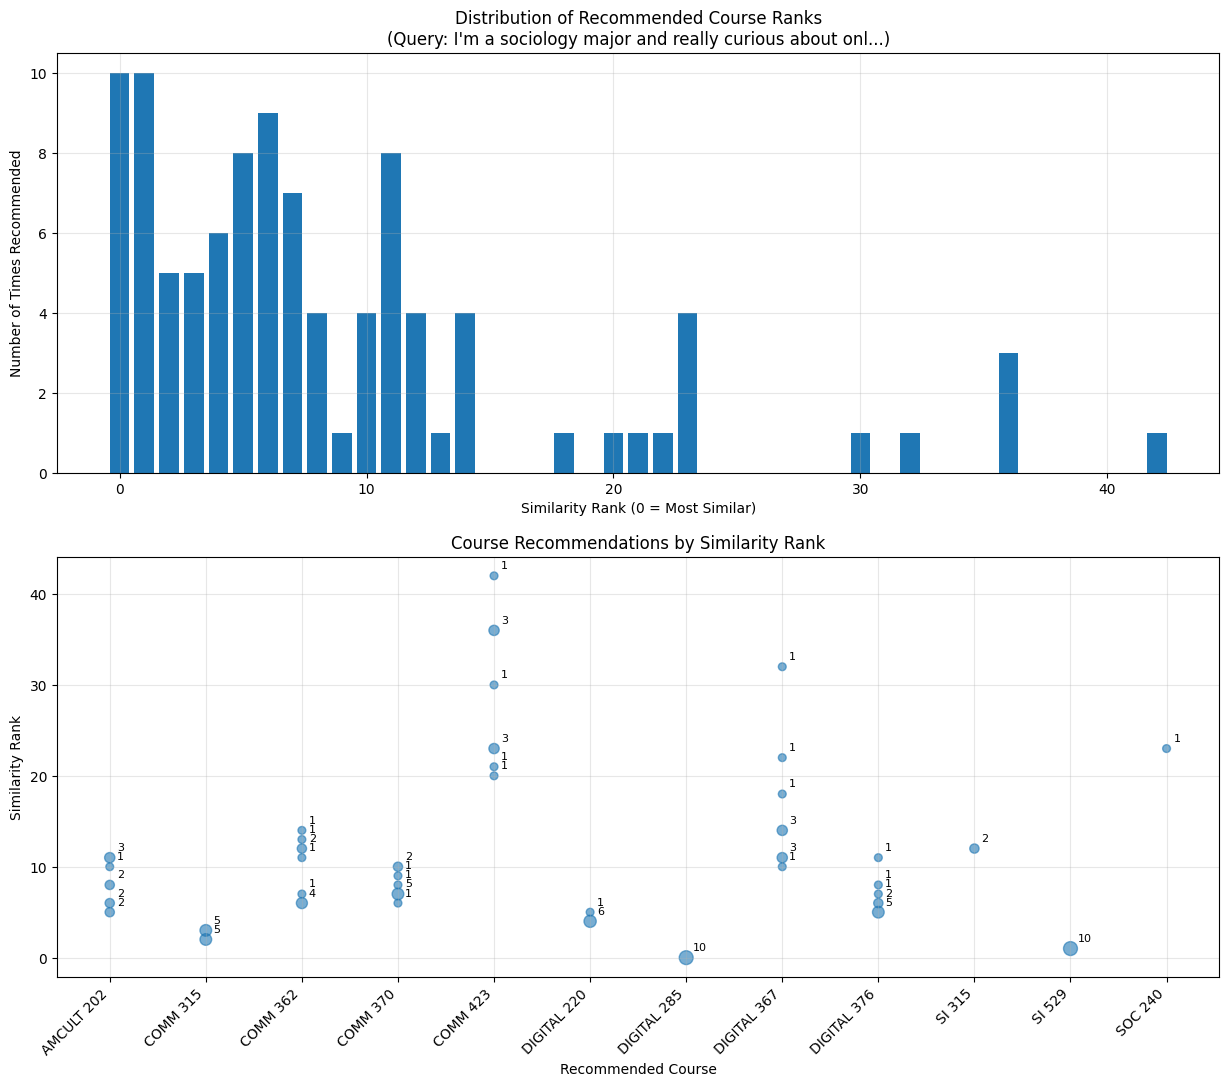

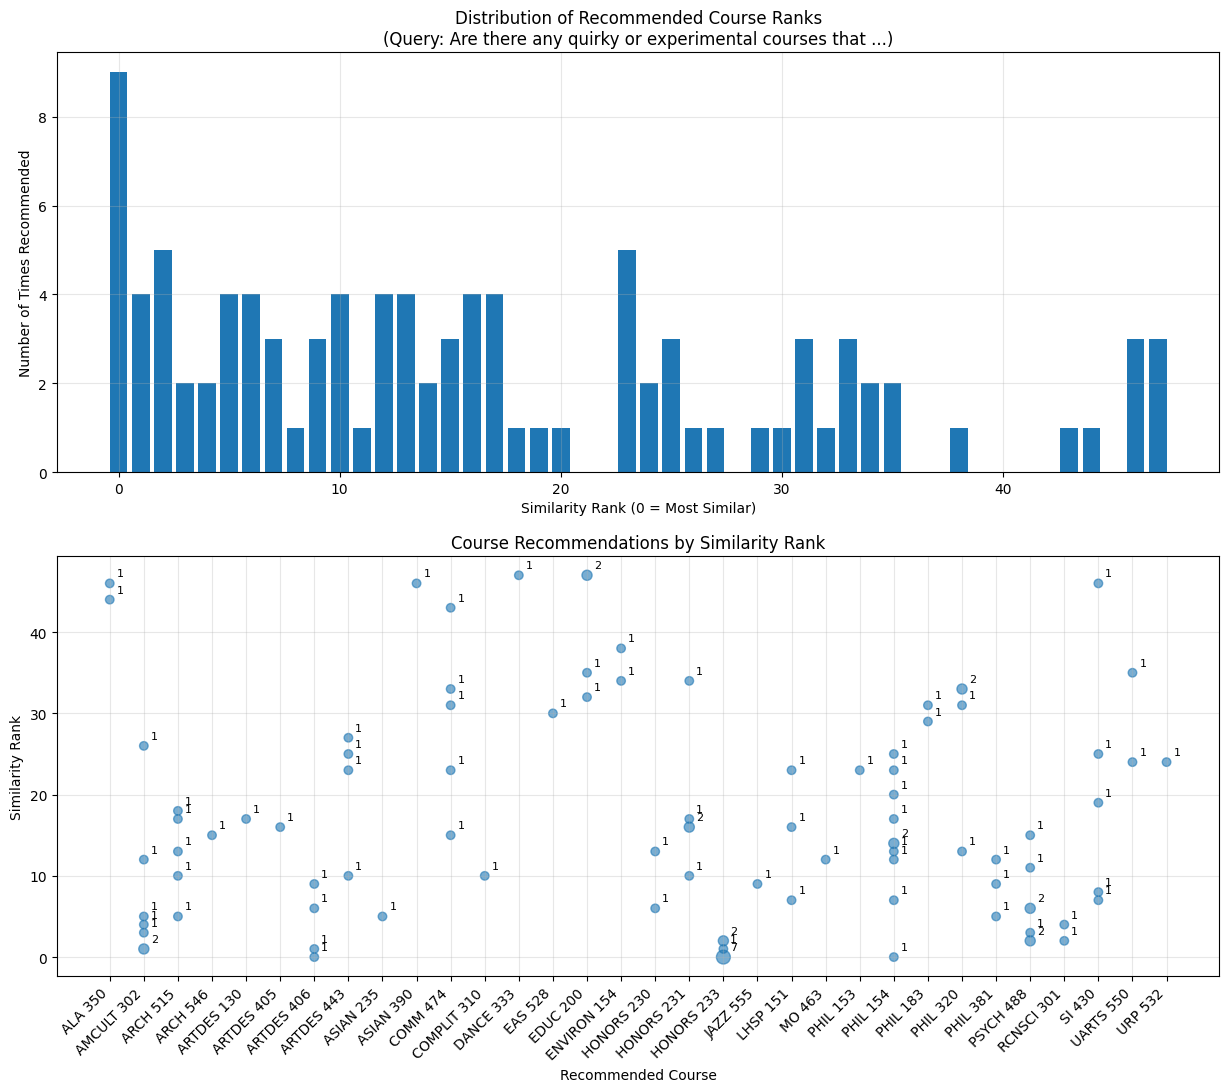

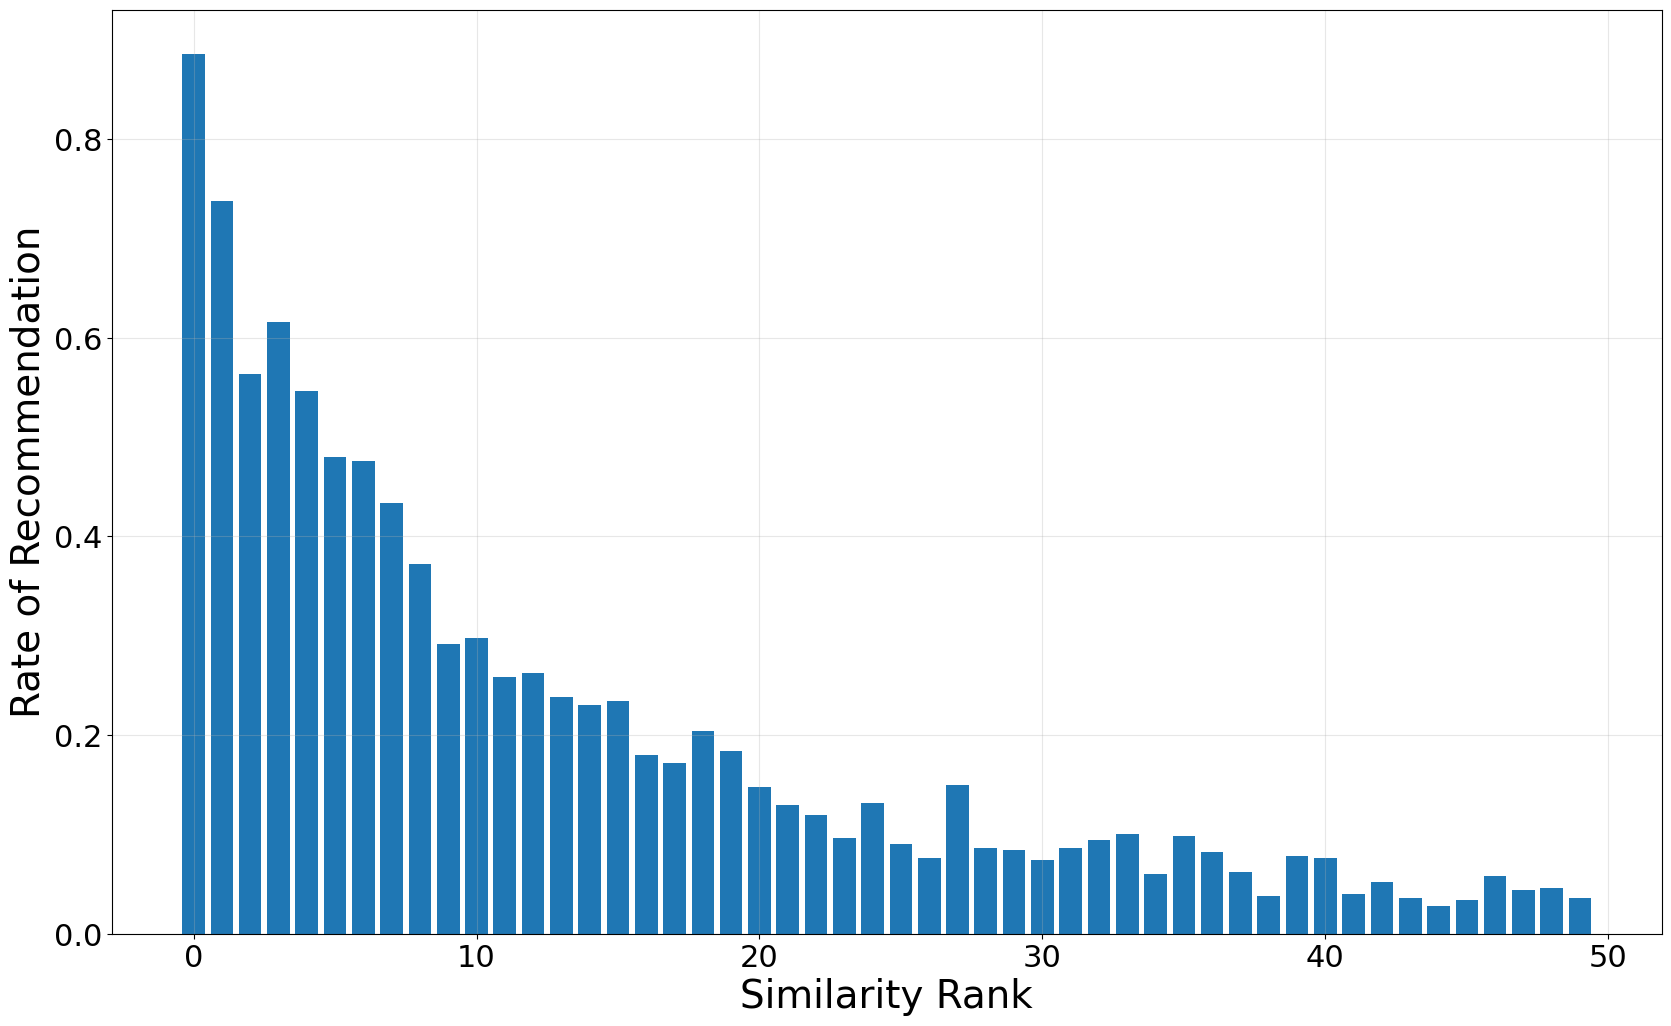

In [3]:
# Experiment settings
n_trials = 10
exp_name = 'rank_exp_final'

total_rank_counts = Counter()

for i in range(len(queries)):
    print(f'Running experiment for query {i+1}/{len(queries)}: {queries[i]}')
    results = await run_analysis(
        recommender=recModel,
        query=queries[i],
        n_trials=n_trials,
        levels=undergrad
    )
    results['figure'].savefig(f'figures/{exp_name}_{i}.png')
    total_rank_counts.update(results['rank_counts'])

# After all experiments, create final plot of total distribution
n_recs = n_trials*len(queries)
ranks = sorted(total_rank_counts.keys())
counts = [total_rank_counts[r]/n_recs for r in ranks]

# Plot Rank Distribution
plt.figure(figsize=(20,12))
plt.bar(ranks, counts)
plt.xlabel('Similarity Rank', fontsize=28)
plt.ylabel('Rate of Recommendation', fontsize=28)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.grid(True, alpha=0.3)
plt.savefig(f'figures/{exp_name}_combined.png')
plt.plot()

# Save Data
data = {'ranks': ranks, 'counts': counts}
with open(f'data/{exp_name}.pkl', 'wb') as f:
    pickle.dump(data, f)

# Semi Old

Running trial 1/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 2/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 3/10


...

INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 9/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 10/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


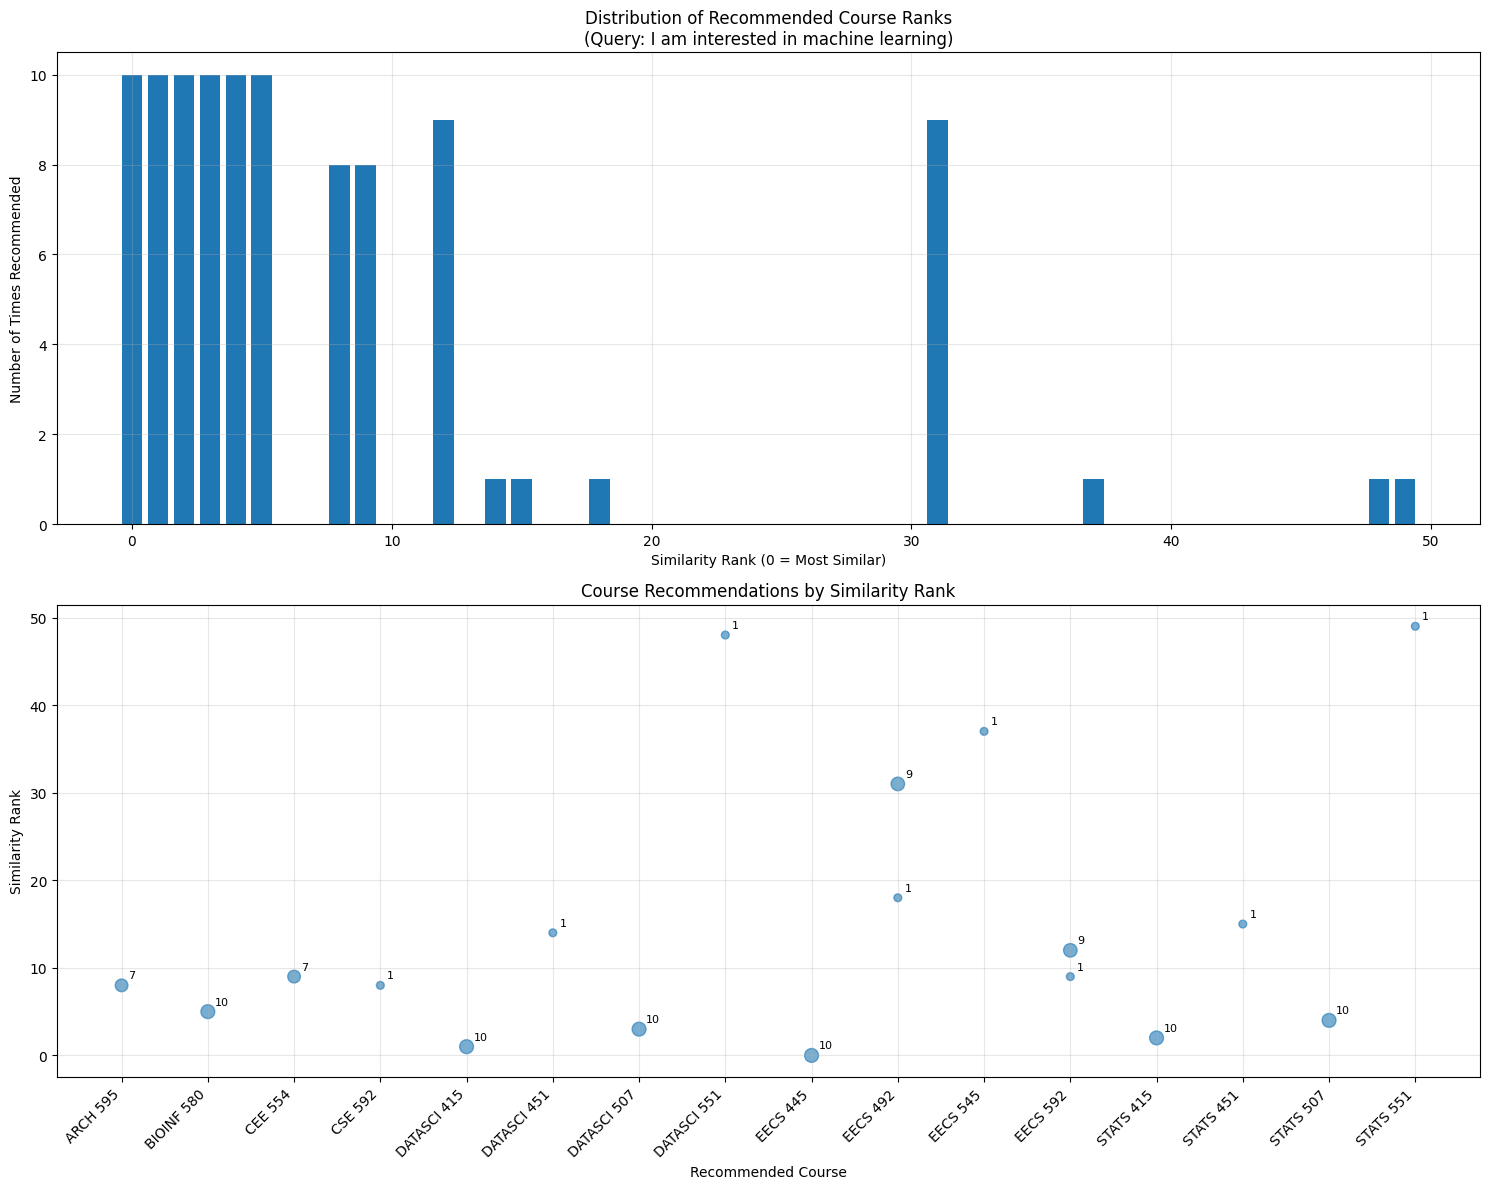


Summary Statistics:
Total recommendations: 100
Unique ranks recommended: 16
Most frequently recommended rank: 0
Average rank: 8.54
Running trial 1/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 2/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 3/10


...

INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 9/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 10/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


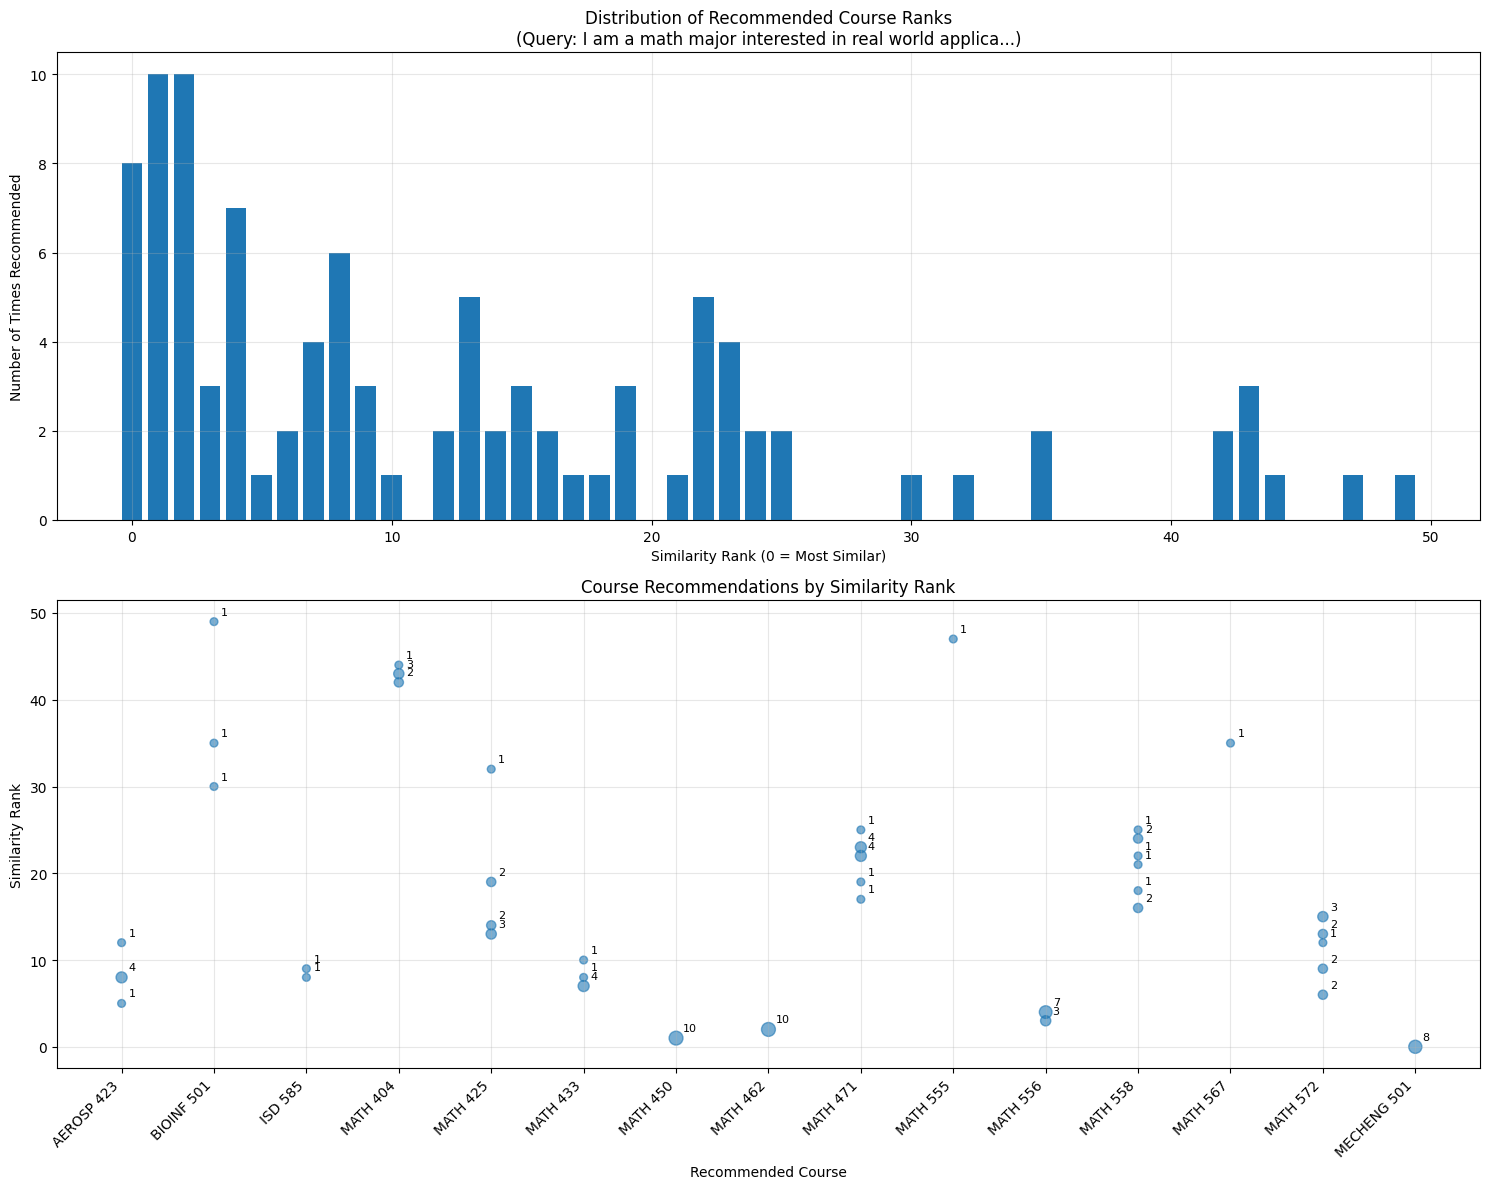


Summary Statistics:
Total recommendations: 100
Unique ranks recommended: 32
Most frequently recommended rank: 2
Average rank: 12.89
Running trial 1/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 2/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 3/10


...

INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 9/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 10/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


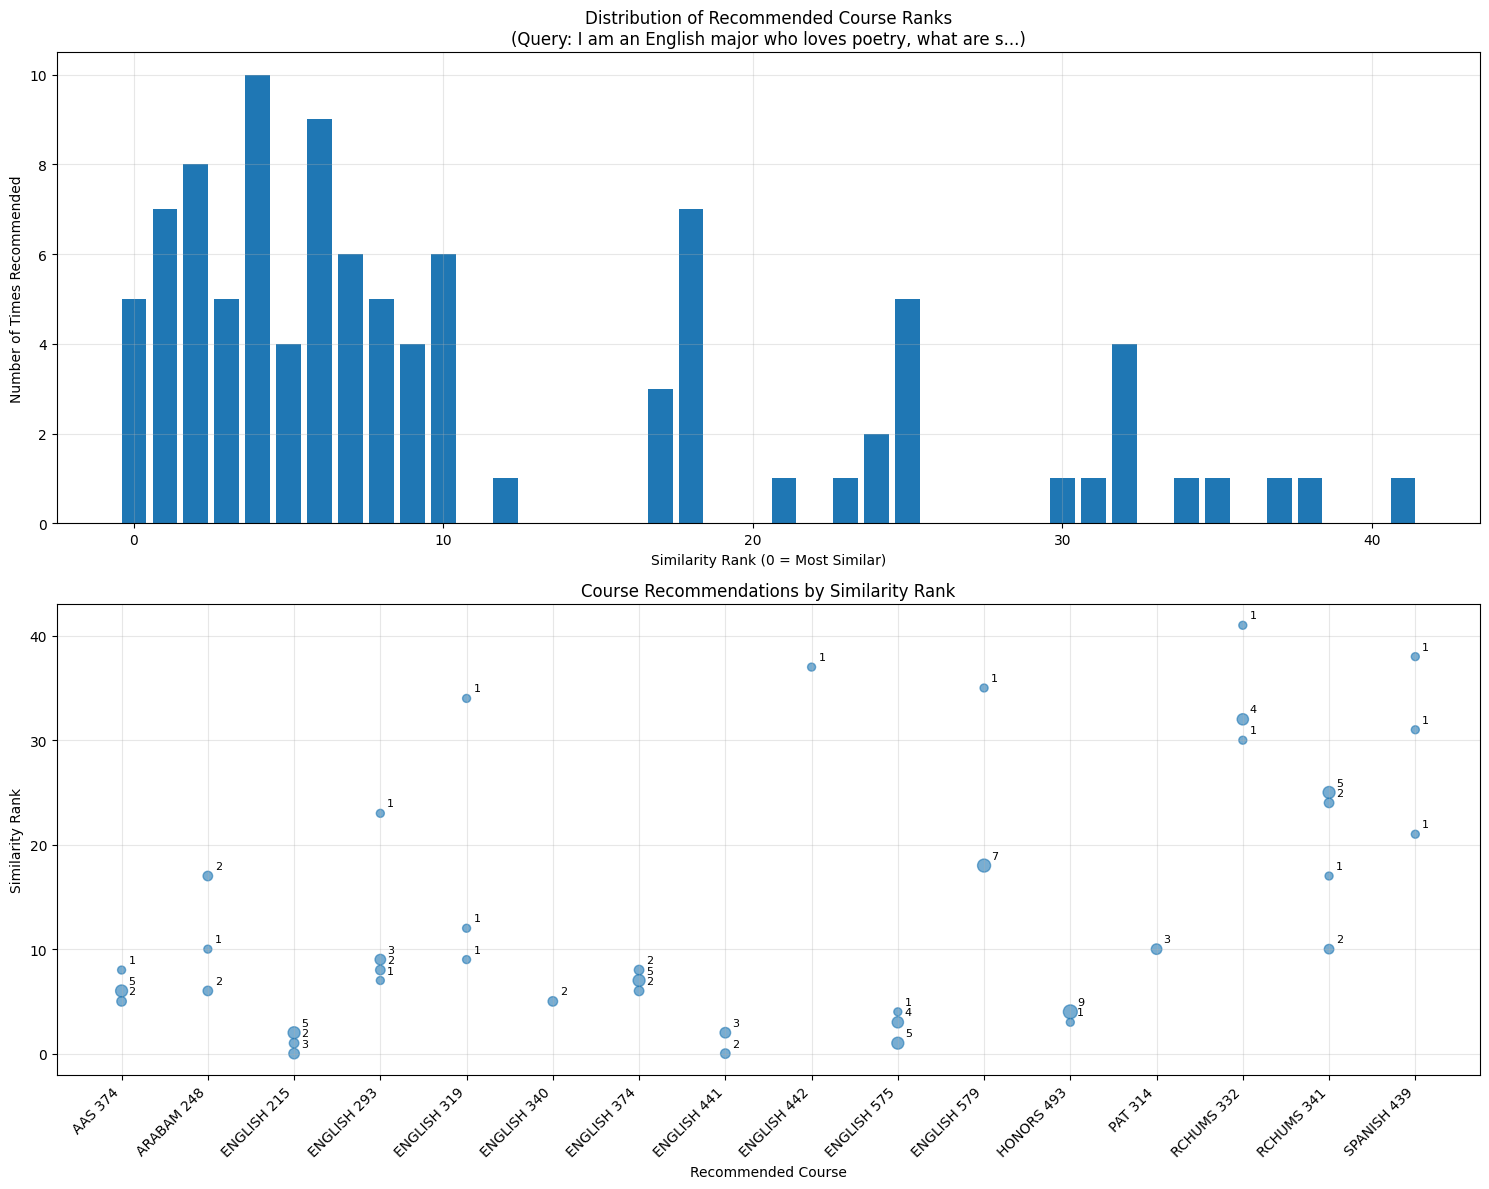


Summary Statistics:
Total recommendations: 100
Unique ranks recommended: 26
Most frequently recommended rank: 4
Average rank: 11.10
Running trial 1/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 2/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 3/10


...

INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 9/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 10/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


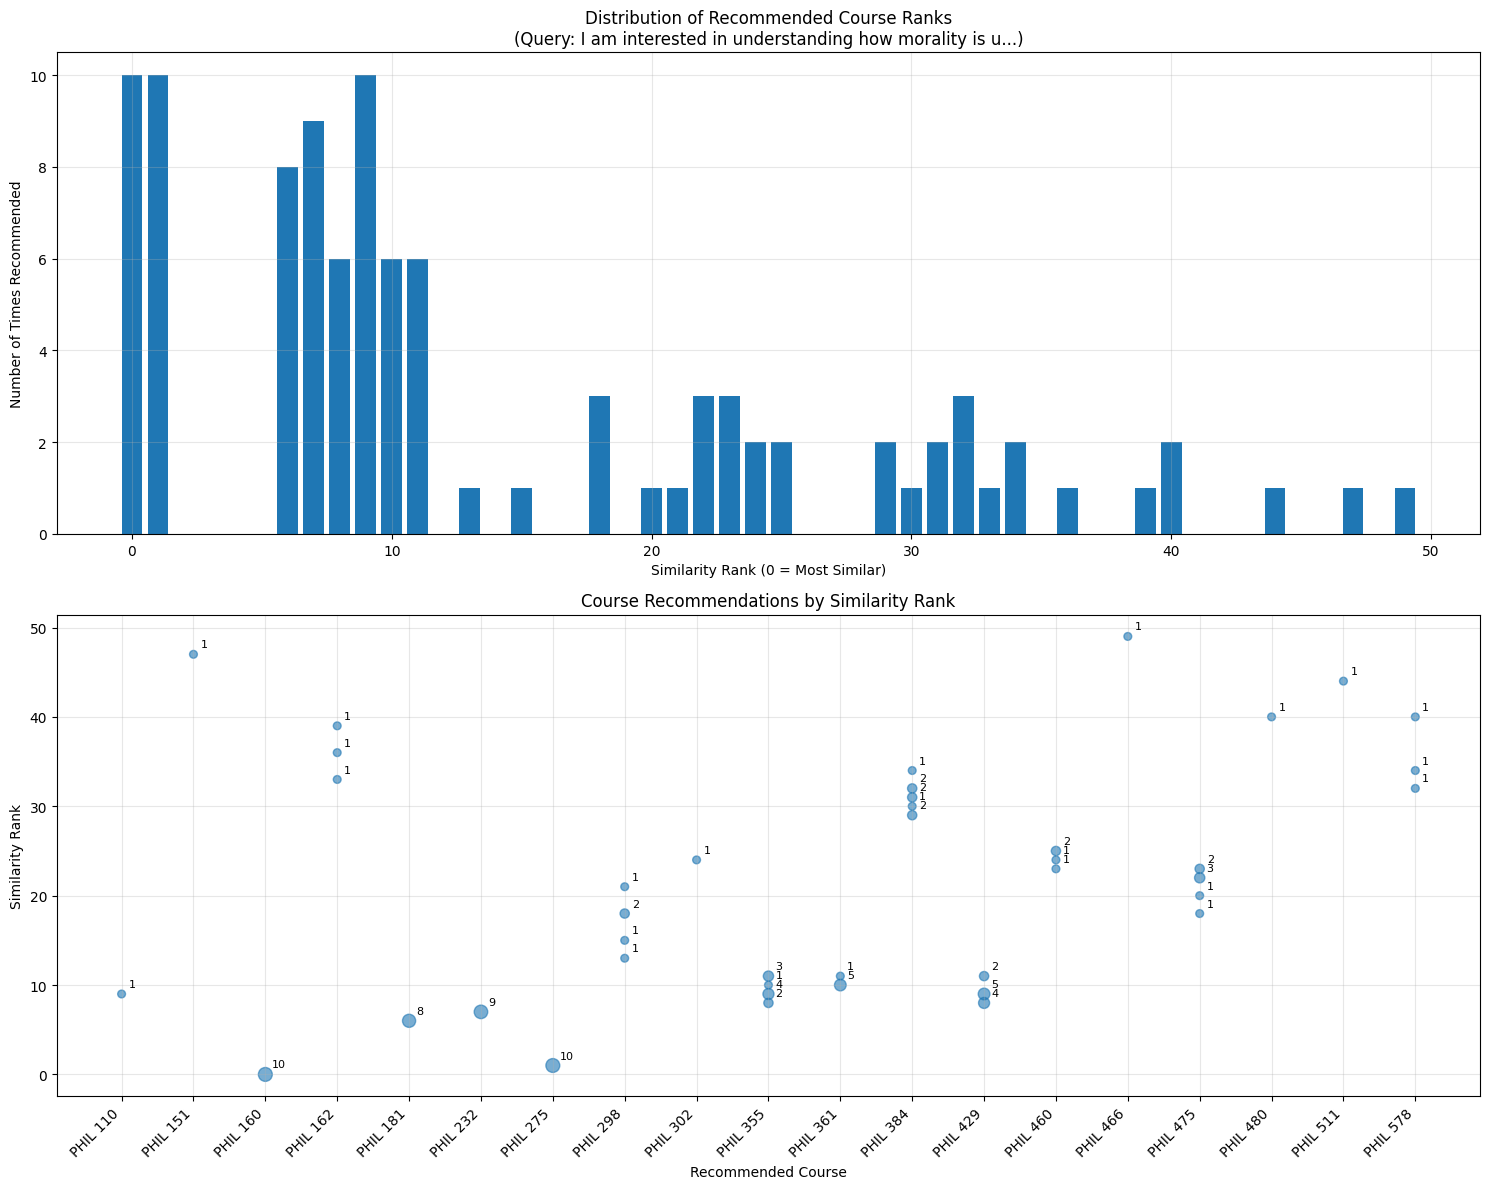


Summary Statistics:
Total recommendations: 100
Unique ranks recommended: 29
Most frequently recommended rank: 0
Average rank: 13.83
Running trial 1/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 2/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 3/10


...

INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 9/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 10/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


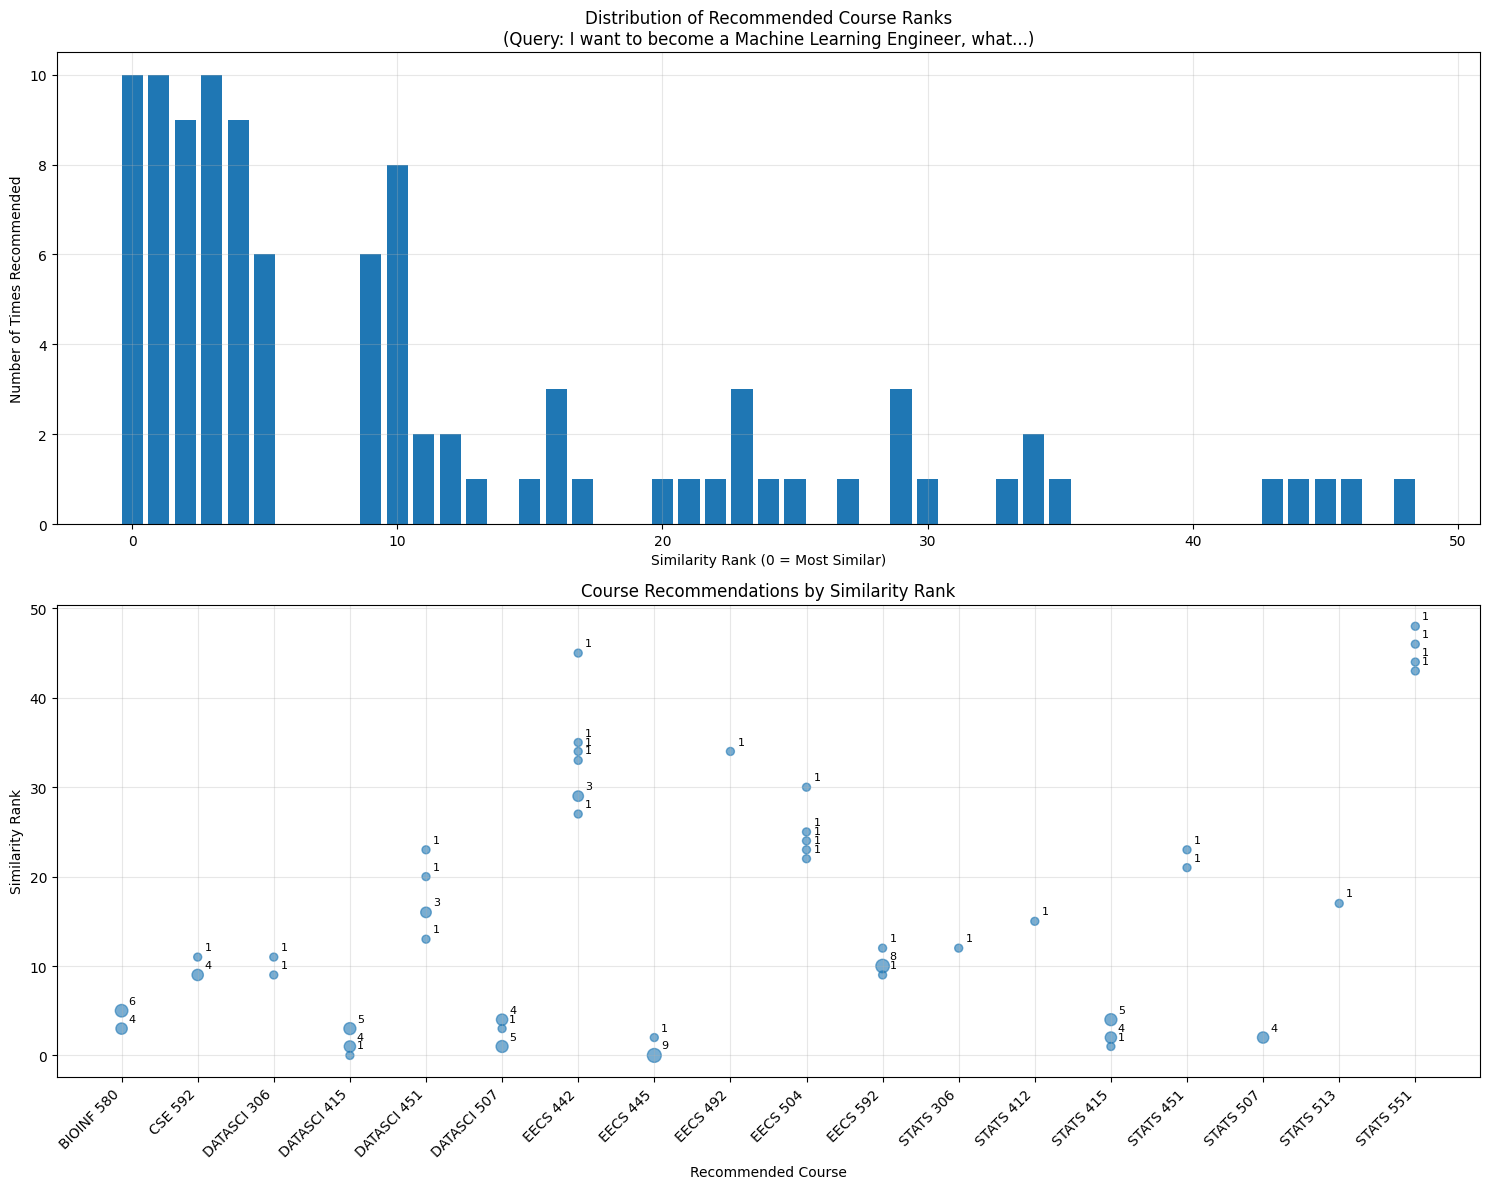


Summary Statistics:
Total recommendations: 100
Unique ranks recommended: 31
Most frequently recommended rank: 0
Average rank: 10.84
Running trial 1/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 2/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 3/10


...

INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 9/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 10/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


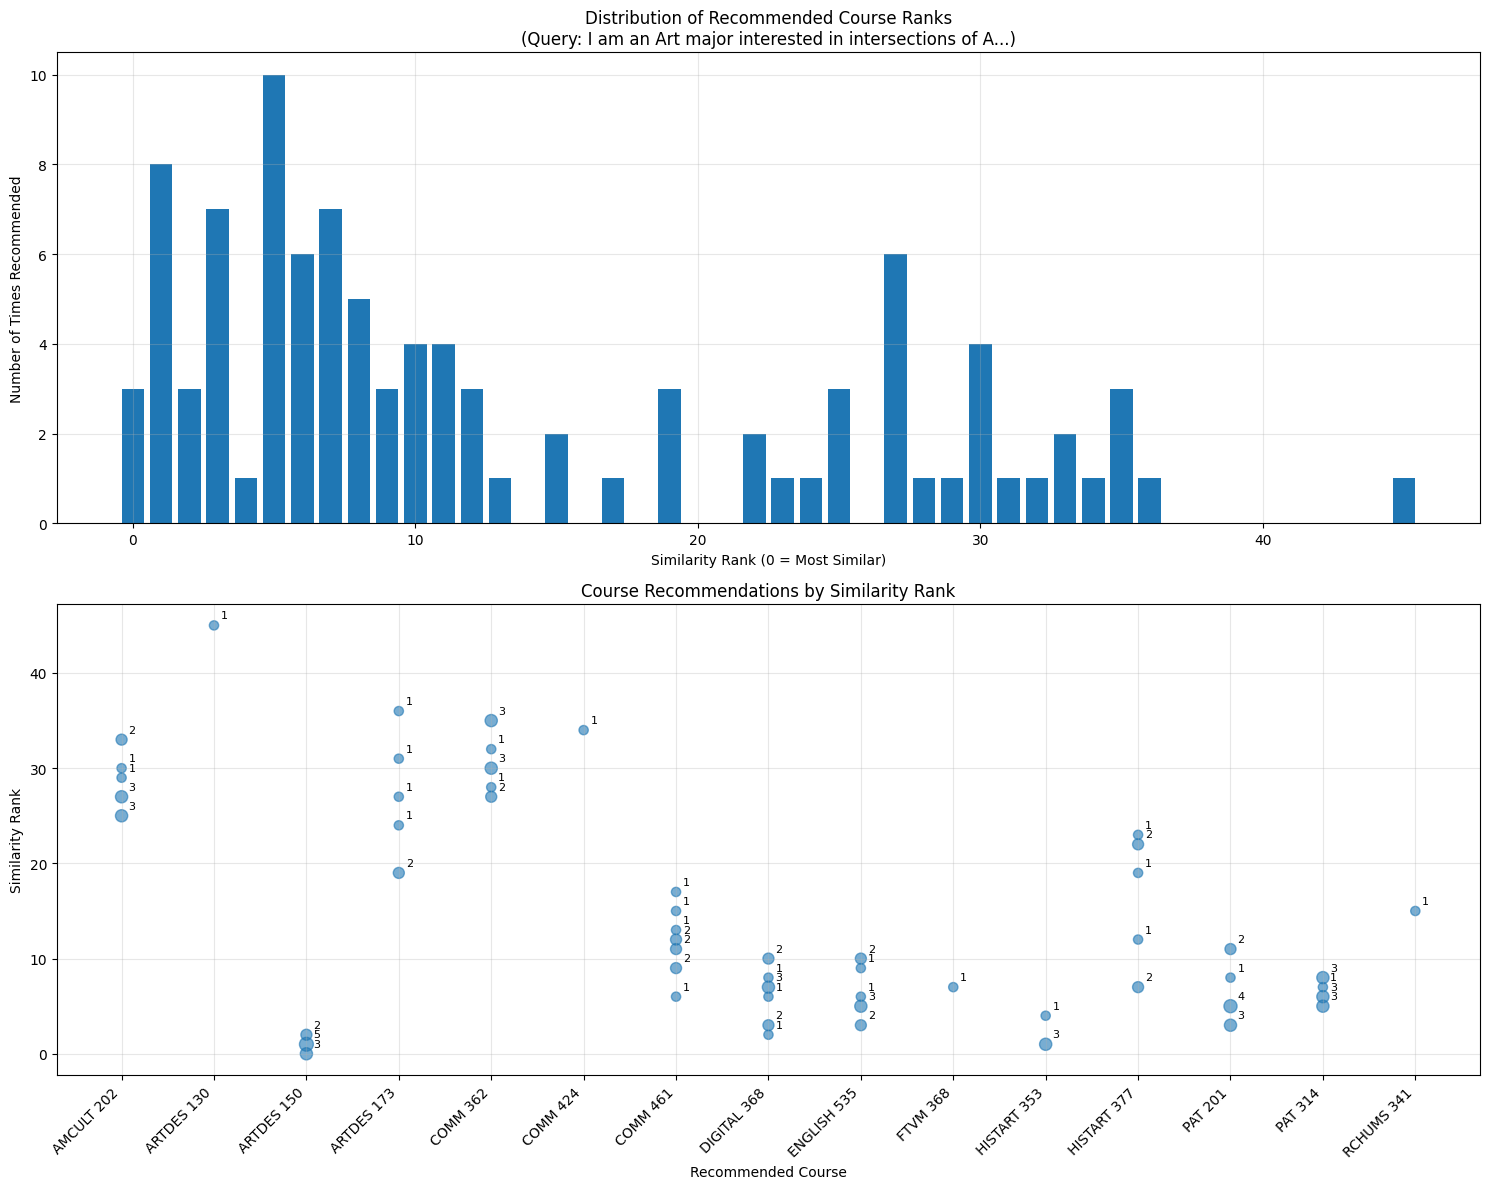


Summary Statistics:
Total recommendations: 100
Unique ranks recommended: 32
Most frequently recommended rank: 5
Average rank: 13.32


In [3]:
queries = [
    "I am interested in machine learning",
    "I am a math major interested in real world applications of interesting math concepts. What are some more applied courses I could take?",
    "I am an English major who loves poetry, what are some classes I could take to learn about activism through poetry?",
    "I am interested in understanding how morality is understood and evolves.",
    "I want to become a Machine Learning Engineer, what are some important courses to take?",
    "I am an Art major interested in intersections of Art and Technology, what are some courses that may interest me?"
]

for i in range(len(queries)):
    results = await run_analysis(
        recommender=recModel,
        query=queries[i],
        n_trials=10,
        levels=undergrad
    )
    results['figure'].savefig(f'figures/rank_exp_{i}.png')
    plt.close(results['figure'])


Running trial 1/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 2/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 3/10


...

INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 9/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


Running trial 10/10


INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-35-turbo/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/text-embedding-ada-002/embeddings?api-version=2024-02-01 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.umgpt.umich.edu/azure-openai-api/openai/deployments/gpt-4o/chat/completions?api-version=2024-02-01 "HTTP/1.1 200 OK"


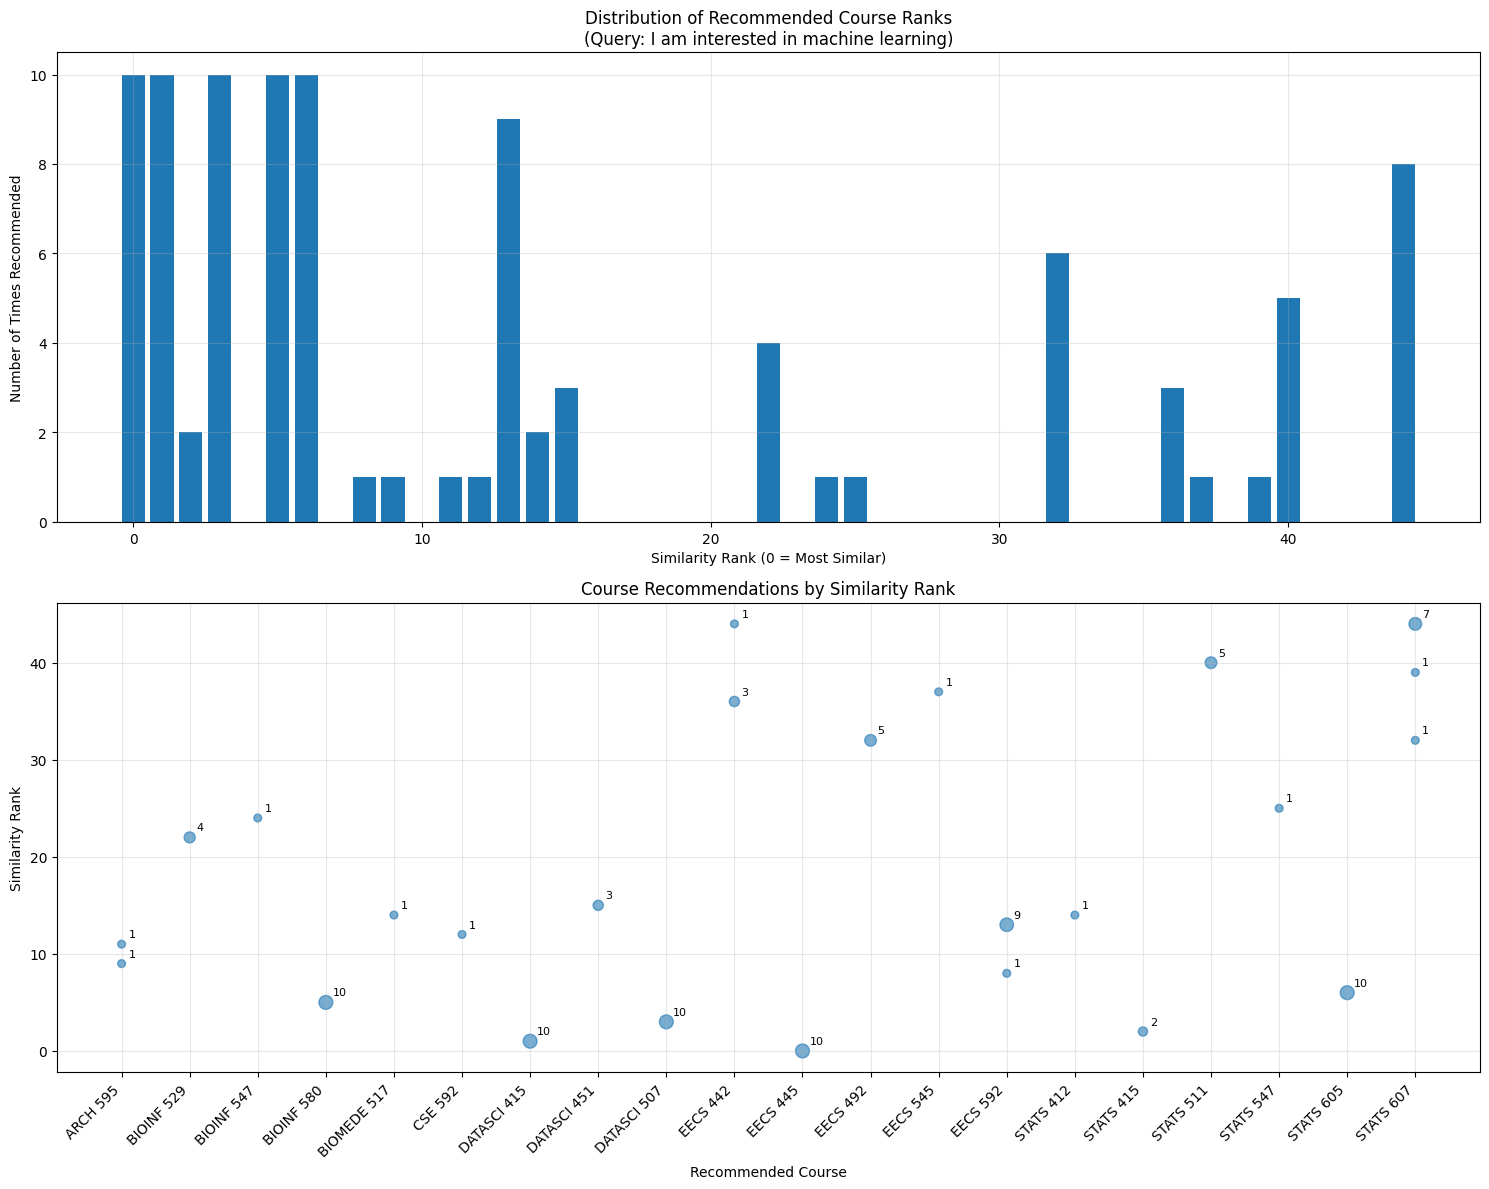


Summary Statistics:
Total recommendations: 100
Unique ranks recommended: 22
Most frequently recommended rank: 0
Average rank: 14.49


In [2]:
results = await run_analysis(
    recommender=recModel,
    query="I am interested in machine learning",
    n_trials=10
)

In [ ]:
results = await run_analysis(
    recommender=recModel,
    query="I am interested in machine learning",
    n_trials=10
)